In [1]:
%load_ext autoreload
%autoreload 2

import src.SHAP_like_graph_tool as gp
import src.SHAP_like_graph_tool.utils as gput

import networkx as nx
import html
import io
import json
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import os
import random
from re import X
import numpy as np
import pandas as pd
import networkx as nx
import itertools
from math import factorial
from networkx.algorithms.community import louvain_communities
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.metrics import normalized_mutual_info_score, adjusted_mutual_info_score, mutual_info_score
from sklearn.model_selection import KFold, train_test_split
from sklearn.feature_selection import mutual_info_regression
from node2vec import Node2Vec
from infomap import Infomap
import graph_tool.all as gt
import joblib
from pathlib import Path
from sklearn.model_selection import KFold, train_test_split
from xgboost import XGBClassifier
import optuna
from scipy import stats
from scipy.stats import entropy

/home/jovyan/envs/mon_env_ia/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1 - Performance Analysis of artificial graphs - With different subsets of features

In [190]:
def load_json(path):
    with open(path, 'r', encoding='utf-8') as f:
        data = json.load(f)
        G = nx.node_link_graph(data)
    
    print(f"Graphe chargé : {G.number_of_nodes()} nœuds et {G.number_of_edges()} liens.")
    return G

def load_graphml_safe(path, talk=False):
    with open(path, 'r', encoding='utf-8') as f:
        raw_data = f.read()

    clean_data = html.unescape(raw_data)
    G = nx.read_graphml(io.StringIO(clean_data))

    if talk:
        print(f"✅ Graphe chargé : {G.number_of_nodes()} nœuds et {G.number_of_edges()} liens.")
    return G

def add_ground_truth_groups(df, G):
    true_partition = dict(nx.get_node_attributes(G, 'block'))
    
    if not true_partition:
        print("Dictionnaire vide ! Vérifie si 'block' existe dans G.nodes(data=True)")
        return df

    df['group_u'] = df['u'].map(true_partition)
    df['group_v'] = df['v'].map(true_partition)
    
    df['group_u'] = df['group_u'].fillna(-1).astype(int)
    df['group_v'] = df['group_v'].fillna(-1).astype(int)
    df['same_group'] = (df['group_u'] == df['group_v']).astype(int)
    
    return df

def shuffle_ground_truth(df):
    """
    Crée des versions mélangées des colonnes de groupes.
    """
    df_shuffled = df.copy()
    # On récupère tous les IDs uniques présents et on les mélange
    unique_groups = df_shuffled['group_u'].unique()
    shuffled_map = dict(zip(unique_groups, np.random.permutation(unique_groups)))
    
    # On applique le mapping pour que la structure logique "same_group" disparaisse
    df_shuffled['group_u_shuffled'] = df_shuffled['group_u'].map(shuffled_map)
    df_shuffled['group_v_shuffled'] = df_shuffled['group_v'].map(shuffled_map)
    # On recalcule un same_group qui ne veut plus rien dire
    df_shuffled['same_group_shuffled'] = (df_shuffled['group_u_shuffled'] == df_shuffled['group_v_shuffled']).astype(int)
    
    return df_shuffled

def k_fold_cross_validation_exp(G_train, folds_data, features_list=None, n_trials=50, graph_name="G_NAME"):
    study = gput._run_optuna_tuning(folds_data, features_list, n_trials=n_trials)
    
    results = []
    for trial in study.trials:
        if trial.state == optuna.trial.TrialState.COMPLETE:
            results.append({
                'Trial': trial.number,
                'Avg_AUC': trial.value,
                'Std_AUC': trial.user_attrs.get('std_auc'),
                'Avg_AP': trial.user_attrs.get('avg_ap'),
                'Delta_AUC': trial.user_attrs.get('delta_auc'),
                'Params': trial.params
            })
    
    summary_df = pd.DataFrame(results).sort_values(by='Avg_AUC', ascending=False)

    print("\n" + "="*80)
    print(f"{'RÉSULTATS OPTUNA : BASELINE VS TOP CONFIGURATIONS':^80}")
    print("="*80)

    cols = ['Trial', 'Avg_AUC', 'Std_AUC', 'Avg_AP', 'Delta_AUC']
    print(summary_df[summary_df['Trial'] == 0][cols].to_string(index=False))
    print("-" * 80)
    print(summary_df.head(10)[cols].to_string(index=False))
    print("="*80)

    save_dir = "outputs/results"
    os.makedirs(save_dir, exist_ok=True)
    filename = f"optuna_results_{graph_name}.csv"
    full_path = os.path.join(save_dir, filename)
    summary_df.to_csv(full_path, index=False)
    print(f"Résultats sauvegardés dans : {full_path}")

    best_params = study.best_params.copy()
    best_params.update({'tree_method': 'hist', 'n_estimators': 150})
    
    return best_params, summary_df

### 1.1 Execution des expériences

In [24]:
features_GT_proba = ['GT_proba']
features_GT_sbm = ['GT_sbm_density', 'GT_degrees_sbm_u', 'GT_degrees_sbm_v']
features_GT_pos = ['GT_pos_dist', 'GT_spatial_deg_product', 
                   #'GT_spatial_gravity_log', 'GT_degrees_spatial_u','GT_degrees_spatial_v'
                  ]
features_structure = ['pr_u', 'pr_v','ppr_u', 'ppr_v', 'lcc_u', 'lcc_v', 'and_u', 'and_v', 'dc_u', 'dc_v', 'katz_u', 'katz_v',
                              'sp', 'jc', 'aa', 'cn','pa', 'ra']
features_commu_inferee = ['louvain_density', 'same_louvain', 'infomap_density', 'same_infomap', 'sbm_density', 'same_sbm',
                            'leiden_density', 'same_leiden', "surprise_density", "same_surprise", 
                            "significance_density", "same_significance"]
features_embeddings = ["deepwalk_cos", "deepwalk_rank", "deepwalk_had_mean",  "deepwalk_had_std", "deepwalk_dist",
                        "n2v_homophily_cos", "n2v_homophily_rank", "n2v_homophily_had_mean",  "n2v_homophily_had_std", "n2v_homophily_dist",
                      "crosswalk_cos", "crosswalk_rank", "crosswalk_had_mean",  "crosswalk_had_std", "crosswalk_dist"]
features_embeddings_reduced = ['deepwalk_cos', 'deepwalk_dist', 'deepwalk_rank']
features_commu_inferee_reduced = ["surprise_density", "sbm_density", "significance_density"]
features_commu_inferee_normal = ["leiden_density", "louvain_density"]
features_commu_inferee_spatial_based_manual = ["spatial_leiden_density", "spatial_louvain_density"]
features_commu_inferee_spatial_based_scgravity = ["spatial_leiden_scgravity_density", "spatial_louvain_scgravity_density"]
features_commu_inferee_spatial_based_wrdb = ["spatial_leiden_wrdb_density", "spatial_louvain_wrdb_density"]

features_structure_reduced = ['ra', 'pr_u', 'pr_v', 'lcc_u', 'lcc_v', 'katz_u', 'katz_v']


experiments = {
    #"GT_absolue (proba)": features_GT_proba,
    #"GT_sbm": features_GT_sbm,
    #"GT_pos": features_GT_pos,
    #"GT": features_GT_sbm + features_GT_pos,
    #"Inferred_Commu only": features_commu_inferee,
    #"Inferred_Commu spatial based": features_commu_inferee_spatial_based,
    #"Inferred_Commu_reduced": features_commu_inferee_reduced,
    "Inferred_Commu_normal": features_commu_inferee_normal,
    "Inferred_Commu_spatial_manuel": features_commu_inferee_spatial_based_manual,
    "Inferred_Commu_spatial_scgravity": features_commu_inferee_spatial_based_scgravity,
    "Inferred_Commu_spatial_wrdb": features_commu_inferee_spatial_based_wrdb,
    #"Structure_Only": features_structure,
    #"Structure_reduced" : features_structure_reduced,
    #"Embeddings_Only": features_embeddings,
    #"Embeddings_reduced": features_embeddings_reduced,
    "GT_pos": features_GT_pos,
    "GT_pos + Inferred_Commu normal": features_GT_pos + features_commu_inferee_normal,
    "GT_pos + Inferred_Commu spatial manuel": features_GT_pos + features_commu_inferee_spatial_based_manual,
    "GT_pos + Inferred_Commu spatial scgravity": features_GT_pos + features_commu_inferee_spatial_based_scgravity,
    "GT_pos + Inferred_Commu spatial wrdb": features_GT_pos + features_commu_inferee_spatial_based_wrdb,
    #"Structure + Inferred_Commu": features_structure + features_commu_inferee,
    #"Structure + Embeddings": features_structure + features_embeddings,
    #"Full_features_reduced" : features_structure_reduced + features_commu_inferee_reduced + features_embeddings_reduced,
    #"Full_features": features_structure + features_commu_inferee + features_embeddings,
    #"Full_features_spatial_inferees": features_structure + features_commu_inferee_spatial_based + features_embeddings  
}

all_results = []

#for i in [0.00,1.00]:
for i in np.arange(1.00, -0.10, -0.10):
    sbm_val = f"{i:.2f}"
    pos_val = f"{1-i:.2f}"
    G_name = f"artificial_graph_sbmv5_{sbm_val.replace('.', '_')}_pos_{pos_val.replace('.', '_')}"
    G_name_obj = f"artificial_graph_sbmv5_{sbm_val.replace('.', '_')}_pos_{pos_val.replace('.', '_')}"
    
    # 1. Chargement des données d'entraînement
    G_train, dataset_train, dataset_eval, _, _, _ = gp.load_all_data_for_graph(G_name)
    G = load_graphml_safe(f"graph_library/{G_name_obj}.graphml")

    if 'GroundTruth_JSON' in G.graph:
        print(f"[INIT] Extraction de la GT GroundTruth pour {G_name}...")
        gt_raw = json.loads(G.graph['GroundTruth_JSON'])
        
        GT = {'GT_sbm_matrix': np.array(gt_raw['GT_sbm_matrix']),
            'GT_pos': np.array(gt_raw['GT_pos']),
            'GT_sbm_id': np.array(gt_raw['GT_sbm_id']),
            'GT_degrees_sbm': np.array(gt_raw['GT_degrees_sbm']),
            'GT_degrees_spatial': np.array(gt_raw['GT_degrees_spatial'])
             }
        
        if 'P_matrix_JSON' in G.graph:
            print("P_matrix trouvée.")
            GT['GT_proba'] = np.array(json.loads(G.graph['P_matrix_JSON']))
    else:
        print("[WARNING] Aucune GroundTruth_JSON trouvée dans G.graph")
        GT = None

    pre_calculated_folds = gput._prepare_precalculated_folds(G_train, k=1, GroundTruth=GT)
    
    # 3. Lancement des tests
    for exp_name, feat_list in experiments.items():
        missing = set(feat_list) - set(dataset_train.columns)
        if missing:
            print(f" Exp {exp_name} : colonnes manquantes {missing}. Skip.")
            print(set(dataset_train.columns))
            continue

        print(f" Running: {exp_name} for SBM={i}")
        Params, summary_optim = k_fold_cross_validation_exp(G_train, pre_calculated_folds, feat_list, n_trials=10)
        
        stats_df, model, X_test, _, y_test, _ = gp.train_and_test_xgboost(dataset_train, features=feat_list,
                                                                          parameters = Params, plot=False)

        importances = model.feature_importances_
        feat_imp_series = pd.Series(importances, index=feat_list).sort_values(ascending=False)
        print(f"Top 5 Feature Importance pour {exp_name} :")
        print(feat_imp_series.head(5).to_string())

        probs = model.predict_proba(X_test)[:, 1]
        preds = model.predict(X_test)

        if exp_name == "GT_sbm":
            model_GT, X_test_GT_only, y_test_GT_only, probs_GT, preds_GT_only = model, X_test, y_test, probs, preds
        elif exp_name == "Inferred_Commu only":
            model_s, X_test_s, y_test_s, probs_s, preds_s = model, X_test, y_test, probs, preds
            
        # Évaluation sur le dataset de référence FIXE (Graphe SBM 1.0)
        # On force l'ordre des colonnes de eval_dataset pour correspondre au modèle
        X_eval_fixed = dataset_eval[feat_list] 
        stats_eval_df = gp.get_performance_metrics(model, X_eval_fixed, dataset_eval["target"], "EXP_")
        
        all_results.append({
            "Ratio_SBM": i,
            "Experiment": exp_name,
            "AP_train": stats_df["Test_AP"].iloc[0],
            "AUC-ROC_train": stats_df["Test_AUC-ROC"].iloc[0],
            "AP_eval": stats_eval_df["EXP_AP"].iloc[0],
            "AUC-ROC_eval": stats_eval_df["EXP_AUC-ROC"].iloc[0],
            "Top_Feature": feat_imp_series.index[0], # On stocke la #1 pour analyse
            "Top_Importance": feat_imp_series.iloc[0]
        })

# Recap final
df_compare = pd.DataFrame(all_results)

print("\n" + "="*50)
print("RÉCAPITULATIF DES EXPÉRIENCES (SBM vs Ground Truth)")
print("="*50)

# On affiche sans l'index pour plus de clarté si tu as déjà une colonne 'exp_name'
print(df_compare.to_string(index=False, float_format=lambda x: "{:,.4f}".format(x)))

print("="*50 + "\n")

output_dir = "outputs/results"
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, "comparaison_finale_structure_shuffled_v5_normal_VS_spatial_20260421.csv")
df_compare.to_csv(output_path, index=False)
print(f" Succès ! Fichier sauvegardé dans : {output_path}")

SHAP Analysis introuvable pour artificial_graph_sbmv5_1_00_pos_0_00.
✅ Graphe chargé : 198 nœuds et 2609 liens.
[INIT] Extraction de la GT GroundTruth pour artificial_graph_sbmv5_1_00_pos_0_00...
P_matrix trouvée.
[K-FOLD] Préparation séquentielle de 1 folds...
--- Démarrage Parallèle Fold 1 ---
Graphe original: 1596 liens
Graphe d'entraînement: 1356 liens
Liens cachés pour le test: 240

--- Enrichissement du Graphe avec les Métriques de Structure ---
Calcul : PageRank, Clustering, Average Neighbor Degree, Degree Centrality, Katz

--- Enrichissement du Graphe avec les Embeddings ---
Calcul des embeddings via n2v_homophily...
Calcul de Node2Vec (p=2, q=0.5)...
Génération des marches aléatoires (dim=64)...


Generating walks (CPU: 11): 100%|██████████| 9/9 [00:00<00:00, 21.43it/s]


Entraînement du modèle Skip-gram...
Skip-gram terminé en 3.04s
Calcul des embeddings via deepwalk...
Calcul de Node2Vec (p=1, q=1)...
Génération des marches aléatoires (dim=64)...


Generating walks (CPU: 10): 100%|██████████| 9/9 [00:00<00:00, 23.95it/s]


Entraînement du modèle Skip-gram...
Skip-gram terminé en 3.39s
Calcul des embeddings via crosswalk...
Calcul de Node2Vec (p=1, q=1)...
Génération des marches aléatoires (dim=64)...


...

Entraînement du modèle Skip-gram...
Skip-gram terminé en 3.26s
Calcul des embeddings via deepwalk...
Calcul de Node2Vec (p=1, q=1)...
Génération des marches aléatoires (dim=64)...


Generating walks (CPU: 11): 100%|██████████| 9/9 [00:00<00:00, 21.22it/s]


Entraînement du modèle Skip-gram...
Skip-gram terminé en 3.41s
Calcul des embeddings via crosswalk...
Calcul de Node2Vec (p=1, q=1)...
Génération des marches aléatoires (dim=64)...


Generating walks (CPU: 11): 100%|██████████| 9/9 [00:00<00:00, 17.84it/s]


Entraînement du modèle Skip-gram...
Skip-gram terminé en 3.15s

--- Enrichissement du Graphe avec les Communautés ---
Calcul des communautés via louvain...
Calcul des communautés via infomap...
Calcul des communautés via sbm...
Calcul des communautés via leiden...
Calcul des communautés via surprise...
Calcul des communautés via significance...
Calcul des communautés via spatial_leiden...
min_weight final: 2.33e-05 |  nb iter = 4
Null Model inféré normalisé par un facteur de 0.9449578802491254
--- ANALYSE DE L'ASYMÉTRIE ---
Somme de la valeur absolue des différences (|B_avant - B_après|) : 5.82e-14
Écart maximal ponctuel : 4.44e-16
Calcul des communautés via spatial_louvain...
Iteration 0: MAE = 5.231009, Beta = 1.9090
Modèle gravitaire inféré, avec une MAE de 0.009284464183011938, alpha moy = -0.3384 et beta = 7.677661335096883
Vérification : Null Model donne P.sum / 2*nb_edges = 0.9999999996577904
--- ANALYSE DE L'ASYMÉTRIE ---
Somme de la valeur absolue des différences (|B_avant - B

### 1.2 Plot des performances des expériences en fonction de SBM_ratio

--- Infos Dataset ---
Taille (Lignes, Colonnes) : (1320, 10)
Colonnes présentes : ['G_name', 'Ratio_SBM', 'Iter', 'Experiment', 'AP_train', 'AUC-ROC_train', 'AP_eval', 'AUC-ROC_eval', 'Top_Feature', 'Top_Importance']
--------------------
--- Aperçu après calcul des moyennes (par itération) ---
   Ratio_SBM                                   Experiment  AP_train_mean  \
0        0.0                                       GT_pos       0.411289   
1        0.0               GT_pos + Inferred_Commu normal       0.396743   
2        0.0  GT_pos + Inferred_Commu spatial manuel iter       0.385568   
3        0.0      GT_pos + Inferred_Commu spatial stdized       0.394523   
4        0.1                                       GT_pos       0.327241   
5        0.1               GT_pos + Inferred_Commu normal       0.314783   
6        0.1  GT_pos + Inferred_Commu spatial manuel iter       0.321220   
7        0.1      GT_pos + Inferred_Commu spatial stdized       0.315273   
8        0.2         

/tmp/ipykernel_723/3200287089.py:291: FutureWarning: The provided callable <function mean at 0x7f329937fa30> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df_avg = df_compare.groupby(["Ratio_SBM", "Experiment"])[metrics].agg([
/tmp/ipykernel_723/3200287089.py:291: FutureWarning: The provided callable <function mean at 0x7f329937fa30> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df_avg = df_compare.groupby(["Ratio_SBM", "Experiment"])[metrics].agg([


Graphique sauvegardé avec IC 99% ici : outputs/plots/comparaison_perfs_artificial_graph_sbmv_4_comusDebiased_30iter_20260626.csv_AUC-ROC_eval_CI99_SBM_ratio.png


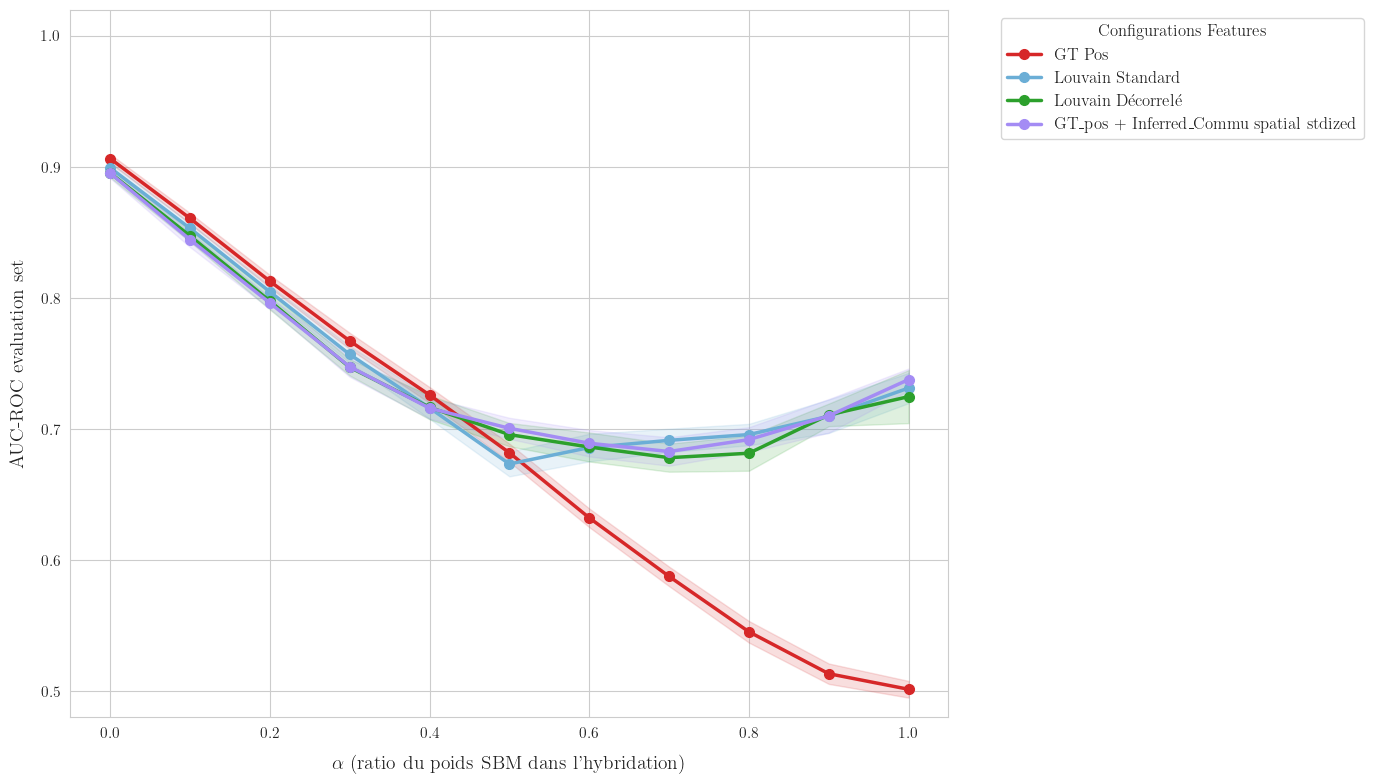

In [8]:
def plot_f1_comparison(df_results, metric="AUC-ROC_eval", name="OUBLI"):
    plt.figure(figsize=(14, 8)) # Un peu plus large pour la légende
    sns.set_style("whitegrid")
    
    # On récupère la liste des expériences uniques
    experiments = df_results['Experiment'].unique()
    # Palette de couleurs cohérente
    palette = sns.color_palette("husl", len(experiments))

    plt.rcParams.update({
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman"],
        'font.size': 12,
        'axes.labelsize': 14,
        'axes.titlesize': 14,
        'xtick.labelsize': 11,
        'ytick.labelsize': 11,
        'figure.titlesize': 16
    })
    
    for i, exp in enumerate(experiments):
        subset = df_results[df_results["Experiment"] == exp]
        
        # Extraction des noms de colonnes (basé sur ton agrégation précédente)
        mean_col = f"{metric}_mean"
        ci_col = f"{metric}_ci95" # ou ci95 selon le calcul
        
        color = palette[i]
        
        # 1. Tracer la ligne principale
        plt.plot(subset["Ratio_SBM"], subset[mean_col], 
                 marker='o', label=exp, color=color, linewidth=2.5, markersize=7)
        
        # 2. LA LIGNE MAGIQUE : L'intervalle de confiance ombré
        plt.fill_between(
            subset["Ratio_SBM"], 
            subset[mean_col] - subset[ci_col], 
            subset[mean_col] + subset[ci_col], 
            color=color, 
            alpha=0.15 # Transparence de la zone ombrée
        )
    
    # Personnalisation
    #plt.title(f"Évolution du {metric} (CI 95%) selon le ratio SBM", fontsize=15, pad=20)
    plt.xlabel(r"$\alpha$ (ratio du poids SBM dans l'hybridation)", labelpad=10)
    plt.ylabel(r"AUC-ROC evaluation set", labelpad=10)
    #plt.ylabel(f"{metric}", fontsize=12)
    
    plt.legend(title="Configurations Features", bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Ajustement dynamique des limites Y
    y_min = df_results[f"{metric}_mean"].min() - 0.05
    y_min = 0.45
    plt.ylim(max(0, y_min), 1.0) 
    
    plt.tight_layout()
    
    # Sauvegarde
    output_dir = os.path.join("outputs", "plots")
    os.makedirs(output_dir, exist_ok=True)
    save_path = os.path.join(output_dir, f"{name}_{metric}_CI99_SBM_ratio.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    print(f"Graphique sauvegardé avec IC 99% ici : {save_path}")
    plt.show()

def plot_f1_comparison_reels(df_results, metric="AUC-ROC_eval", name="OUBLI"):
    plt.figure(figsize=(14, 8))
    sns.set_style("whitegrid")
    
    # 1. Préparation de l'axe X catégoriel
    # On trie les graphes pour avoir un ordre consistant sur l'axe
    g_names = sorted(df_results['G_name'].unique())
    x_map = {name: i for i, name in enumerate(g_names)}
    
    experiments = df_results['Experiment'].unique()
    palette = sns.color_palette("husl", len(experiments))
    
    mean_col = f"{metric}_mean"
    ci_col = f"{metric}_ci95"
    
    for i, exp in enumerate(experiments):
        subset = df_results[df_results["Experiment"] == exp].copy()
        # On mappe les noms de graphes à des index numériques pour le tracé
        subset['x_idx'] = subset['G_name'].map(x_map)
        subset = subset.sort_values('x_idx')
        
        color = palette[i]
        
        # Tracer la ligne
        plt.plot(subset["x_idx"], subset[mean_col], 
                 marker='o', label=exp, color=color, linewidth=2.5, markersize=7)
        
        # L'intervalle de confiance ombré
        plt.fill_between(
            subset["x_idx"], 
            subset[mean_col] - subset[ci_col], 
            subset[mean_col] + subset[ci_col], 
            color=color, 
            alpha=0.15
        )
    
    # Personnalisation des axes
    plt.title(f"Performance {metric} (IC 95%) par Graphe Réel", fontsize=15, pad=20)
    
    # On remplace les index 0, 1, 2... par les vrais noms de graphes
    plt.xticks(range(len(g_names)), g_names, rotation=45, ha='right')
    
    plt.xlabel("Graphes Réels", fontsize=12)
    plt.ylabel(f"{metric}", fontsize=12)
    
    plt.legend(title="Configurations Features", bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Ajustement Y
    y_min = df_results[mean_col].min() - 0.05
    plt.ylim(max(0, y_min), 1.01) 
    
    plt.tight_layout()
    
    # Sauvegarde
    output_dir = os.path.join("outputs", "plots")
    os.makedirs(output_dir, exist_ok=True)
    save_path = os.path.join(output_dir, f"{name}_{metric}_G_reels.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    print(f"Graphique sauvegardé ici : {save_path}")
    plt.show()

def plot_f1_comparison_new(df_results, metric="AUC-ROC_eval", name="OUBLI"):
    plt.figure(figsize=(14, 8)) # Un peu plus large pour la légende
    sns.set_style("whitegrid")
    
    # --- 1. DICTIONNAIRE DE MAPPING DES NOMS ---
    labels_mapping = {
        "GT_pos + Inferred_Commu normal": "Louvain Standard",
        "GT_pos + Inferred_Commu spatial manuel iter": "Louvain Décorrelé",
        "GT_pos + deepwalk": "DeepWalk",
        "GT_pos + SiNEcustom_spatial": "SiNE Décorrelé",
        "GT_pos": "GT Pos",
        "GT_proba": "GT Proba",
        "Max théorique (GT_proba)": "Max théorique"
    }
    
    # --- 2. FIXATION DES COULEURS (ROUGE / VERT / BLEU) ---
    color_mapping = {
        # Les Ground Truth -> ROUGE
        "GT Pos": "#d62728",           # Rouge classique
        "GT Proba": "#ff4d4d",         # Rouge vif
        "Max théorique": "#8b0000",    # Rouge foncé
        
        # Les features décorrélées -> VERT
        "Louvain Décorrelé": "#2ca02c", # Vert standard
        "SiNE Décorrelé": "#2ca02c",    # Vert clair (pour les différencier)
        
        # Les features de base -> BLEU
        "Louvain Standard": "#6baed6",  # Bleu standard
        "DeepWalk": "#6baed6"           # Bleu clair
    }
    
    # On récupère la liste des expériences uniques
    experiments = df_results['Experiment'].unique()
    # Palette de secours "au cas où" un nom inconnu pop
    backup_palette = sns.color_palette("husl", len(experiments))

    plt.rcParams.update({
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman"],
        'font.size': 12,
        'axes.labelsize': 14,
        'axes.titlesize': 14,
        'xtick.labelsize': 11,
        'ytick.labelsize': 11,
        'figure.titlesize': 16
    })
    
    for i, exp in enumerate(experiments):
        subset = df_results[df_results["Experiment"] == exp]
        
        # Extraction des noms de colonnes
        mean_col = f"{metric}_mean"
        ci_col = f"{metric}_ci95" 
        
        # --- 3. INTERCEPTION DU NOM POUR L'AFFICHAGE ---
        clean_label = labels_mapping.get(exp, exp)
        
        # --- 4. SÉLECTION DE LA COULEUR MANUELLE ---
        color = color_mapping.get(clean_label, backup_palette[i])
        
        # 1. Tracer la ligne principale
        plt.plot(subset["Ratio_SBM"], subset[mean_col], 
                 marker='o', label=clean_label, color=color, linewidth=2.5, markersize=7)
        
        # 2. L'intervalle de confiance ombré
        plt.fill_between(
            subset["Ratio_SBM"], 
            subset[mean_col] - subset[ci_col], 
            subset[mean_col] + subset[ci_col], 
            color=color, 
            alpha=0.15 
        )
    
    # Personnalisation
    plt.xlabel(r"$\alpha$ (ratio du poids SBM dans l'hybridation)", labelpad=10)
    plt.ylabel(r"AUC-ROC evaluation set", labelpad=10)
    
    plt.legend(title="Configurations Features", bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Ajustement dynamique des limites Y
    y_min = 0.48
    plt.ylim(max(0, y_min), 1.02) 
    
    plt.tight_layout()
    
    # Sauvegarde
    output_dir = os.path.join("outputs", "plots")
    os.makedirs(output_dir, exist_ok=True)
    
    save_path = os.path.join(output_dir, f"{name}_{metric}_CI99_SBM_ratio.png")
    plt.savefig(save_path, bbox_inches='tight')
    
    print(f"Graphique sauvegardé avec IC 99% ici : {save_path}")
    plt.show()

def confidence_interval_99(data):
    n = len(data)
    if n < 2: return 0  # Impossible de calculer un IC sur une seule valeur
    sem = stats.sem(data) # Erreur standard : s / sqrt(n)
    # Calcul de l'intervalle avec la loi de Student
    h = sem * stats.t.ppf((1 + 0.99) / 2., n - 1)
    return h

def confidence_interval_95(data):
    n = len(data)
    if n < 2: return 0  # Impossible de calculer un IC sur une seule valeur
    sem = stats.sem(data) # Erreur standard : s / sqrt(n)
    # Calcul de l'intervalle avec la loi de Student pour 95%
    h = sem * stats.t.ppf((1 + 0.95) / 2., n - 1)
    return h


#df_compare = pd.read_csv("outputs/results/comparaison_perfs_commus_G_reels_0iter_2026_05_22.csv")
#df_compare = pd.read_csv("outputs/results/comparaison_perfs_commus_artificial_graph_sbmv_4_comuAndEmb_30iter_GT_pos.csv")
df_compare = pd.read_csv("outputs/results/comparaison_perfs_commus_artificial_graph_sbmv_4_comusDebiased_30iter_.csv")

feat_to_plot = [
                #"Inferred_Commu_normal","Inferred_Commu_spatial_manuel_iter", 
                #"Inferred_Commu_spatial_stdized", 
                #"Inferred_Commu_spatial_manuel_iter_bined",
                "GT_pos", 
                #"GT_proba",
                #"GT_sbm",
                "GT_pos + Inferred_Commu normal",
                "GT_pos + Inferred_Commu spatial manuel iter",
                "GT_pos + Inferred_Commu spatial stdized",
                #"GT_pos + Inferred_Commu spatial manuel iter bined",
        #"SiNEcustom",
        #"SiNEcustom_spatial",
        #"deepwalk",
        #"GT_pos + SiNEcustom",
        #"GT_pos + deepwalk",
        #"GT_pos + SiNEcustom_spatial",
        #"orthoModulo_posEig_emb",
        #"orthoModulo_posEig_nonDC_emb",
        #"orthoModulo_baseline_emb",
        #"deepwalk_baseline_emb",
        #"orthoModulo_posEig_comu",
        #"orthoModulo_posEig_nonDC_comu",
        #"louvain_baseline_comu",
        #"orthoModulo_posEig",
        #"orthoModulo_posEig_nonDC",
        #"orthoModulo_baseline",
        #"deepwalk_louvain_baseline",         
]

df_compare = df_compare[df_compare["Experiment"].isin(feat_to_plot)]
df_compare = df_compare.sort_values(by="Experiment", ascending=True)

print(f"--- Infos Dataset ---")
print(f"Taille (Lignes, Colonnes) : {df_compare.shape}")
print(f"Colonnes présentes : {df_compare.columns.tolist()}")
print("-" * 20)

# 3. Agrégation
# On groupe par Ratio_SBM et Experiment pour calculer moyenne et IC
metrics = ["AP_train", "AUC-ROC_train", "AP_eval", "AUC-ROC_eval"] 



df_avg = df_compare.groupby(["Ratio_SBM", "Experiment"])[metrics].agg([
    ('mean', np.mean),
    ('ci95', confidence_interval_95)
]).reset_index()


"""
df_avg = df_compare.groupby(["G_name", "Experiment"])[metrics].agg([
    ('mean', np.mean),
    ('ci95', confidence_interval_95)
]).reset_index()
"""

df_avg.columns = [f"{col[0]}_{col[1]}" if col[1] else col[0] for col in df_avg.columns.values]

# 4. Affichage du résultat agrégé
print("--- Aperçu après calcul des moyennes (par itération) ---")
print(df_avg.head(10))
#plot_f1_comparison_reels(df_avg, metric="AUC-ROC_eval", name = "G_reels_normal_VS_spatial_20260522" )
#plot_f1_comparison_new(df_avg, metric="AUC-ROC_eval", name = "01_artificial_graphs_shuffled_v4_comuAndEmb_30iter_GTposAndSine_20260529" )
plot_f1_comparison_new(df_avg, metric="AUC-ROC_eval", name = "comparaison_perfs_artificial_graph_sbmv_4_comusDebiased_30iter_20260626.csv")

### 1.3 Analyse détaillée des faux positifs, vrais pos, etc ...

In [ ]:
df_same_block = dataset[dataset['same_block_reel'] == 1]

# On compare le taux de liens réels (target) selon les voisins communs
results = df_same_block.groupby(df_same_block['cn'] > 0)['target'].mean()

print("Taux de liens réels (p) au sein d'un bloc :")
print(f"Sans voisins communs : {results[False]:.4f}")
print(f"Avec voisins communs : {results[True]:.4f}")

df_same_block_eval = eval_dataset[eval_dataset['same_block_reel'] == 1]
results_eval = df_same_block_eval.groupby(df_same_block_eval['cn'] > 0)['target'].mean()

print("--- ANALYSE DE LA PLUS-VALUE TOPOLOGIQUE (EVAL) ---")
print(f"Probabilité théorique injectée (p) : ~0.75")
print(f"Taux réel quand CN = 0 : {results_eval.get(False, 0):.4f}")
print(f"Taux réel quand CN > 0 : {results_eval.get(True, 0):.4f}")


sp_results = df_same_block.groupby('sp')['target'].agg(['mean', 'count'])

print("--- ANALYSE DE LA PLUS-VALUE DU SHORTEST PATH (EVAL) ---")
print(f"Probabilité théorique injectée (p) : ~0.75")
print(sp_results)

sp_zero = df_same_block[df_same_block_eval['sp'] == 0]['target'].mean()
sp_exists = df_same_block_eval[df_same_block_eval['sp'] > 0]['target'].mean()

print(f"\nTaux réel quand SP = 0 (aucun chemin) : {sp_zero:.4f}")
print(f"Taux réel quand SP > 0 (chemin existe) : {sp_exists:.4f}")

import pandas as pd
import numpy as np

def analyze_model_deep_dive(X_test, y_test, y_pred, name):
    """
    Analyse consolidée : Matrice de confusion, Communautés et Shortest Path (SP=1).
    """
    # 0. Alignement et préparation
    target = y_test.values if hasattr(y_test, 'values') else y_test
    df_res = pd.DataFrame({
        'target': target,
        'pred': y_pred,
        'same_block': X_test['same_block_reel'].values
    }, index=X_test.index)
    
    # Gestion du SP
    has_sp_col = 'sp' in X_test.columns
    if has_sp_col:
        df_res['sp1'] = (X_test['sp'] == 1).values
    
    total = len(df_res)
    
    # 1. Définition des masques de la matrice de confusion
    tp_m = (df_res['target'] == 1) & (df_res['pred'] == 1)
    fp_m = (df_res['target'] == 0) & (df_res['pred'] == 1)
    fn_m = (df_res['target'] == 1) & (df_res['pred'] == 0)
    tn_m = (df_res['target'] == 0) & (df_res['pred'] == 0)

    # 2. Fonctions utilitaires pour le détail Intra/Inter/SP1
    def get_details(mask):
        count = mask.sum()
        if count == 0: return "0", 0, 0, 0
        intra = (mask & (df_res['same_block'] == 1)).sum()
        inter = (mask & (df_res['same_block'] == 0)).sum()
        sp1 = (mask & df_res['sp1']).sum() if has_sp_col else 0
        return count, intra, inter, sp1

    tp, tp_intra, tp_inter, tp_sp1 = get_details(tp_m)
    fp, fp_intra, fp_inter, fp_sp1 = get_details(fp_m)
    fn, fn_intra, fn_inter, fn_sp1 = get_details(fn_m)
    tn, tn_intra, tn_inter, tn_sp1 = get_details(tn_m)

    # Affichage
    print(f"\n" + "="*60)
    print(f" DEEP DIVE PERFORMANCE : {name} ".center(60, "="))
    print(f"Nombre total de paires : {total}")
    print("-" * 60)

    # SECTION VRAIS POSITIFS
    print(f"VRAIS POSITIFS (TP) : {tp}")
    if tp > 0:
        print(f"  ├─ Intra-bloc : {tp_intra} | Inter-bloc : {tp_inter}")
        if has_sp_col:
            print(f"  └─ Dont déjà connus (SP=1) : {tp_sp1} ({tp_sp1/tp:.1%})")
            print(f"  └─ Trouvés par intelligence (SP!=1) : {tp - tp_sp1}")

    print("-" * 60)

    # SECTION FAUX POSITIFS
    print(f"FAUX POSITIFS (FP) : {fp}")
    if fp > 0:
        print(f"  ├─ Intra-bloc : {fp_intra} (Confusion même bloc)")
        print(f"  ├─ Inter-bloc : {fp_inter} (Erreur sur lien rare)")
        if has_sp_col:
            print(f"  └─ Dont avec SP=1 : {fp_sp1}")

    print("-" * 60)

    # SECTION FAUX NÉGATIFS
    print(f"FAUX NÉGATIFS (FN) : {fn}")
    if fn > 0:
        print(f"  ├─ Intra-bloc : {fn_intra} | Inter-bloc : {fn_inter}")
        if has_sp_col:
            print(f"  └─ Dont connus ratés (SP=1) : {fn_sp1}")

    print("-" * 60)

    # SECTION VRAIS NÉGATIFS
    print(f"VRAIS NÉGATIFS (TN) : {tn}")
    print(f"  └─ Intra-bloc : {tn_intra} | Inter-bloc : {tn_inter}")

    print("-" * 60)

    # SYNTHÈSE SUR L'INCONNU (Intelligence réelle)
    if has_sp_col:
        hidden_links_mask = (df_res['target'] == 1) & (~df_res['sp1'])
        n_hidden = hidden_links_mask.sum()
        if n_hidden > 0:
            tp_hidden = (tp_m & ~df_res['sp1']).sum()
            print(f"SCORE SUR LIENS MASQUÉS (SP!=1) : {tp_hidden}/{n_hidden} ({tp_hidden/n_hidden:.2%})")
            
    # DENSITÉS DE CONTRÔLE
    n_intra_total = (df_res['same_block'] == 1).sum()
    n_inter_total = (df_res['same_block'] == 0).sum()
    print(f"Densités observées : p={ (tp_intra+fn_intra)/n_intra_total:.4f} | q={ (tp_inter+fn_inter)/n_inter_total:.4f}")
    print("="*60)

# Utilisation :
# analyze_predictions_vs_sp1(X_test_s, y_test, preds)


X_test_GT_only = X_test_GT_only.copy()
X_test_GT_only['sp'] = dataset.loc[X_test_GT_only.index, 'sp']
analyze_model_deep_dive(X_test_GT_only, y_test_GT_only, preds_GT_only, "GT Only")

X_test_s = X_test_s.copy()
X_test_s['sp'] = dataset.loc[X_test_s.index, 'sp']
X_test_s['same_block_reel'] = dataset.loc[X_test_s.index, 'same_block_reel']
analyze_model_deep_dive(X_test_s, y_test_s, preds_s, "Structure Only")

### 1.4 plots des AP curves

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

def plot_ap_comparison(models_dict, X_eval_dict, y_true_dict):
    """
    Trace les courbes Precision-Recall en filtrant dynamiquement les colonnes
    pour éviter les erreurs de mismatch XGBoost.
    """
    plt.figure(figsize=(10, 7))
    
    for name, model in models_dict.items():
        trained_features = model.feature_names_in_
        X_filtered = X_eval_dict[name][trained_features]
        
        probs = model.predict_proba(X_filtered)[:, 1]
        
        precision, recall, _ = precision_recall_curve(y_true_dict[name], probs)
        ap = average_precision_score(y_true_dict[name], probs)
        
        plt.plot(recall, precision, label=f'{name} (AP = {ap:.4f})')
    
    plt.xlabel('Recall (Rappel)')
    plt.ylabel('Precision (Précision)')
    plt.title('Comparaison des courbes Precision-Recall')
    plt.legend()
    plt.grid(True)
    plt.show()

# Appel de la fonction
plot_ap_comparison(
     {'GroundTruth': model_GT, 'Structure': model_s},
     {'GroundTruth': X_test_GT_only, 'Structure': X_test_s},
     {'GroundTruth': y_test_GT_only, 'Structure': y_test_s}
)

### 1.5 Analyse de variance de probas prédites

In [ ]:
def compare_score_distributions(model_gt, X_gt, model_struct, X_struct):
    """
    Compare la variance et la finesse des scores de probabilité entre GT et Structure.
    """
    # 1. Récupération des probabilités (classe 1)
    trained_features_gt = model_gt.feature_names_in_
    trained_features_s = model_struct.feature_names_in_
    X_gt = X_gt[trained_features_gt]
    X_struct = X_struct[trained_features_s]

    probs_gt = model_gt.predict_proba(X_gt)[:, 1]
    probs_st = model_struct.predict_proba(X_struct)[:, 1]
    
    df_compare = pd.DataFrame({
        'prob_gt': probs_gt,
        'prob_st': probs_st,
        'intra': X_gt['same_block_reel'].values
    })

    results = []
    for label, is_intra in [("Intra-Bloc (Même communauté)", 1), ("Inter-Bloc (Communautés diff.)", 0)]:
        subset = df_compare[df_compare['intra'] == is_intra]
        
        results.append({
            "Type": label,
            "Modèle": "Ground Truth",
            "Variance": subset['prob_gt'].var(),
            "Valeurs Uniques": subset['prob_gt'].nunique(),
            "Moyenne": subset['prob_gt'].mean()
        })
        results.append({
            "Type": label,
            "Modèle": "Structure",
            "Variance": subset['prob_st'].var(),
            "Valeurs Uniques": subset['prob_st'].nunique(),
            "Moyenne": subset['prob_st'].mean()
        })

    # Affichage sous forme de tableau propre
    df_res = pd.DataFrame(results)
    print("\n=== ANALYSE DE LA FINESSE DES SCORES (GT vs STRUCTURE) ===")
    print(df_res.to_string(index=False))
    
    return df_compare

df_ana = compare_score_distributions(model_GT, X_test_GT_only, model_s, X_test_s)

### 1.5 Analyse des communautés inférées

#### 1.5.a Nb commus, denisté, conductance, etc.

In [26]:
def analyze_communities_fromgraph(G):
    nodes_dict = dict(G.nodes(data=True))
    df_comm = pd.DataFrame.from_dict(nodes_dict, orient='index')
    id_cols = [col for col in df_comm.columns if col.endswith('_id')]

    total_volume = sum(dict(G.degree()).values())
    stats = []
    
    print(f"--- Analyse des communautés ({len(G)} nœuds) ---")
    
    for col in id_cols:
        counts = df_comm[col].value_counts()
        n_comm = len(counts)
        mean_size = counts.mean()
        max_size = counts.max()
        min_size = counts.min()
        std_size = counts.std()
        
        # Calcul de l'entropie (pour voir si les tailles sont équilibrées)
        probs = counts / len(G)
        entropy = -np.sum(probs * np.log2(probs))

        # Calcul de la densité & conductance pour chaque communauté
        densities = []
        conductances = []
        comm_mean_degrees = []
        for comm_id in counts.index:
            
            # Calcul densité 
            nodes_in_comm = set(df_comm.index[df_comm[col] == comm_id])
            n = len(nodes_in_comm)
            
            subgraph = G.subgraph(nodes_in_comm)
            actual_edges = subgraph.number_of_edges()
            if n > 1:
                possible_edges = (n * (n - 1)) / 2
                densities.append(actual_edges / possible_edges)
            else:
                densities.append(0.0)

            # Calcul degrés moyens
            degs = [G.degree(node) for node in nodes_in_comm]
            comm_mean_degrees.append(np.mean(degs))
                
            # Calcul conductance
            vol_s = sum(G.degree(node) for node in nodes_in_comm)
            
            # Nombre d'arêtes sortantes (cut)
            cut_s = 0
            for node in nodes_in_comm:
                for neighbor in G.neighbors(node):
                    if neighbor not in nodes_in_comm:
                        cut_s += 1
            
            # Formule de la conductance
            if vol_s > 0 and vol_s < total_volume:
                # On prend le min entre le volume de S et le reste du graphe
                denom = min(vol_s, total_volume - vol_s)
                conductances.append(cut_s / denom)
            else:
                conductances.append(1.0)
                
        all_comm_degs_mean = np.mean(comm_mean_degrees)
        all_comm_degs_std = np.std(comm_mean_degrees)
        coef_variation_degrees = all_comm_degs_std / all_comm_degs_mean if all_comm_degs_mean > 0 else 0

        stats.append({
            'Méthode': col.replace('_id', ''),
            'Nb Commus': n_comm,
            'Taille Moy': round(mean_size, 2),
            'Taille Max': max_size,
            'Taille Min': min_size,
            'Taille Std' : std_size,
            'Entropie': round(entropy, 2),
            'Densité Moy': round(np.mean(densities), 4),
            'Densité Min': round(np.min(densities), 4),
            'Densité Max': round(np.max(densities), 4),
            'Densité Std': round(np.std(densities), 4),
            'Cond. Moy': round(np.mean(conductances), 4), # Plus c'est bas, mieux c'est
            'Cond. Std': round(np.std(conductances), 4),
            'Cond. Max': round(np.max(conductances), 4),
            "Coef Variation degrés" : round(coef_variation_degrees, 4), # Plus c'est bas, mieux c'est
        })
        
    stats_df = pd.DataFrame(stats).sort_values(by='Méthode', ascending=True)
        
    return stats_df, df_comm, id_cols

def plot_community_density_matrix(G, df_comm, community_col):
    """
    Affiche la heatmap des densités de liens inter/intra communautés.
    """
    # Récupération des IDs uniques et triés pour la matrice
    comm_ids = sorted(df_comm[community_col].unique())
    n_comm = len(comm_ids)
    matrix = np.zeros((n_comm, n_comm))
    
    # Mapping direct : Index du DataFrame (ID nœud) -> ID Communauté
    node_to_comm = df_comm[community_col].to_dict()
    
    # Comptage des liens existants
    for u, v in G.edges():
        if u in node_to_comm and v in node_to_comm:
            c1, c2 = node_to_comm[u], node_to_comm[v]
            idx1, idx2 = comm_ids.index(c1), comm_ids.index(c2)
            matrix[idx1, idx2] += 1
            if idx1 != idx2:
                matrix[idx2, idx1] += 1
                
    # Calcul des tailles de chaque communauté
    sizes = [len(df_comm[df_comm[community_col] == c]) for c in comm_ids]
    
    # Normalisation par le nombre de liens théoriques max
    for i in range(n_comm):
        for j in range(n_comm):
            n_i, n_j = sizes[i], sizes[j]
            if i == j: # Densité Intra
                possible = (n_i * (n_i - 1)) / 2 if n_i > 1 else 1
            else: # Densité Inter
                possible = n_i * n_j
            matrix[i, j] = matrix[i, j] / possible

    plt.figure(figsize=(10, 8))
    sns.heatmap(matrix, annot=True, fmt=".4f", cmap="YlGnBu", 
                xticklabels=comm_ids, yticklabels=comm_ids)
    plt.title(f"Matrice de densité inter/intra : {community_col}")
    plt.ylabel("ID Communauté")
    plt.xlabel("ID Communauté")
    plt.show()

def plot_feature_evolution_with_std(df, feature_name, output_path = None):
    """
    Affiche la moyenne (ligne), l'écart-type (pointillés) et les points individuels.
    """
    if feature_name not in df.columns:
        print(f"Erreur : {feature_name} introuvable.")
        return

    plt.figure(figsize=(12, 8))
    
    # On récupère les couleurs par défaut de Seaborn pour que tout concorde
    methods = df['Méthode'].unique()
    colors = sns.color_palette("husl", len(methods))
    
    for i, methode in enumerate(methods):
        subset = df[df['Méthode'] == methode]
        color = colors[i]
        
        # 1. Calcul des stats agrégées par ratio
        stats = subset.groupby('SBM_Ratio')[feature_name].agg(['mean', 'std']).reset_index()
        
        # 2. Plot de tous les points (avec jitter pour éviter les chevauchements parfaits)
        # alpha=0.3 pour ne pas surcharger visuellement
        #sns.scatterplot(data=subset, x='SBM_Ratio', y=feature_name, color=color, alpha=0.3, s=20, label=None)
        
        # 3. Ligne de la Moyenne
        plt.plot(stats['SBM_Ratio'], stats['mean'], color=color, 
                 linewidth=2.5, label=f"Moyenne {methode}")
        
        # 4. Lignes de l'Écart-type (Moyenne +/- STD)
        plt.plot(stats['SBM_Ratio'], stats['mean'] + stats['std'], color=color, 
                 linestyle='--', linewidth=1, alpha=0.7)
        plt.plot(stats['SBM_Ratio'], stats['mean'] - stats['std'], color=color, 
                 linestyle='--', linewidth=1, alpha=0.7)

    plt.title(f"Analyse statistique : {feature_name}", fontsize=14)
    plt.xlabel("Ratio SBM", fontsize=12)
    plt.ylabel(feature_name, fontsize=12)
    plt.grid(True, which='both', linestyle=':', alpha=0.5)
    
    # On gère la légende manuellement pour éviter les doublons
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()

    if output_path is not None : 
        plt.savefig(output_path, bbox_inches='tight', dpi=300)
        print(f"Graphique sauvegardé sous : {output_path}")

    plt.show()

In [136]:
all_results = []

for i_rep in range(1, 11):
    for j in np.arange(0.00, 1.10, 0.10):
        sbm_val = f"{j:.2f}"
        pos_val = f"{1-j:.2f}"
        #G_name = f"artificial_graph_sbmv4_{sbm_val.replace('.', '_')}_pos_{pos_val.replace('.', '_')}"
        G_name = f"artificial_graph_sbmv4_{sbm_val.replace('.', '_')}_pos_{pos_val.replace('.', '_')}_{i_rep}"
        
        # 1. Chargement des données d'entraînement
        #Graph, dataset_train, dataset_eval, _, _, _ = gp.load_all_data_for_graph(G_name)
        Graph = gp.loadsave_data_joblib(data=None, filename=f"G_kept_w_struct_com_dist_{G_name}", mode="load")
        
        df_stats, df_full, id_cols = analyze_communities_fromgraph(Graph)
        df_stats['Rep_ID'] = i_rep
        df_stats['SBM_Ratio'] = j
        #df_stats['Graph_Name'] = G_name
        
        all_results.append(df_stats)

--- Analyse des communautés (198 nœuds) ---
--- Analyse des communautés (198 nœuds) ---
--- Analyse des communautés (198 nœuds) ---
--- Analyse des communautés (198 nœuds) ---
--- Analyse des communautés (198 nœuds) ---
--- Analyse des communautés (198 nœuds) ---
--- Analyse des communautés (198 nœuds) ---
--- Analyse des communautés (198 nœuds) ---
--- Analyse des communautés (198 nœuds) ---
--- Analyse des communautés (198 nœuds) ---
--- Analyse des communautés (198 nœuds) ---
--- Analyse des communautés (198 nœuds) ---
--- Analyse des communautés (198 nœuds) ---
--- Analyse des communautés (198 nœuds) ---
--- Analyse des communautés (198 nœuds) ---
--- Analyse des communautés (198 nœuds) ---
--- Analyse des communautés (198 nœuds) ---
--- Analyse des communautés (198 nœuds) ---
--- Analyse des communautés (198 nœuds) ---
--- Analyse des communautés (198 nœuds) ---
--- Analyse des communautés (198 nœuds) ---
--- Analyse des communautés (198 nœuds) ---
--- Analyse des communautés (198

--- Agrégation terminée ---
   SBM_Ratio  Rep_ID  Méthode  Nb Commus  Taille Moy  Taille Max  Taille Min  \
0        0.0       1  louvain          5        39.6          67           4   

   Taille Std  Entropie  Densité Moy  Densité Min  Densité Max  Densité Std  \
0   30.204304       1.9       0.3956       0.2222       0.6667       0.1556   

   Cond. Moy  Cond. Std  Cond. Max  Coef Variation degrés  
0     0.2246      0.158     0.5349                 0.7231  
Graphique sauvegardé sous : outputs/plots/Cond._Std_graph_sbmv4_GT_pos_30iter_all_ratios.png


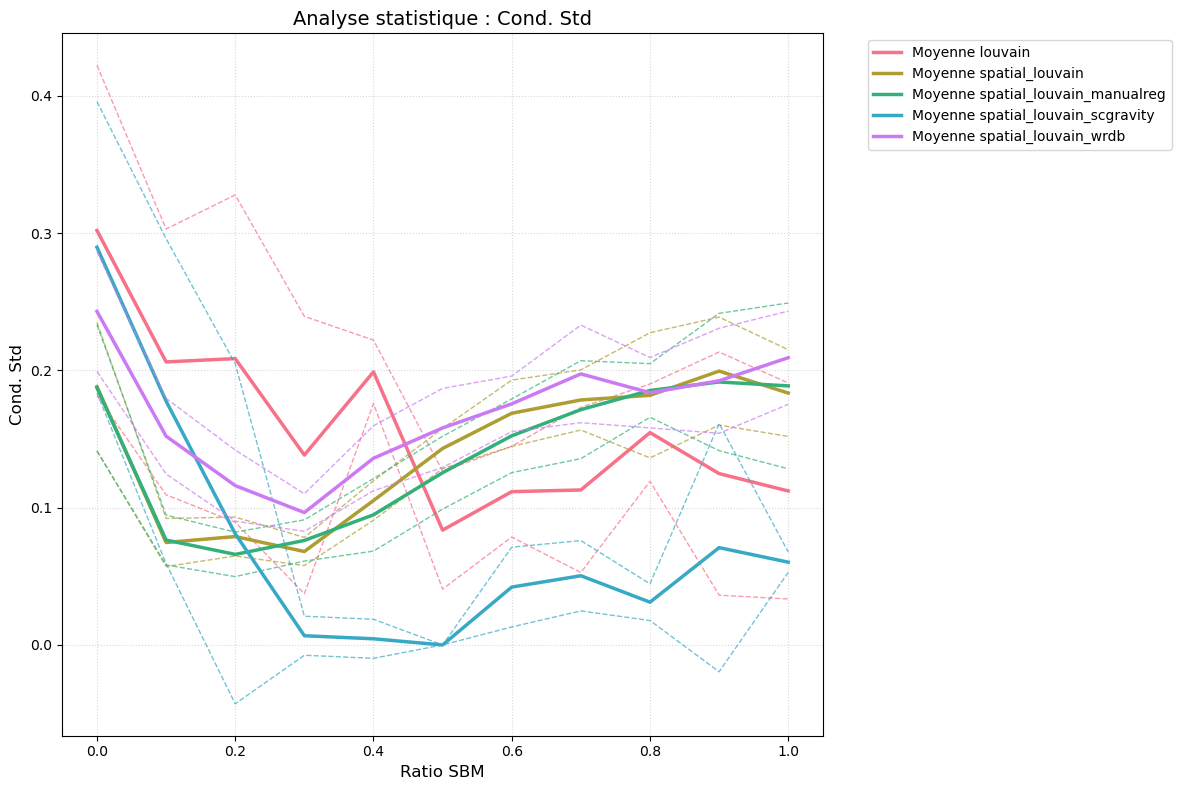

In [144]:
df_final_results = pd.concat(all_results, ignore_index=True)

# Réordonner les colonnes pour avoir les identifiants au début
cols = ['SBM_Ratio', 'Rep_ID', 'Méthode'] + [c for c in df_final_results.columns if c not in ['SBM_Ratio', 'Rep_ID', 'Méthode']]
df_final_results = df_final_results[cols].sort_values(['SBM_Ratio', 'Rep_ID', 'Méthode'])

#Filtre des commus qui nous intéressent : 
comus_to_track = ["louvain",
                "spatial_louvain",
                "spatial_louvain_manualreg",
                "spatial_louvain_wrdb",
                "spatial_louvain_scgravity"
                 ]
df_final_results = df_final_results[df_final_results["Méthode"].isin(comus_to_track)]

print("--- Agrégation terminée ---")
print(df_final_results.head(1))

# "Densité Moy", "Densité Std", "Nb Commus", "Taille Moy", "Taille Std", 'Cond. Moy', 'Cond. Std', "Coef Variation degrés"
metric =   'Cond. Std'
plot_name = f"{metric}_graph_sbmv4_GT_pos_30iter_all_ratios".replace(" ", "_")
output_path = f"outputs/plots/{plot_name}.png"

plot_feature_evolution_with_std(df_final_results, metric, output_path = output_path)

Airports
--- Analyse des communautés (3363 nœuds) ---
fullerene_structures_C1500
--- Analyse des communautés (1500 nœuds) ---
urban_streets_savannah
--- Analyse des communautés (584 nœuds) ---
urban_streets_seoul
--- Analyse des communautés (869 nœuds) ---
urban_streets_washington
--- Analyse des communautés (192 nœuds) ---
facebook_organizations_S1
--- Analyse des communautés (320 nœuds) ---
facebook_organizations_S2
--- Analyse des communautés (165 nœuds) ---
--- Agrégation terminée ---
  Graph_Name  Méthode  Nb Commus  Taille Moy  Taille Max  Taille Min  \
0   Airports  louvain        120       28.02         539           1   

   Taille Std  Entropie  Densité Moy  Densité Min  Densité Max  Densité Std  \
0   87.529439      4.07       0.1422          0.0          1.0        0.292   

   Cond. Moy  Cond. Std  Cond. Max  Coef Variation degrés  
0     0.6864     0.4309        1.0                 1.9291  
Graphique sauvegardé sous : outputs/plots/Densité_Moy_graph_reels_20260504.png


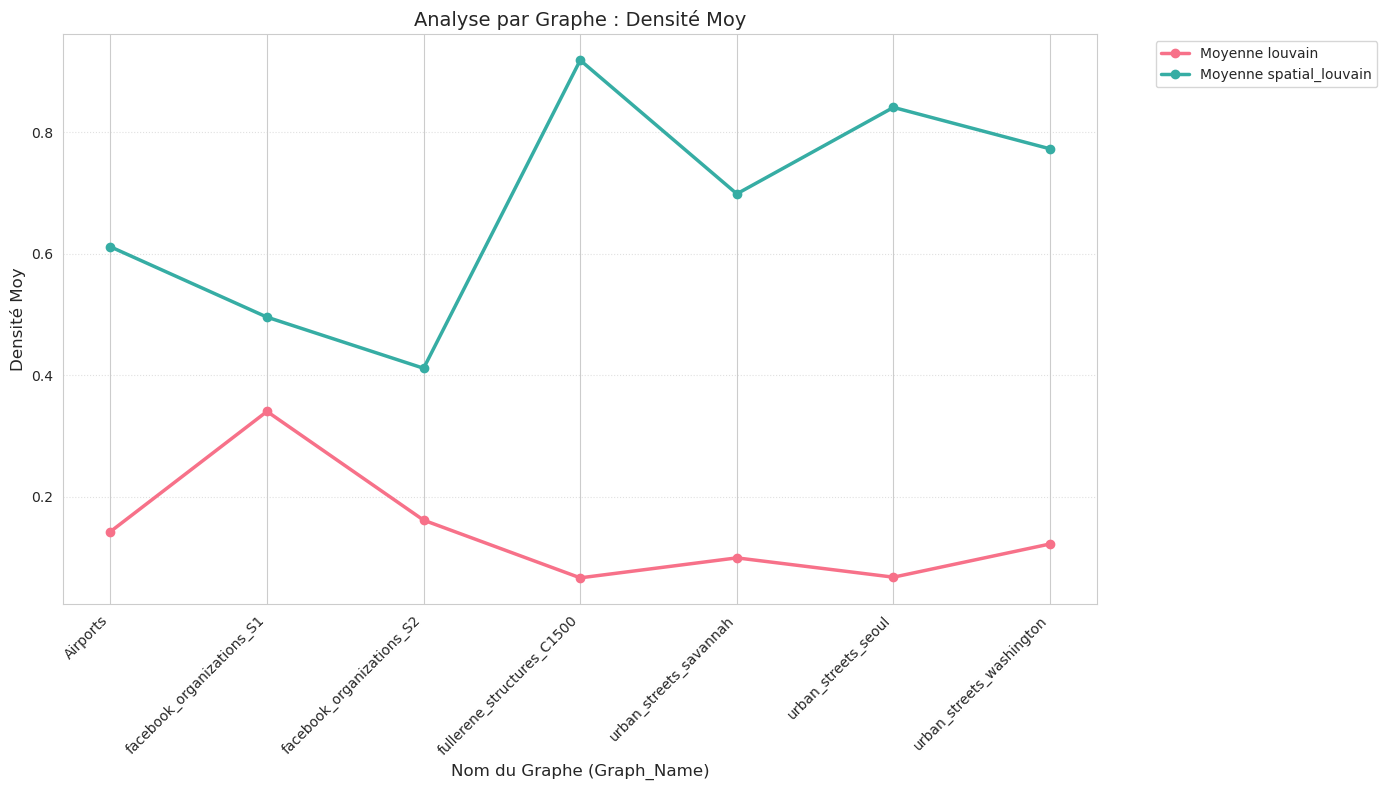

Graphique sauvegardé sous : outputs/plots/Densité_Std_graph_reels_20260504.png


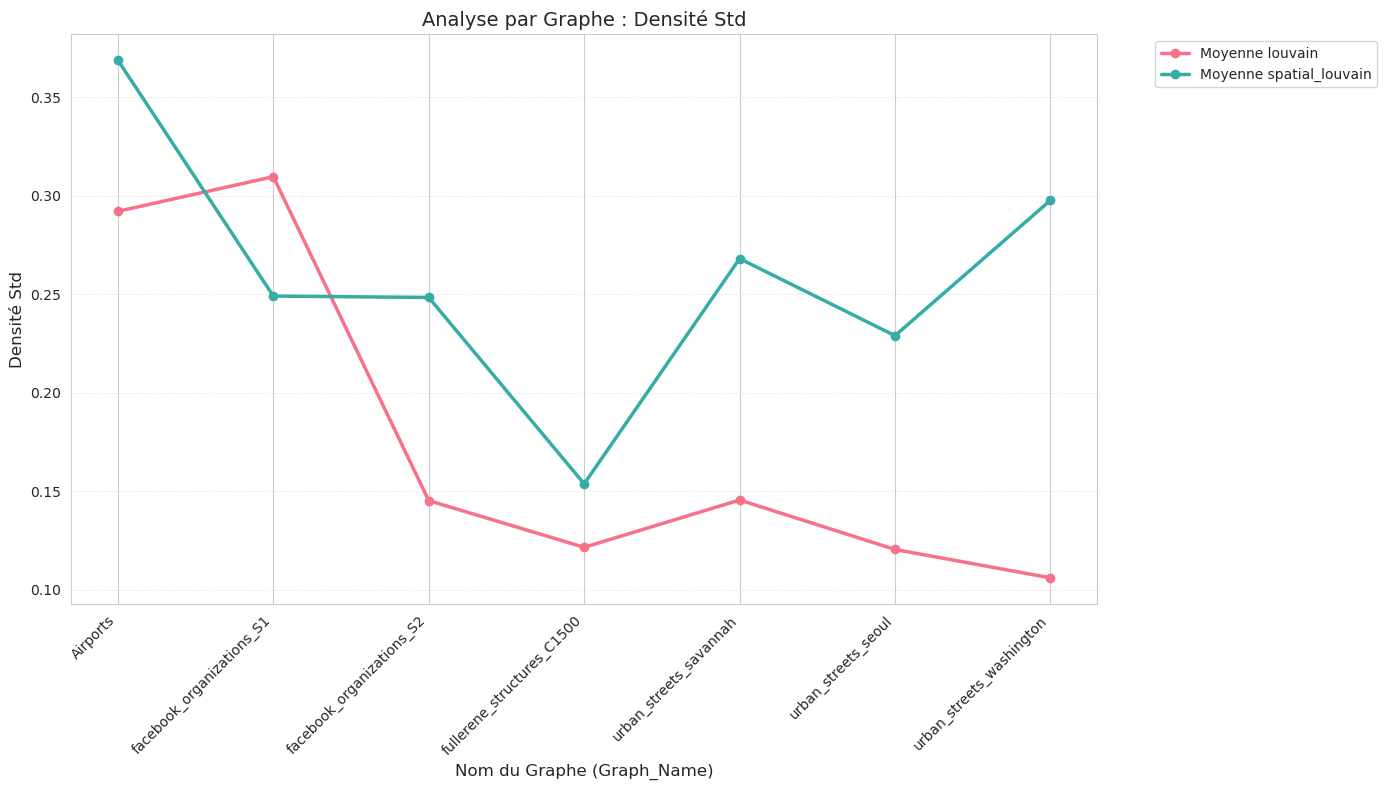

Graphique sauvegardé sous : outputs/plots/Nb_Commus_graph_reels_20260504.png


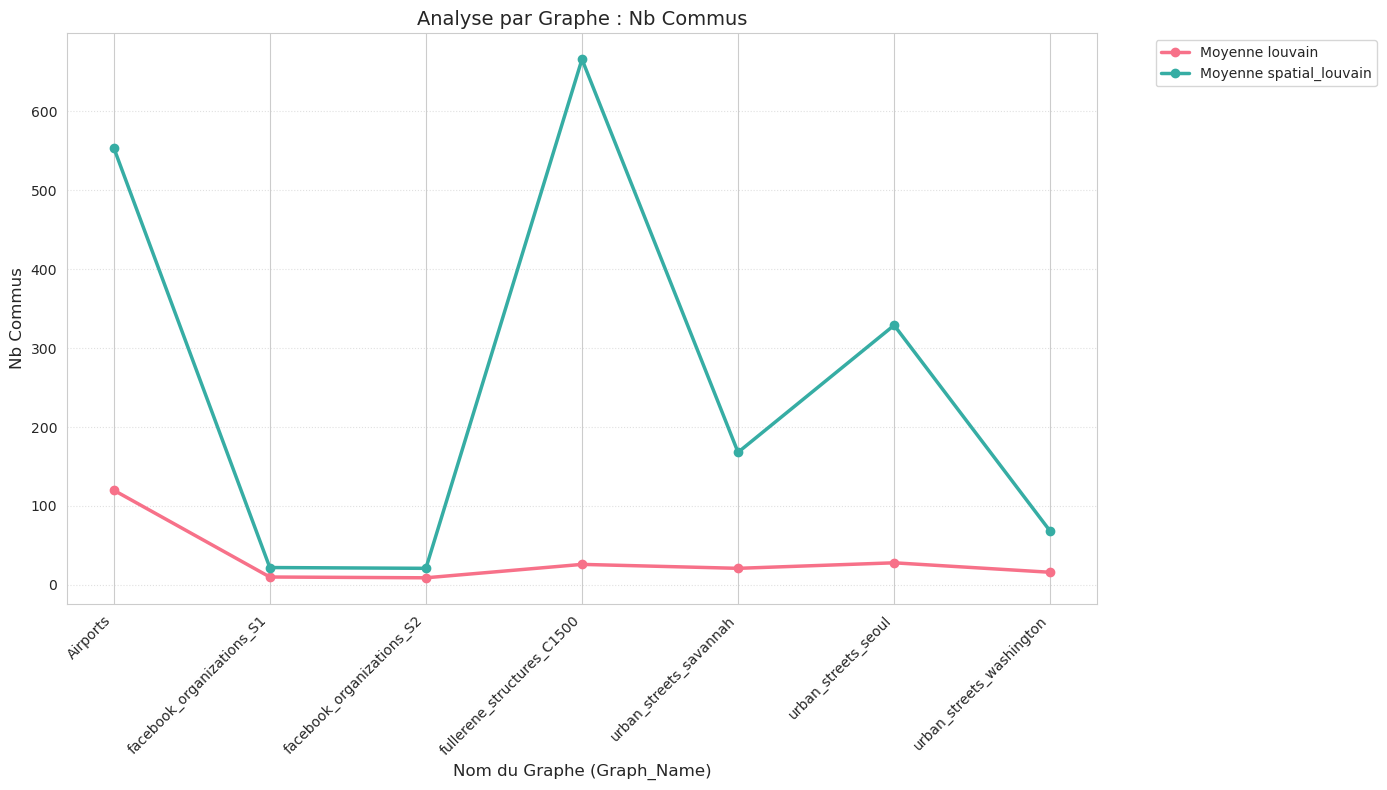

Graphique sauvegardé sous : outputs/plots/Taille_Moy_graph_reels_20260504.png


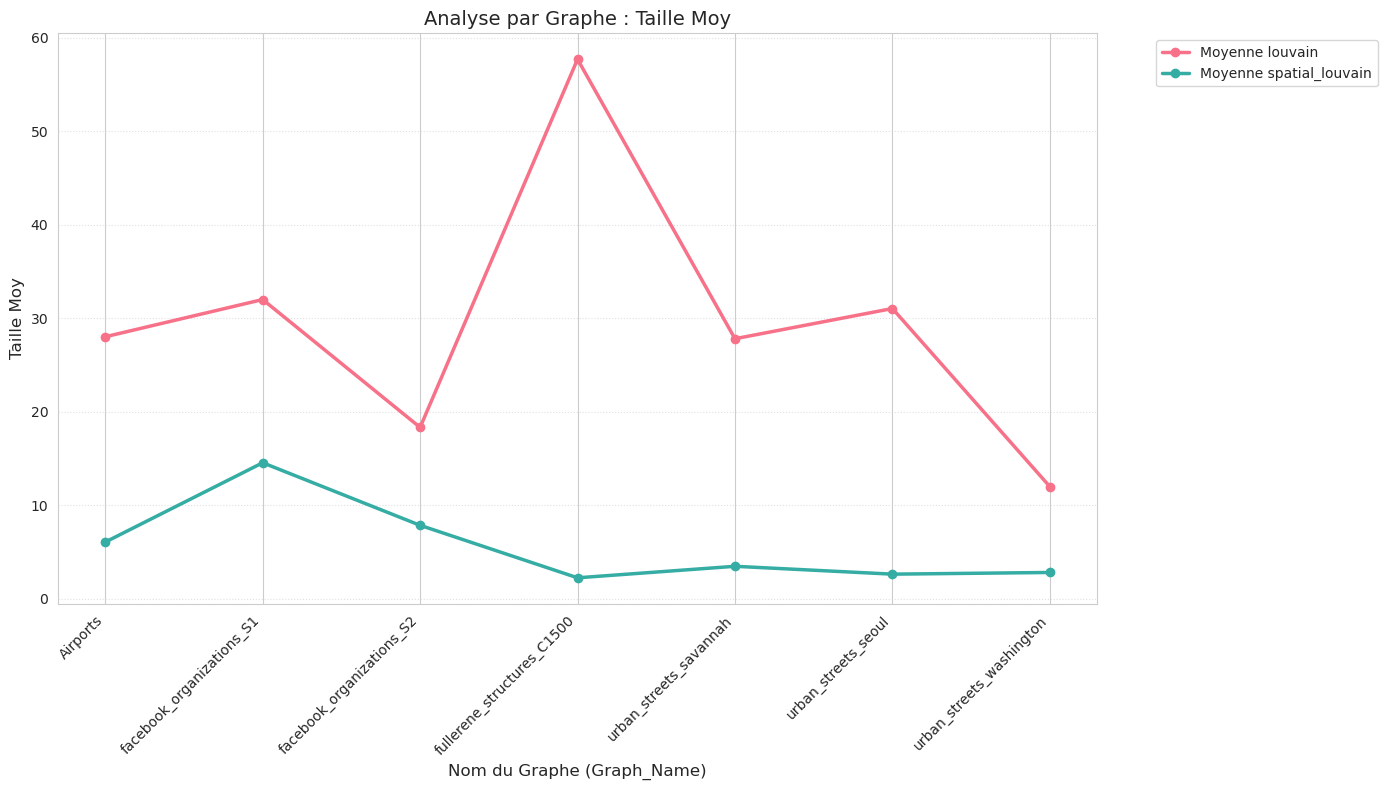

Graphique sauvegardé sous : outputs/plots/Taille_Std_graph_reels_20260504.png


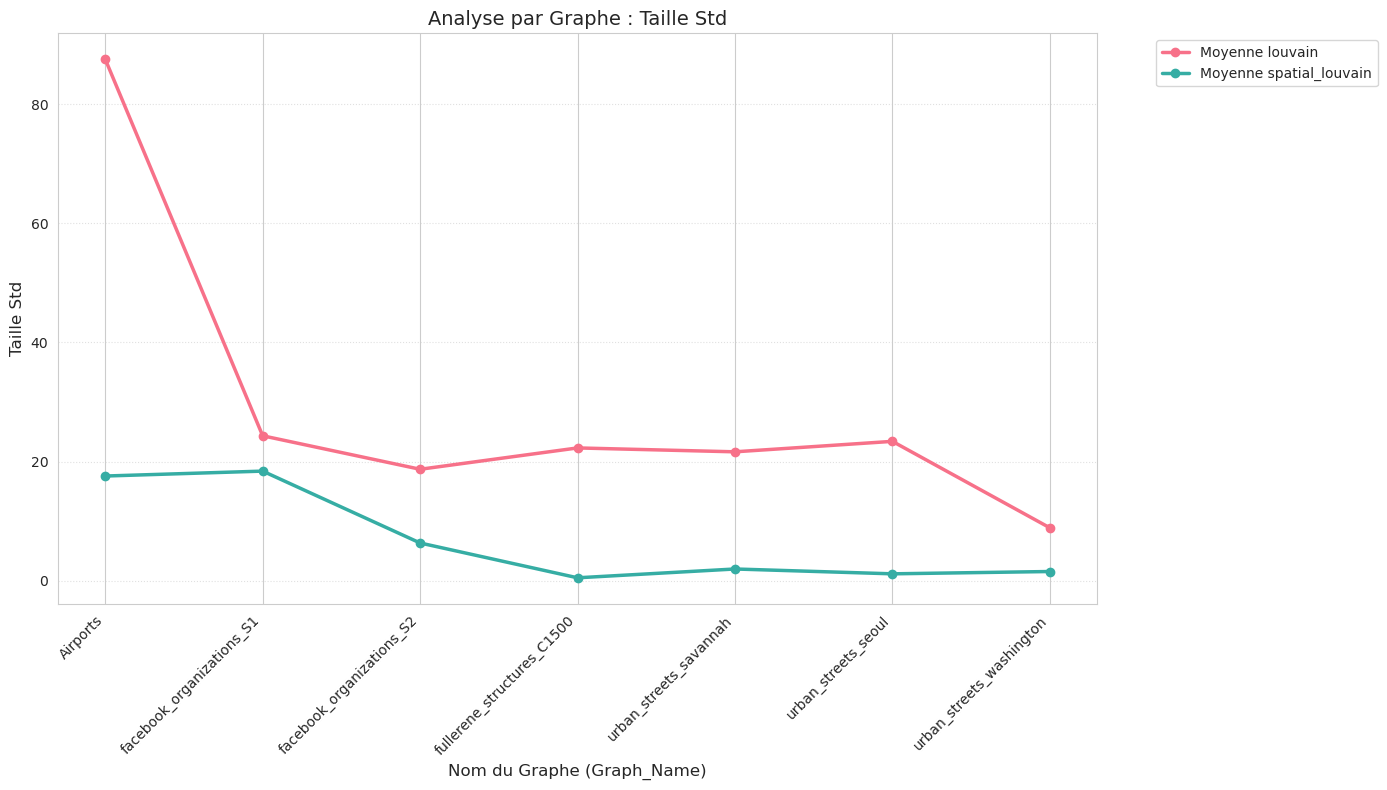

Graphique sauvegardé sous : outputs/plots/Cond._Moy_graph_reels_20260504.png


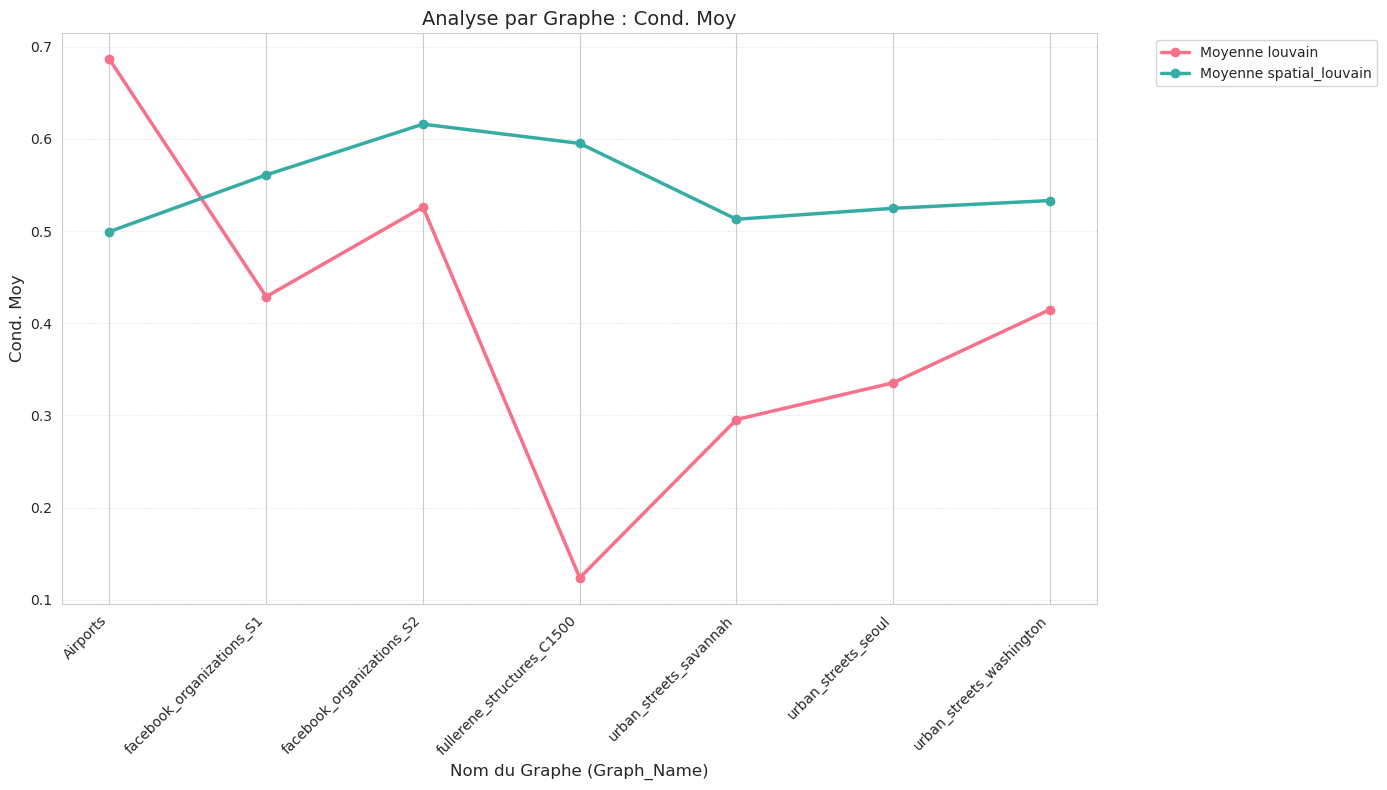

Graphique sauvegardé sous : outputs/plots/Cond._Std_graph_reels_20260504.png


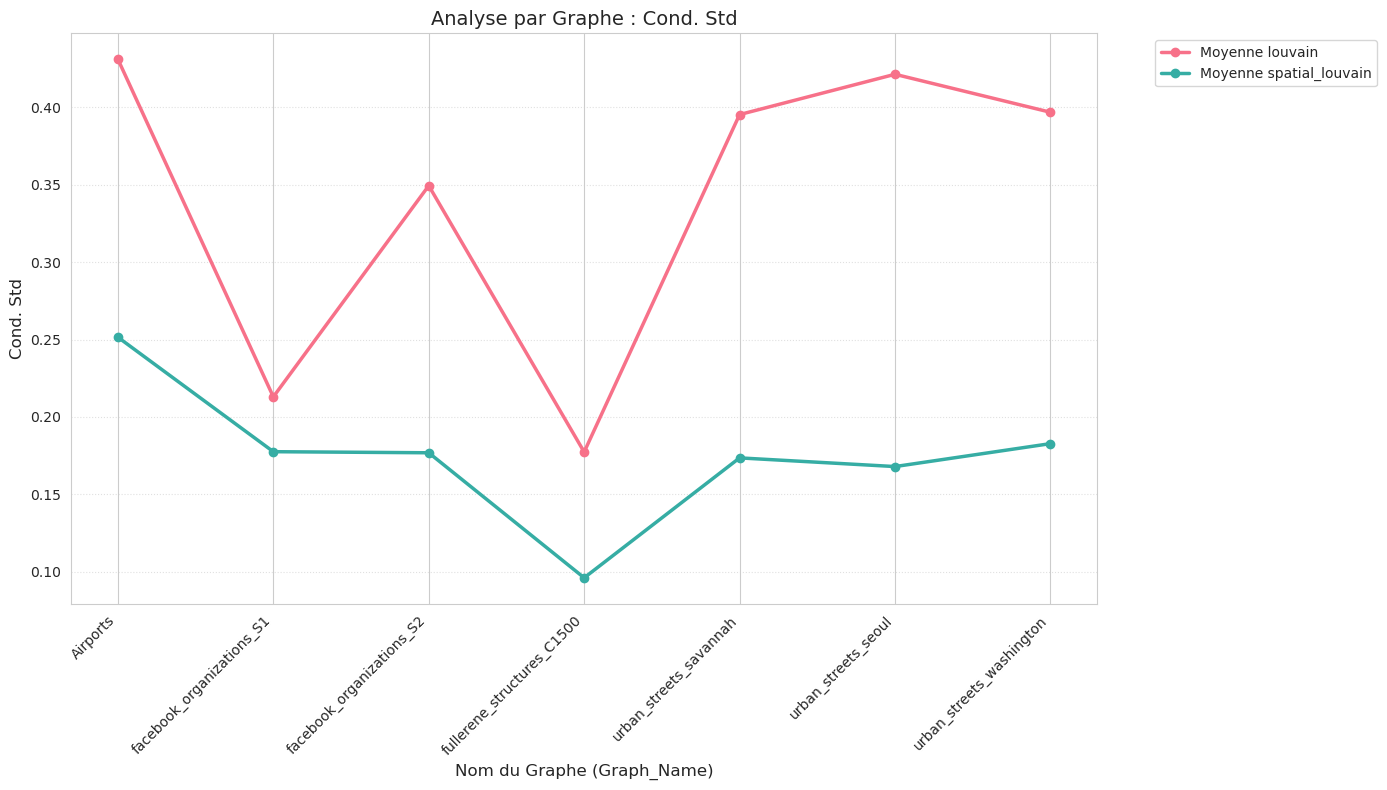

Graphique sauvegardé sous : outputs/plots/Coef_Variation_degrés_graph_reels_20260504.png


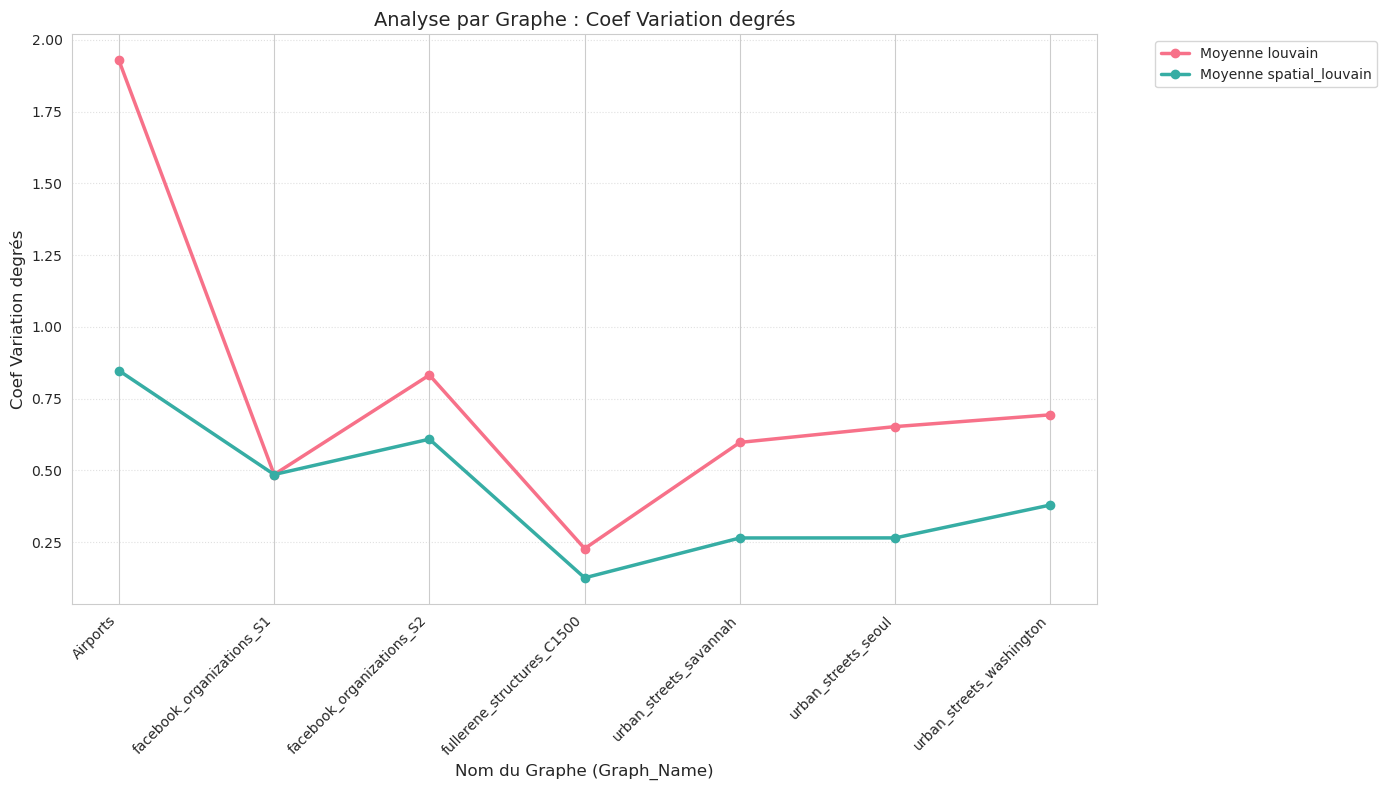

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_feature_evolution_by_graph(df, feature_name, output_path=None):
    """
    Affiche l'évolution d'une métrique selon les différents graphes (Graph_Name).
    Calcule la moyenne et l'écart-type sur les répétitions (Rep_ID).
    """
    if feature_name not in df.columns:
        print(f"Erreur : {feature_name} introuvable.")
        return

    plt.figure(figsize=(14, 8))
    
    # Tri alphabétique pour un axe X cohérent
    graph_order = sorted(df['Graph_Name'].unique())
    methods = df['Méthode'].unique()
    colors = sns.color_palette("husl", len(methods))
    
    for i, methode in enumerate(methods):
        subset = df[df['Méthode'] == methode]
        color = colors[i]
        
        # 1. Agrégation statistique par Graphe
        # On groupe par Graph_Name pour agréger les différentes répétitions (Rep_ID)
        stats = subset.groupby('Graph_Name')[feature_name].agg(['mean', 'std']).reset_index()
        
        # Assurer que l'ordre des graphes sur l'axe X est respecté pour le tracé des lignes
        stats['Graph_Name'] = pd.Categorical(stats['Graph_Name'], categories=graph_order, ordered=True)
        stats = stats.sort_values('Graph_Name')

        # 2. Plot de la ligne de Moyenne
        # On utilise un mapping numérique temporaire pour plt.plot sur des catégories
        x_coords = range(len(graph_order))
        
        plt.plot(x_coords, stats['mean'], color=color, marker='o', 
                 linewidth=2.5, label=f"Moyenne {methode}")
        
        # 3. Remplissage de l'incertitude (Écart-type)
        # Plus lisible que des pointillés pour des données catégorielles
        plt.fill_between(x_coords, 
                         stats['mean'] - stats['std'], 
                         stats['mean'] + stats['std'], 
                         color=color, alpha=0.15)
        
        # Optionnel : Lignes de l'écart-type en pointillés si vous préférez le style original
        plt.plot(x_coords, stats['mean'] + stats['std'], color=color, 
                 linestyle='--', linewidth=0.8, alpha=0.5)
        plt.plot(x_coords, stats['mean'] - stats['std'], color=color, 
                 linestyle='--', linewidth=0.8, alpha=0.5)

    # Configuration des axes
    plt.xticks(range(len(graph_order)), graph_order, rotation=45, ha='right')
    
    plt.title(f"Analyse par Graphe : {feature_name}", fontsize=14)
    plt.xlabel("Nom du Graphe (Graph_Name)", fontsize=12)
    plt.ylabel(feature_name, fontsize=12)
    plt.grid(True, axis='y', linestyle=':', alpha=0.6)
    
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()

    if output_path is not None: 
        plt.savefig(output_path, bbox_inches='tight', dpi=300)
        print(f"Graphique sauvegardé sous : {output_path}")

    plt.show()

G_names_list = [
        "Airports",
        "fullerene_structures_C1500",
        "urban_streets_savannah",
        "urban_streets_seoul",
        "urban_streets_washington",
        "facebook_organizations_S1",
        "facebook_organizations_S2",
    ]

all_results = []
for name in G_names_list:
    print(name)
    Graph = gp.loadsave_data_joblib(data=None, filename=f"G_kept_w_struct_com_dist_{name}", mode="load")
    
    df_stats, df_full, id_cols = analyze_communities_fromgraph(Graph)
    df_stats['Graph_Name'] = name
    
    all_results.append(df_stats)

df_final_results = pd.concat(all_results, ignore_index=True)

# Réordonner les colonnes pour avoir les identifiants au début
cols = ['Graph_Name', 'Méthode'] + [c for c in df_final_results.columns if c not in ['Graph_Name', 'Méthode']]
df_final_results = df_final_results[cols].sort_values(['Graph_Name', 'Méthode'])

#Filtre des commus qui nous intéressent : 
comus_to_track = ["louvain",
                "spatial_louvain"
                 ]
df_final_results = df_final_results[df_final_results["Méthode"].isin(comus_to_track)]

print("--- Agrégation terminée ---")
print(df_final_results.head(1))

for metric in ["Densité Moy", "Densité Std", "Nb Commus", "Taille Moy", "Taille Std", 
               'Cond. Moy', 'Cond. Std', "Coef Variation degrés"]:
    plot_name = f"{metric}_graph_reels_20260504".replace(" ", "_")
    output_path = f"outputs/plots/{plot_name}.png"
    
    plot_feature_evolution_by_graph(df_final_results, metric, output_path = output_path)

#### 1.5.b Diamètre des communautés

In [ ]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import pdist, squareform

def calculate_spatial_diameter(G, pos_attr, id_cols, df_comm):
    """
    Calcule le diamètre spatial (distance Euclidienne max) pour chaque communauté.
    
    Args:
        G: Le graphe NetworkX
        pos_attr: Nom de l'attribut contenant les positions (ex: 'GT_pos')
        id_cols: Liste des colonnes de communautés (ex: ['louvain_id', 'spatial_louvain_id'])
        df_comm: DataFrame contenant les assignations (index=node_id)
        
    Returns:
        Un dictionnaire de dictionnaires contenant les stats de diamètre par méthode.
    """
    # Extraction des positions dans un dictionnaire pour accès rapide
    pos_dict = {n: np.array(data[pos_attr]) for n, data in G.nodes(data=True)}
    
    diameter_stats = []

    for col in id_cols:
        diameters = []
        # On itère sur chaque communauté unique de la méthode
        for comm_id in df_comm[col].unique():
            nodes_in_comm = df_comm.index[df_comm[col] == comm_id].tolist()
            
            if len(nodes_in_comm) < 2:
                diameters.append(0.0)
                continue
            
            # Extraction des coordonnées pour les nœuds de la communauté
            coords = np.array([pos_dict[n] for n in nodes_in_comm])
            
            # Calcul de toutes les distances par paires (Euclidienne par défaut)
            # pdist est très performant pour cela
            dists = pdist(coords)
            
            # Le diamètre est la distance maximale trouvée
            diameters.append(np.max(dists))
            
        diameter_stats.append({
            'Méthode': col.replace('_id', ''),
            'Diamètre Spatial Moy': round(np.mean(diameters), 4),
            'Diamètre Spatial Max': round(np.max(diameters), 4),
            'Diamètre Spatial Std': round(np.std(diameters), 4)
        })
        
    return pd.DataFrame(diameter_stats)

### 1.6 Exploration visuelle des positions et catégories

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
import os

def plot_node_spatial_with_edges(G, title="Focus Liaisons Internes", selected_blocks=None):
    """
    Affiche les nœuds et les arêtes internes des blocs sélectionnés.
    """
    pos = nx.get_node_attributes(G, 'pos')
    blocks = nx.get_node_attributes(G, 'block')
    
    if not pos or not blocks:
        print("❌ Erreur : 'pos' ou 'block' manquants.")
        return

    plt.figure(figsize=(10, 10))
    
    # 1. Fond : tous les nœuds en gris
    all_nodes = list(G.nodes())
    nx.draw_networkx_nodes(G, pos, nodelist=all_nodes, node_color='lightgray', 
                           node_size=10, alpha=0.2)

    # 2. Sélection des nœuds et arêtes à mettre en avant
    if selected_blocks:
        target_nodes = [n for n, b in blocks.items() if b in selected_blocks]
        # On ne garde que les arêtes dont les DEUX extrémités sont dans les blocs sélectionnés
        target_edges = [(u, v) for u, v in G.edges() if u in target_nodes and v in target_nodes]
        
        # 3. Dessin des arêtes internes (le signal SBM)
        nx.draw_networkx_edges(G, pos, edgelist=target_edges, edge_color='blue', 
                               width=0.5, alpha=0.4)
        
        # 4. Dessin des nœuds sélectionnés (colorés par bloc)
        node_colors = [blocks[n] for n in target_nodes]
        scatter = nx.draw_networkx_nodes(G, pos, nodelist=target_nodes, 
                                         node_color=node_colors, cmap='tab10', 
                                         node_size=40, edgecolors='black', linewidths=0.5)
        
        if len(selected_blocks) > 1:
            plt.colorbar(scatter, label="ID du Bloc")
    
    plt.title(title)
    plt.axis('off') # On enlève les axes pour mieux voir la structure
    
    # Sauvegarde
    plot_dir = os.path.join(PROJECT_ROOT, "outputs", "plots")
    os.makedirs(plot_dir, exist_ok=True)
    plt.savefig(os.path.join(plot_dir, f"{title.replace(' ', '_')}.png"), dpi=300)
    
    plt.show()

# --- TEST ---
# Essaye avec 2 blocs qui ont des scores F1 élevés
# plot_node_spatial_with_edges(G, selected_blocks=[1, 2], title="Structure Interne Blocs 1 et 2")

In [ ]:
G_name = f"artificial_graph_sbm_1_00_pos_0_00"
dataset, _, _, _ = gp.load_all_data_for_graph(G_name)
G = load_json(f"graph_library/{G_name}.json")
plot_node_spatial_with_edges(G, title="Correlation Spatiale à i=1 (Géo Pur)", selected_blocks=[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20])

### 1.7 Analyse de corrélation entre features et GT

In [46]:
features_GT = ['GT_sbm_density', 'GT_degrees_sbm_u', 'GT_degrees_sbm_v',
               'GT_pos_dist', 'GT_degrees_spatial_u','GT_degrees_spatial_v', 'GT_spatial_deg_product']
features_structure = ['pr_u', 'pr_v','ppr_u', 'ppr_v', 'lcc_u', 'lcc_v', 'and_u', 'and_v', 'dc_u', 'dc_v', 'katz_u', 'katz_v',
                              'sp', 'jc', 'aa', 'cn','pa', 'ra']
features_commu_inferee = ['louvain_density', 
                          #'infomap_density', 'sbm_density','leiden_density',"surprise_density", "significance_density",
                          #'spatial_leiden_density',  
                          'spatial_louvain_density', "spatial_louvain_scgravity_density", 
                          'spatial_louvain_wrdb_density']
features_embeddings = ["deepwalk_cos", "deepwalk_rank", "deepwalk_had_mean",  "deepwalk_had_std",
                        "n2v_homophily_cos", "n2v_homophily_rank", "n2v_homophily_had_mean",  "n2v_homophily_had_std",
                      "crosswalk_cos", "crosswalk_rank", "crosswalk_had_mean",  "crosswalk_had_std"]
all_matrices = {}
results_corr = []

for i in np.arange(0.00, 1.10, 0.10):
    sbm_val = f"{i:.2f}"
    pos_val = f"{1-i:.2f}"
    G_name = f"artificial_graph_sbmv4_{sbm_val.replace('.', '_')}_pos_{pos_val.replace('.', '_')}"
    
    # 1. Chargement des données d'entraînement
    G_train, dataset_train, dataset_eval, _, _, _ = gp.load_all_data_for_graph(G_name)

    #features_to_test = [c for c in dataset_eval.columns if c not in features_GT and c not in ['u', 'v', 'target', 'label']]
    features_to_test = features_commu_inferee
    
    current_corr = dataset_eval[features_to_test + features_GT].corr(method='spearman')
    sub_matrix = current_corr.loc[features_to_test, features_GT]
    all_matrices[i] = sub_matrix

    #print(f"\n--- Matrice de Corrélation GT pour Alpha = {i} ---")
    print(sub_matrix.round(3))

    for f in features_to_test:
        for gt in features_GT:
            results_corr.append({
                'alpha': i,
                'feature': f,
                'gt_feature': gt,
                'correlation': current_corr.loc[f, gt]
            })

df_evolution = pd.DataFrame(results_corr)

SHAP Analysis introuvable pour artificial_graph_sbmv4_0_00_pos_1_00.
                                   GT_sbm_density  GT_degrees_sbm_u  \
louvain_density                             0.039             0.027   
spatial_louvain_density                     0.042             0.023   
spatial_louvain_scgravity_density           0.052             0.081   
spatial_louvain_wrdb_density                0.004             0.064   

                                   GT_degrees_sbm_v  GT_pos_dist  \
louvain_density                               0.017       -0.679   
spatial_louvain_density                       0.026       -0.316   
spatial_louvain_scgravity_density             0.064       -0.748   
spatial_louvain_wrdb_density                  0.064       -0.220   

                                   GT_degrees_spatial_u  GT_degrees_spatial_v  \
louvain_density                                   0.014                -0.007   
spatial_louvain_density                           0.003                -

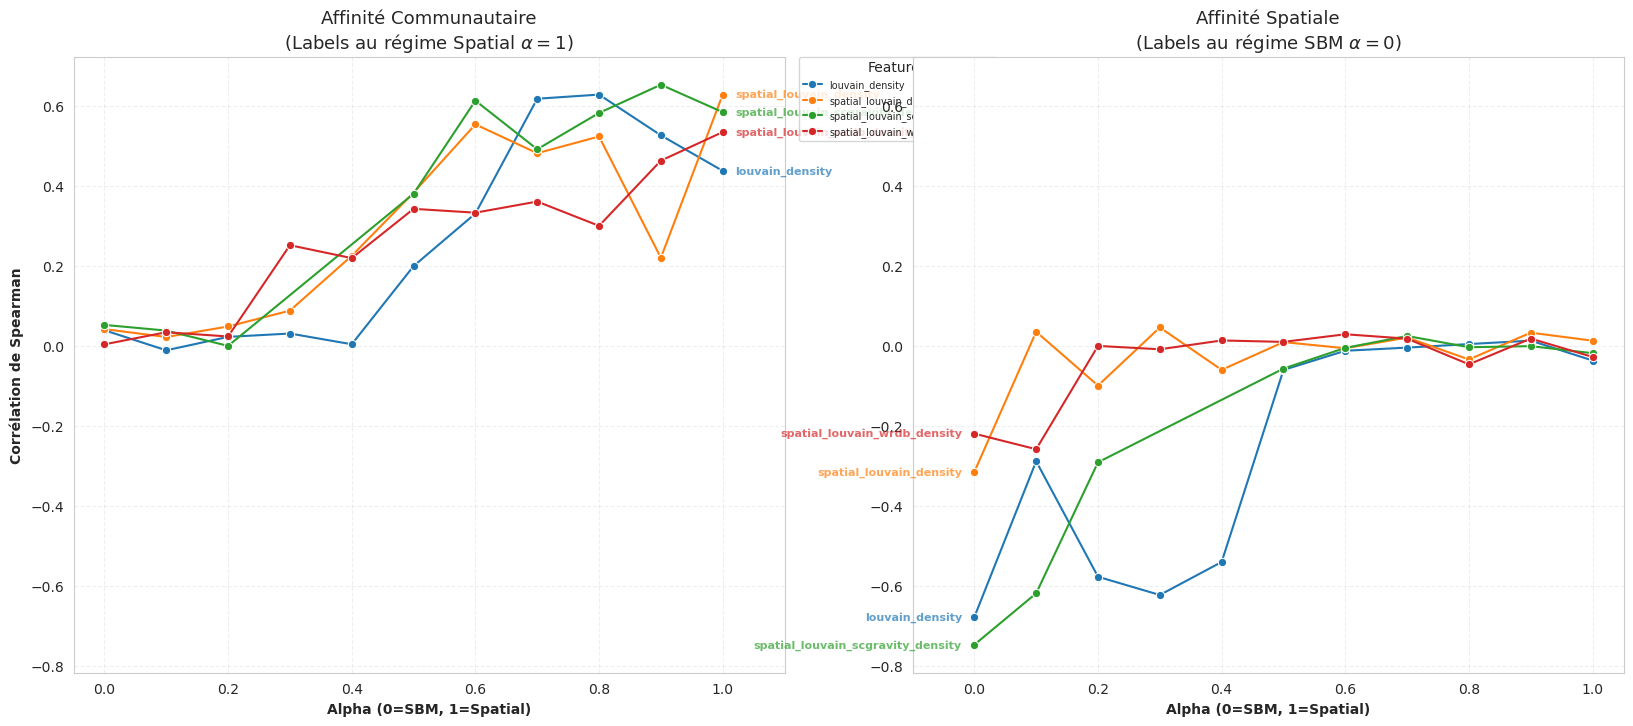

In [16]:
gt_commu = 'GT_sbm_density'
gt_spatial = 'GT_pos_dist'

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8), sharey=True)

def add_labels_inverted(ax, data, hue_col, x_target, alignment='left'):
    lines = ax.get_lines()
    features = data[hue_col].unique()
    for i, feature in enumerate(features):
        subset = data[data[hue_col] == feature]
        idx = (subset['alpha'] - x_target).abs().idxmin()
        point = subset.loc[idx]
        color = lines[i].get_color()
        offset = 0.02 if alignment == 'left' else -0.02
        ax.text(point['alpha'] + offset, point['correlation'], feature, fontsize=8, va='center', ha=alignment, color=color, fontweight='bold', alpha=0.7)

# --- Plot 1 : SBM (Labels à DROITE @ alpha=1.0) ---
data_commu = df_evolution[df_evolution['gt_feature'] == gt_commu]
sns.lineplot(data=data_commu, x='alpha', y='correlation', hue='feature', marker='o', ax=ax1)
ax1.set_title(f"Affinité Communautaire\n(Labels au régime Spatial $\\alpha=1$)", fontsize=13)
add_labels_inverted(ax1, data_commu, 'feature', x_target=1.0, alignment='left')
ax1.set_xlim(-0.05, 1.1) 
ax1.legend(title="Features", bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='x-small', borderaxespad=0.)

# --- Plot 2 : Spatial (Labels à GAUCHE @ alpha=0.0) ---
data_spatial = df_evolution[df_evolution['gt_feature'] == gt_spatial]
sns.lineplot(data=data_spatial, x='alpha', y='correlation', hue='feature', marker='o', ax=ax2, legend=False)
ax2.set_title(f"Affinité Spatiale\n(Labels au régime SBM $\\alpha=0$)", fontsize=13)
add_labels_inverted(ax2, data_spatial, 'feature', x_target=0.0, alignment='right')
ax2.set_xlim(-0.1, 1.05)

for ax in [ax1, ax2]:
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.set_xlabel("Alpha (0=SBM, 1=Spatial)", fontweight='bold')
    ax.set_ylabel("Corrélation de Spearman", fontweight='bold')
    ax2.tick_params(labelleft=True)
    ax2.yaxis.set_major_locator(plt.MultipleLocator(0.2))
    
plt.subplots_adjust(wspace=0.18) 
plt.show()

### 1.8 - Analyse de transférabilité

In [ ]:
features_GT_sbm = ['GT_sbm_density', 'same_GT_sbm']
features_commu_inferee = ['louvain_density', 'same_louvain', 'infomap_density', 'same_infomap', 'sbm_density', 'same_sbm',
                            'leiden_density', 'same_leiden', "surprise_density", "same_surprise", 
                            "significance_density", "same_significance"]
features_commu_surprise = ["surprise_density", "same_surprise"]

experiments = {
    "GT_sbm": features_GT_sbm,
    "Inferred_Commu only": features_commu_inferee,
    "Surprise_mothafucka": features_commu_surprise
 }

trained_models = {} 
all_transfer_results = []

G_source = f"artificial_graph_sbmv4_1_00_pos_0_00"
graphs_tests = ["artificial_graph_sbmv4_bis_1_00_pos_0_00",
                "artificial_graph_sbmv4_ter_1_00_pos_0_00",
                "artificial_graph_sbmv4_quad_1_00_pos_0_00"
               ]

print(f"\n--- PHASE 1 : Entrainement des modèles sur le graphe Source ---")
G_train_src , dataset_train_src, dataset_eval_src, _, _, _ = gp.load_all_data_for_graph(G_source)

pre_calculated_folds = gput._prepare_precalculated_folds(G_train_src, k=1)

for exp_name, feat_list in experiments.items():
    missing = set(feat_list) - set(dataset_train_src.columns)
    if missing:
        print(f" Exp {exp_name} : colonnes manquantes {missing}. Skip.")
        print(set(dataset_train_src.columns))
        continue

    print(f" Running: {exp_name}")
    Params, summary_optim = k_fold_cross_validation_exp(G_train_src, pre_calculated_folds, feat_list, n_trials=30)
    
    stats_df, model, X_test, _, y_test, _ = gp.train_and_test_xgboost(dataset_train_src, features=feat_list,
                                                                      parameters = Params, plot=False)

    X_src = dataset_eval_src[feat_list]
    y_src = dataset_eval_src["target"]

    stats_transfer = gp.get_performance_metrics(model, X_src, y_src, "TRANSFER_")
    importances = model.feature_importances_
    top_feat = feat_list[np.argmax(importances)]

    all_transfer_results.append({
            "Graph_name" : "GRAPH SOURCE",
            "Experiment": exp_name,
            "AUC_Transfer": stats_transfer["TRANSFER_AUC-ROC"].iloc[0],
            "AP_Transfer": stats_transfer["TRANSFER_AP"].iloc[0],
            "Top_Feature": top_feat
        })

    trained_models[exp_name] = {"model": model, "features": feat_list}


print(f"\n--- PHASE 2 : Test de transférabilité sur tous les graphes ---")
for target_graph_name in graphs_tests :
    print(f" Inférence sur : {target_graph_name}")
    try:
        _, _, dataset_eval_target, _, _, _ = gp.load_all_data_for_graph(target_graph_name)
    except:
        print(f" Graphe {target_graph_name} introuvable. Skip.")
        continue

    for exp_name, model_data in trained_models.items():
        model = model_data["model"]
        feat_list = model_data["features"]
        
        if not set(feat_list).issubset(dataset_eval_target.columns):
            continue

        X_target = dataset_eval_target[feat_list]
        y_target = dataset_eval_target["target"]
        
        stats_transfer = gp.get_performance_metrics(model, X_target, y_target, "TRANSFER_")
        
        importances = model.feature_importances_
        top_feat = feat_list[np.argmax(importances)]

        all_transfer_results.append({
            "Graph_name" : target_graph_name,
            "Experiment": exp_name,
            "AUC_Transfer": stats_transfer["TRANSFER_AUC-ROC"].iloc[0],
            "AP_Transfer": stats_transfer["TRANSFER_AP"].iloc[0],
            "Top_Feature": top_feat
        })

# --- RÉCAPITULATIF ET ANALYSE ---
df_transfer = pd.DataFrame(all_transfer_results)
print("\n" + "="*60)
print("RÉSULTATS DE TRANSFÉRABILITÉ (Modèle Source -> Graphes Cibles)")
print("="*60)
pivot_results = df_transfer.pivot(index="Graph_name", columns="Experiment", values="AUC_Transfer")
print(pivot_results.to_string(float_format=lambda x: "{:,.4f}".format(x)))

In [ ]:
plot_f1_comparison(df_transfer, metric="AUC_Transfer")

### 1.9 - NullModels spatiaux inférés, analyse

In [48]:
def plot_null_model_comparison(G1, G2, mode="residuals", p_matrix_name="P_Null_model_ManualIter", title1="Graphe P_pos", title2="Graphe deepwalk"):
    """
    mode="residuals" -> Affiche la distribution de (A - P)
    mode="probabilities" -> Affiche la distribution de P
    """
    def get_analysis_data(G, p_name, mode):
        A = nx.to_numpy_array(G)
        P = G.graph.get(p_name)
        if P is None: return None, None
        
        if mode == "residuals":
            return (A - P).flatten(), "Résidus globaux ($A_{ij} - P_{ij}$)"
        elif mode == "probabilities":
            # Focus uniquement sur les liens existants
            mask = (A == 1)
            return P[mask], "Probabilités $P_{ij}$ (Uniquement sur liens réels)"
        else : 
            print(f"ERREUR : mode non reconnu : {mode}")
            return None

    data1, label = get_analysis_data(G1, p_matrix_name, mode)
    data2, _ = get_analysis_data(G2, p_matrix_name, mode)

    if data1 is None or data2 is None:
        print(f"Erreur : Matrice {p_matrix_name} manquante.")
        return

    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
    
    # Code couleur différencié pour ne pas s'embrouiller
    c1, c2 = ('#3498db', '#95a5a6') if mode == "residuals" else ('#8e44ad', '#f1c40f')

    sns.histplot(data1, kde=True, ax=axes[0], color=c1)
    axes[0].set_title(f"{title1}\n{p_matrix_name}")
    
    sns.histplot(data2, kde=True, ax=axes[1], color=c2)
    axes[1].set_title(f"{title2}\n{p_matrix_name}")

    for ax in axes:
        ax.set_xlabel(label)
        if mode == "residuals":
            ax.axvline(0, color='black', linestyle='--', alpha=0.5)
        else:
            ax.set_xlim(0, 1) # Les probas sont bornées
            ax.axvline(np.mean(data1), color=c1, linestyle=':', label=f'Moy {title1}')
            ax.axvline(np.mean(data2), color=c2, linestyle=':', label=f'Moy {title2}')
            ax.legend()

    plt.suptitle(f"Enquête Null Model : {label}", fontsize=14, fontweight='bold')
    plt.tight_layout()
    #plt.show()

    print(f"[{mode.upper()}] {title1} -> Moyenne: {np.mean(data1):.4f}, Médiane: {np.median(data1):.4f}, Std: {np.std(data1):.4f}")
    print(f"[{mode.upper()}] {title2} -> Moyenne: {np.mean(data2):.4f}, Médiane: {np.median(data2):.4f}, Std: {np.std(data2):.4f}")

--------- sbm_val 0.00 Iter 1 ---------
[RESIDUALS] Graphe P_pos -> Moyenne: 0.0000, Médiane: -0.0091, Std: 0.2651
[RESIDUALS] Graphe deepwalk -> Moyenne: 0.0000, Médiane: -0.0040, Std: 0.2607
[PROBABILITIES] Graphe P_pos -> Moyenne: 0.4465, Médiane: 0.4696, Std: 0.2204
[PROBABILITIES] Graphe deepwalk -> Moyenne: 0.4677, Médiane: 0.4766, Std: 0.2245
--------- sbm_val 0.10 Iter 1 ---------
[RESIDUALS] Graphe P_pos -> Moyenne: 0.0000, Médiane: -0.0197, Std: 0.2770
[RESIDUALS] Graphe deepwalk -> Moyenne: 0.0001, Médiane: -0.0124, Std: 0.2666
[PROBABILITIES] Graphe P_pos -> Moyenne: 0.3882, Médiane: 0.4122, Std: 0.2080
[PROBABILITIES] Graphe deepwalk -> Moyenne: 0.4430, Médiane: 0.4451, Std: 0.2448
--------- sbm_val 0.20 Iter 1 ---------
[RESIDUALS] Graphe P_pos -> Moyenne: 0.0000, Médiane: -0.0348, Std: 0.2913
[RESIDUALS] Graphe deepwalk -> Moyenne: 0.0000, Médiane: -0.0207, Std: 0.2790
[PROBABILITIES] Graphe P_pos -> Moyenne: 0.3269, Médiane: 0.3385, Std: 0.1927
[PROBABILITIES] Graphe de

/tmp/ipykernel_271/371726594.py:28: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)


[RESIDUALS] Graphe P_pos -> Moyenne: -0.0001, Médiane: -0.0815, Std: 0.3170
[RESIDUALS] Graphe deepwalk -> Moyenne: 0.0000, Médiane: -0.0063, Std: 0.2602
[PROBABILITIES] Graphe P_pos -> Moyenne: 0.2005, Médiane: 0.1812, Std: 0.1206
[PROBABILITIES] Graphe deepwalk -> Moyenne: 0.4712, Médiane: 0.4800, Std: 0.2503


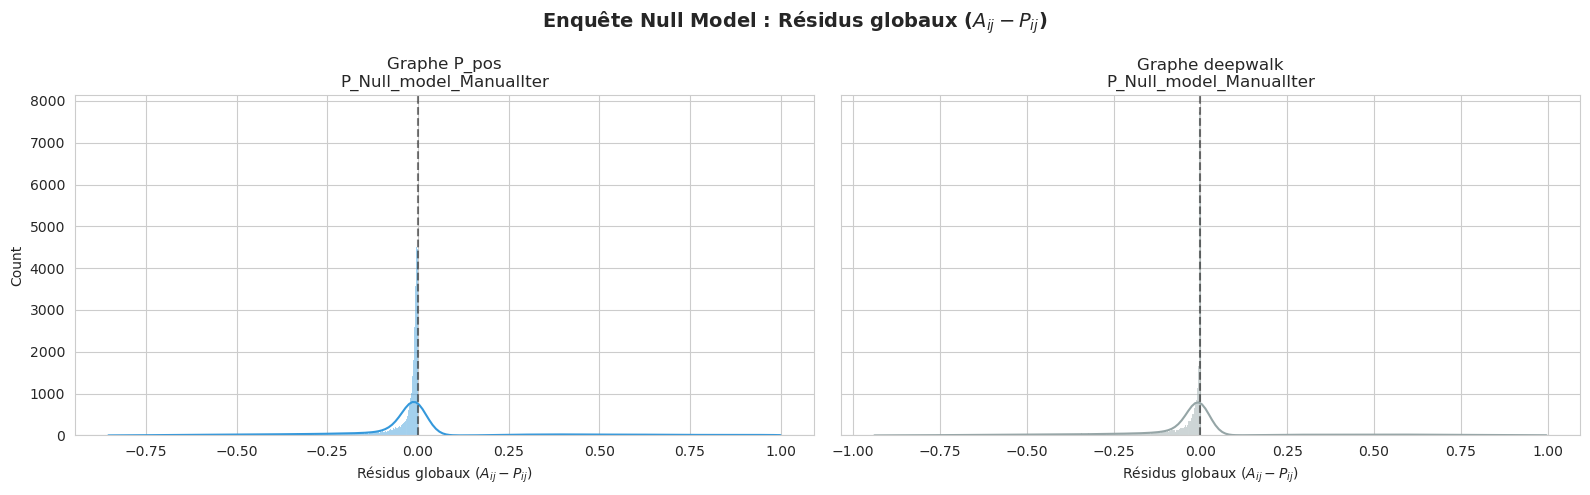

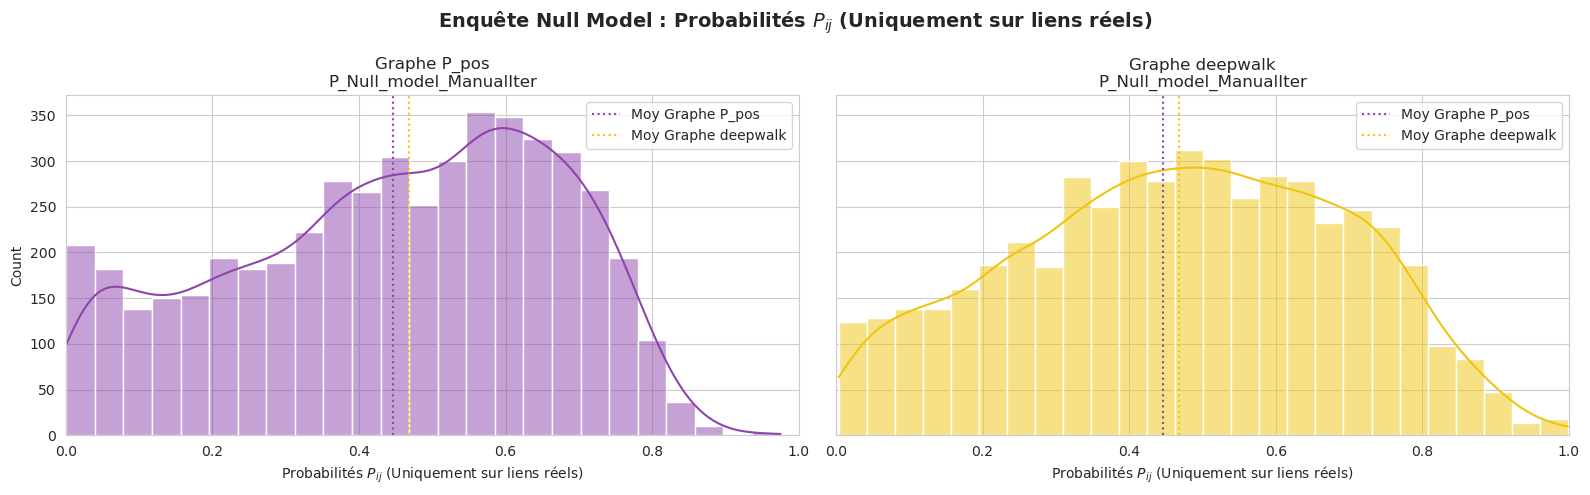

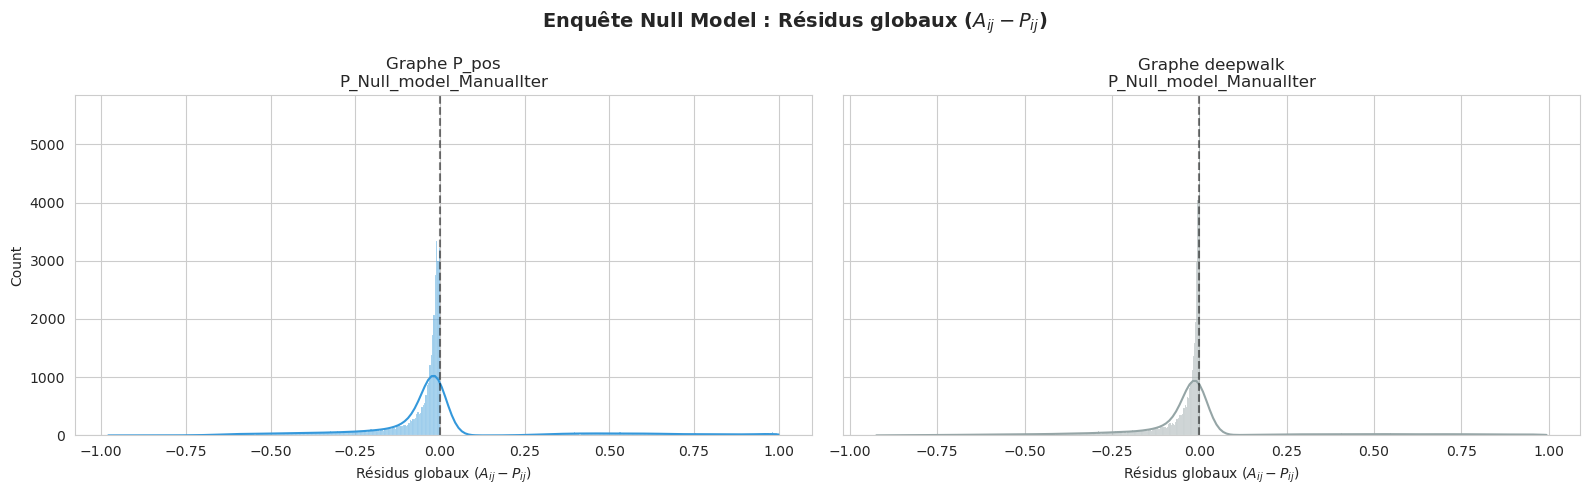

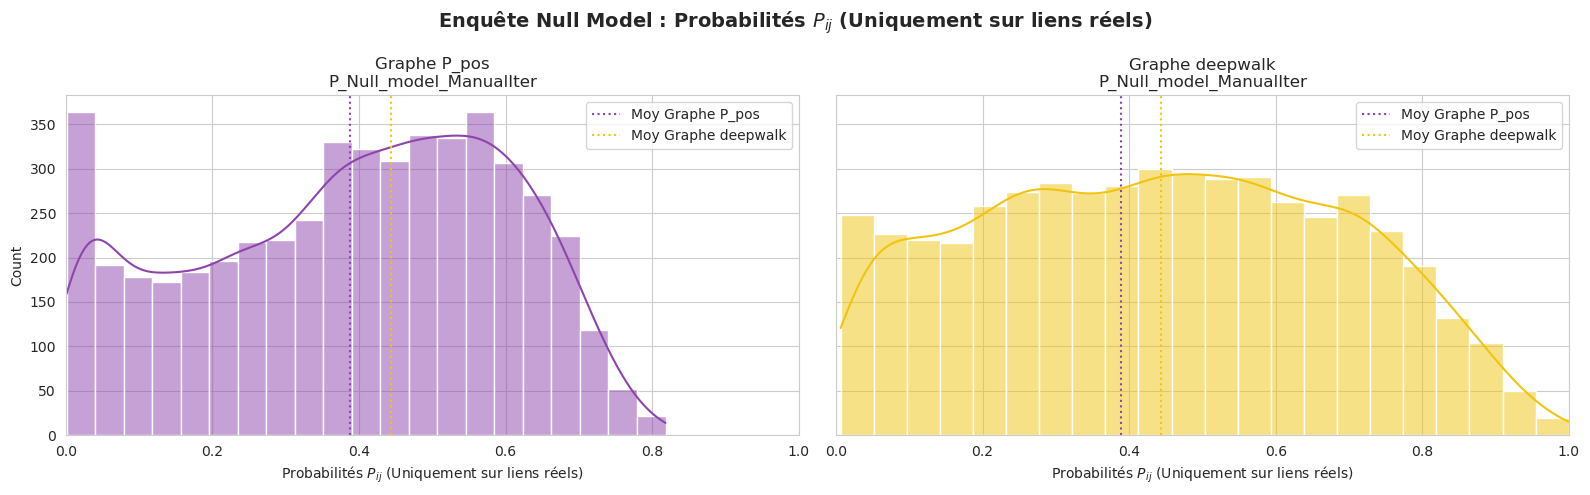

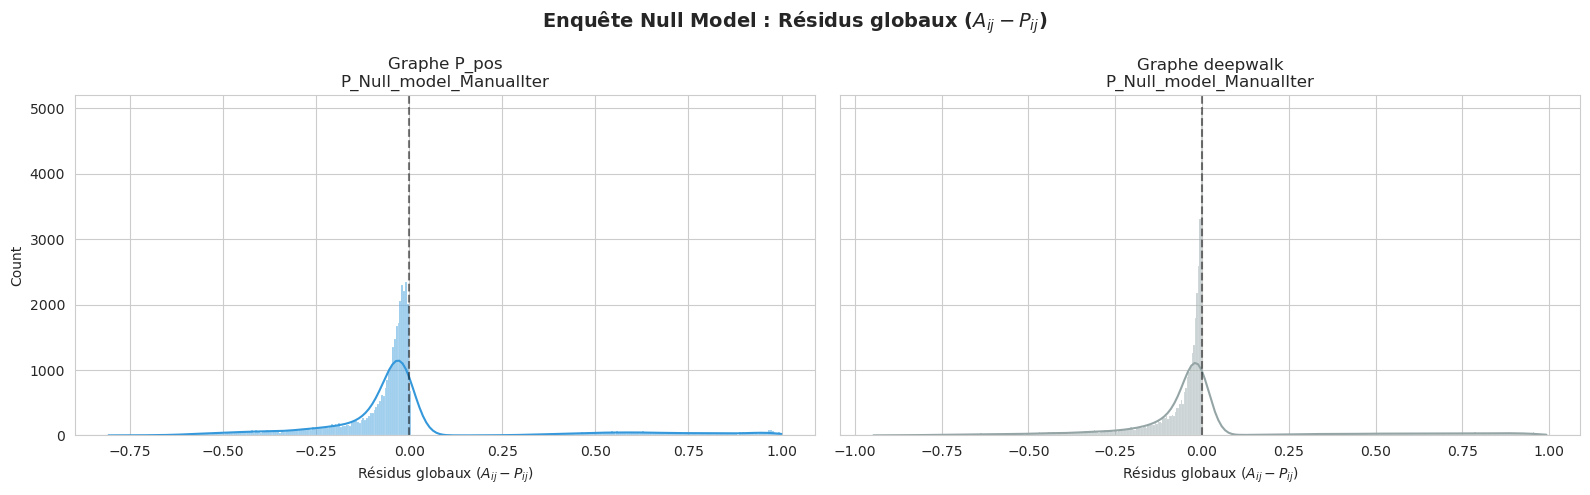

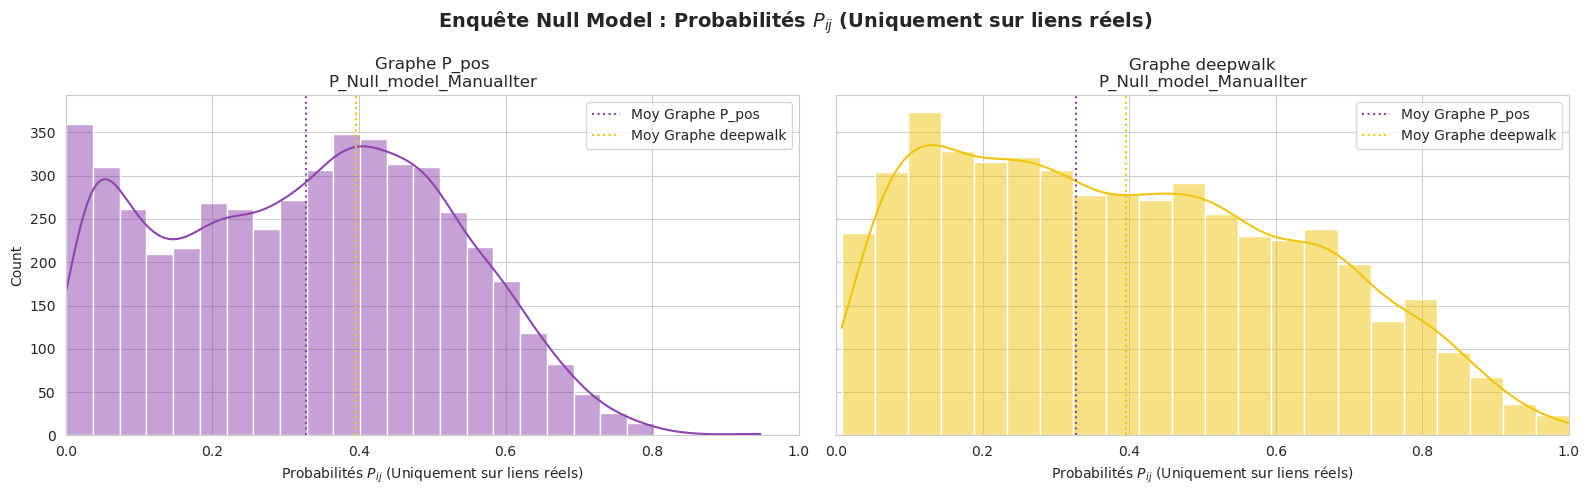

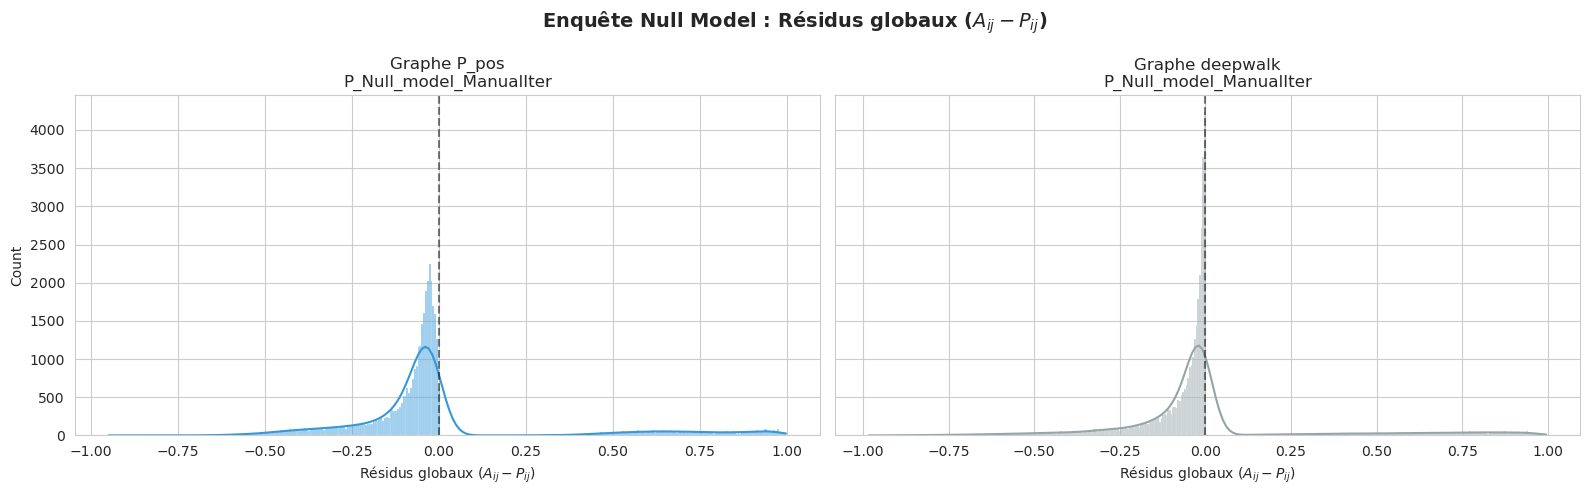

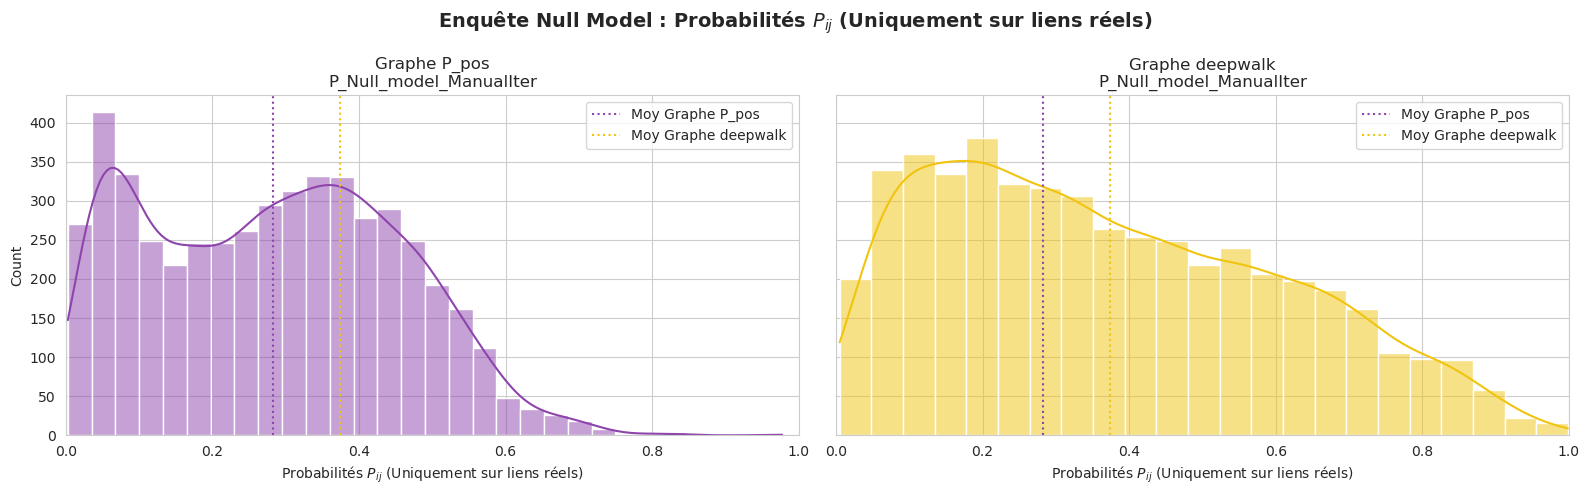

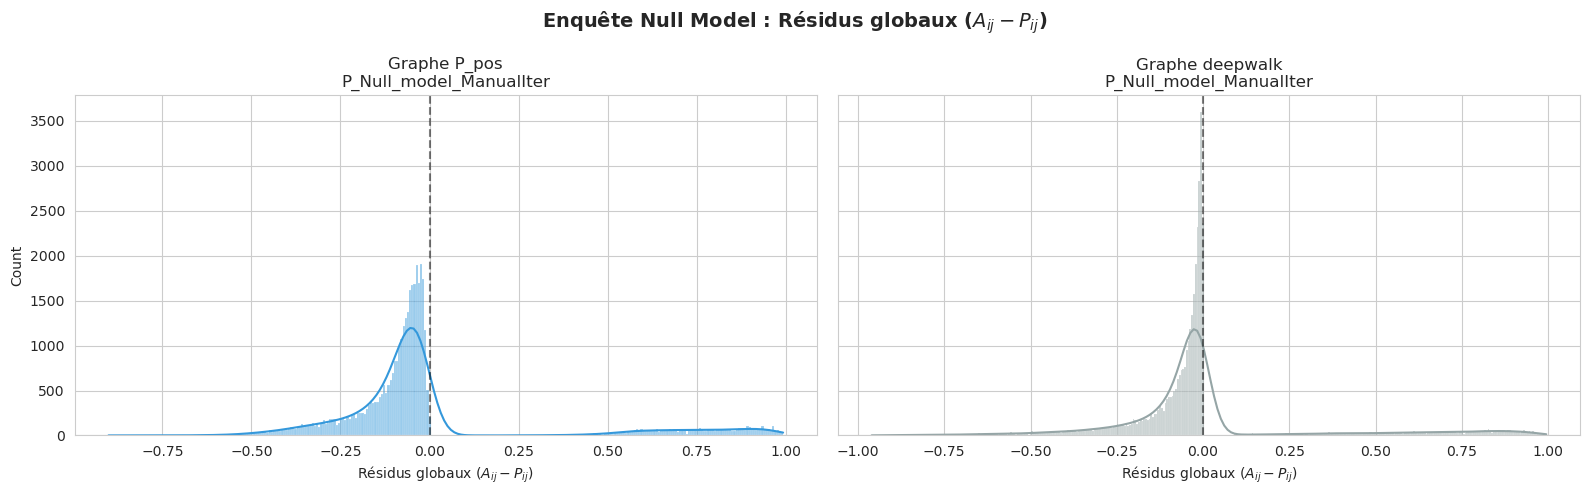

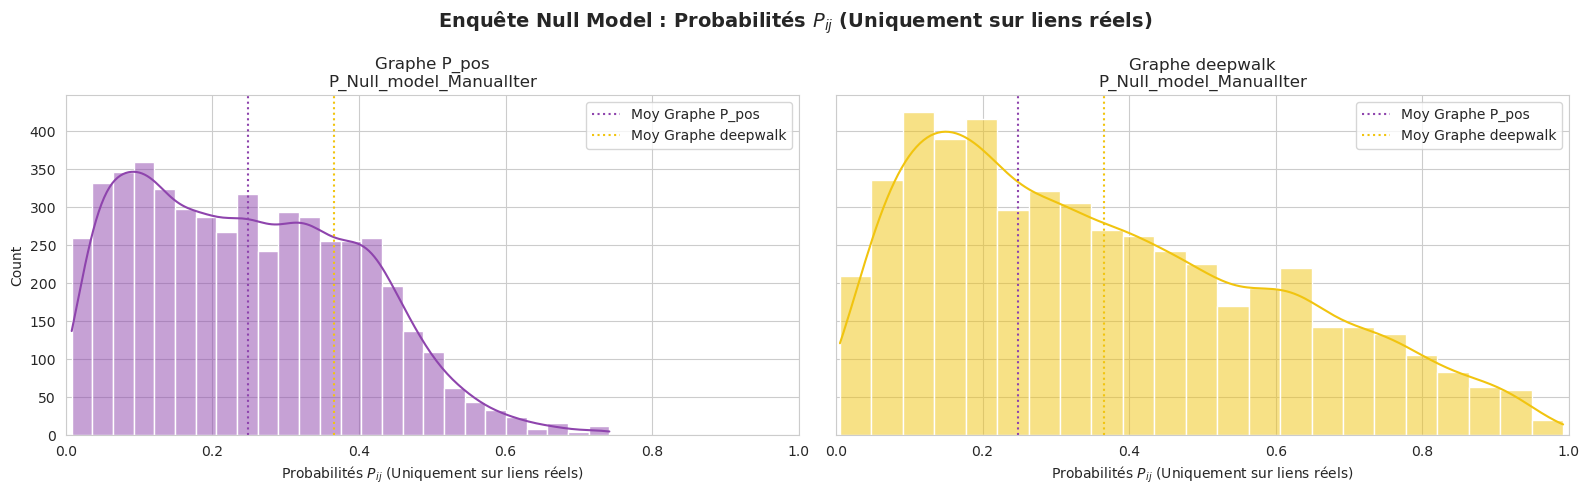

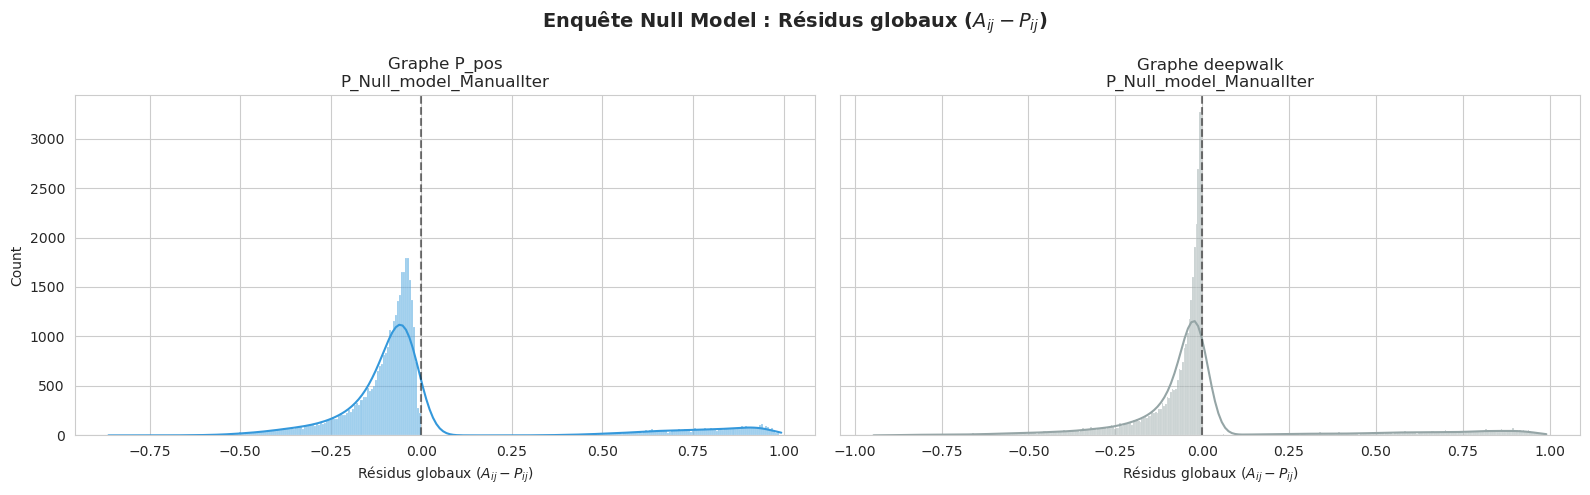

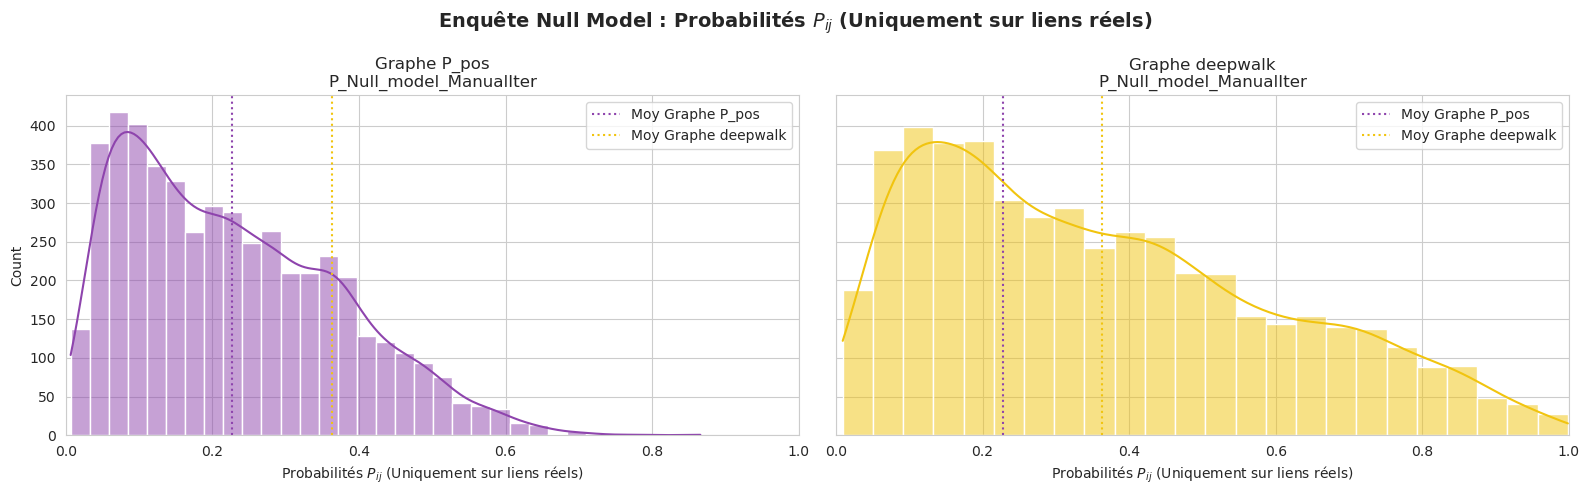

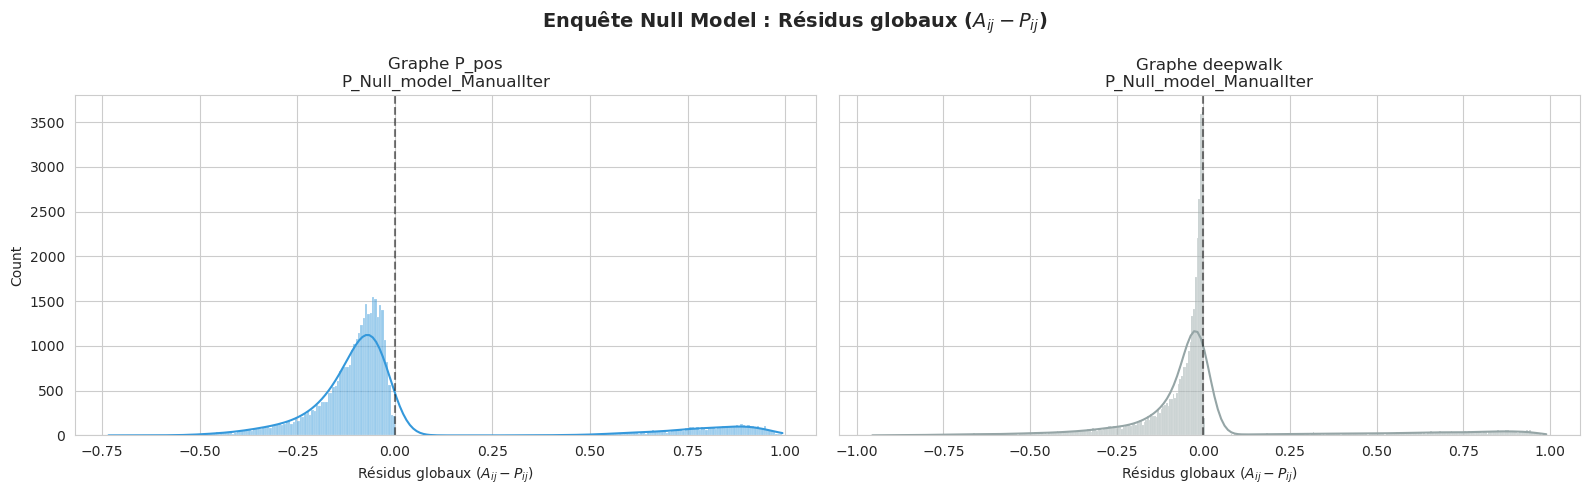

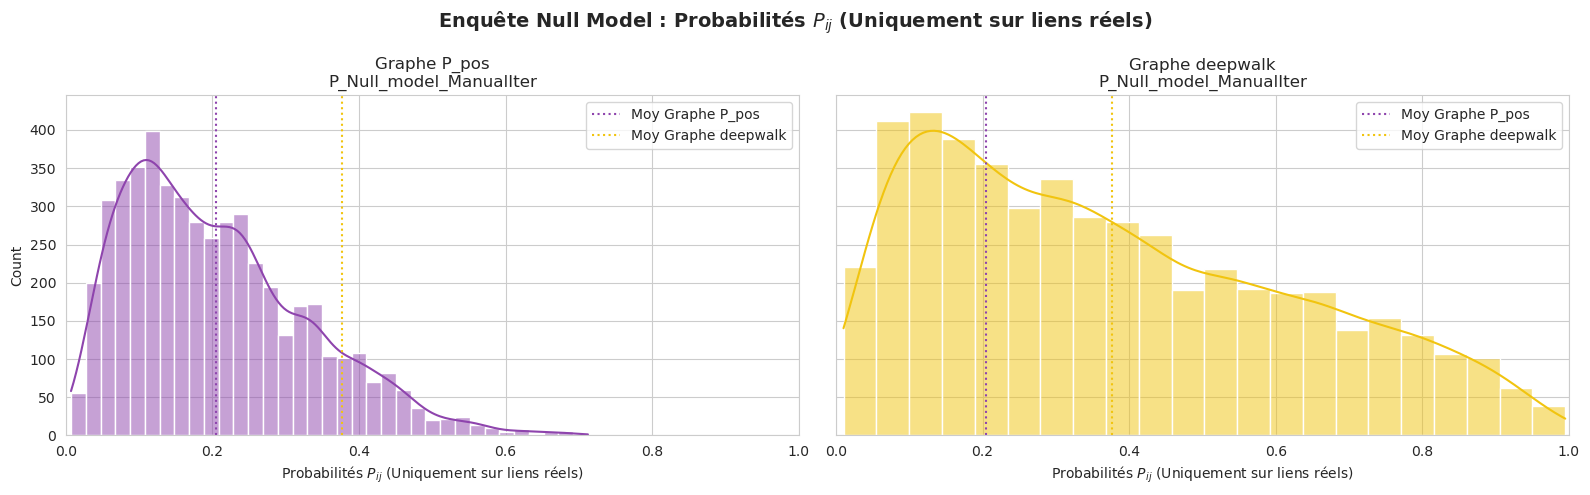

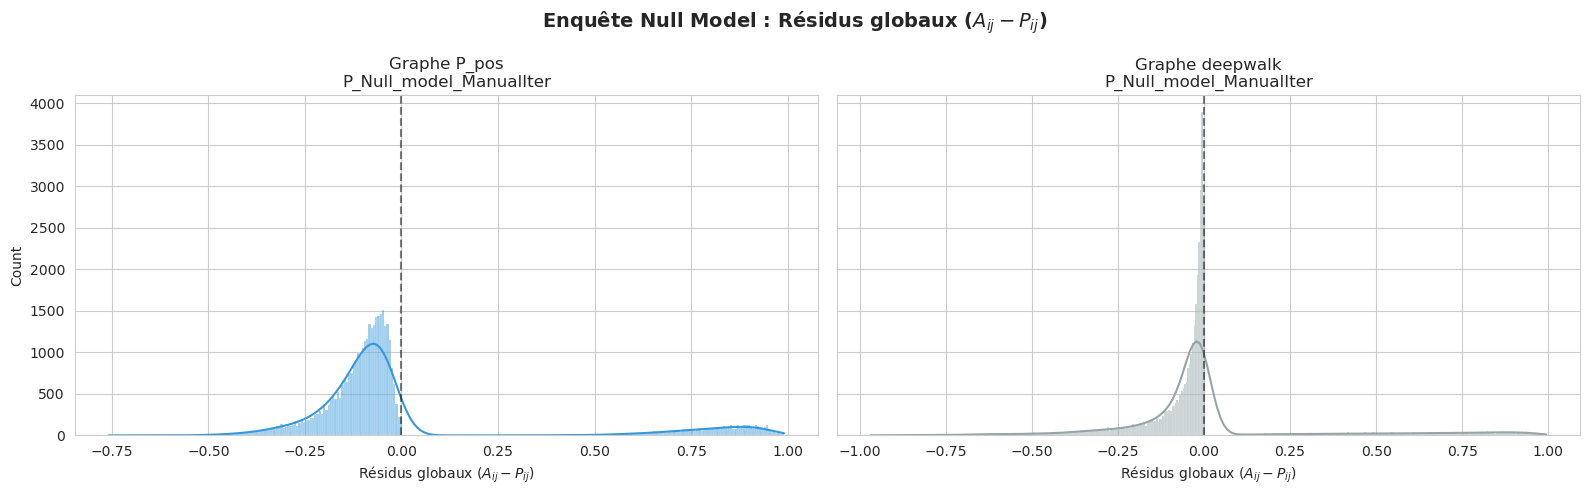

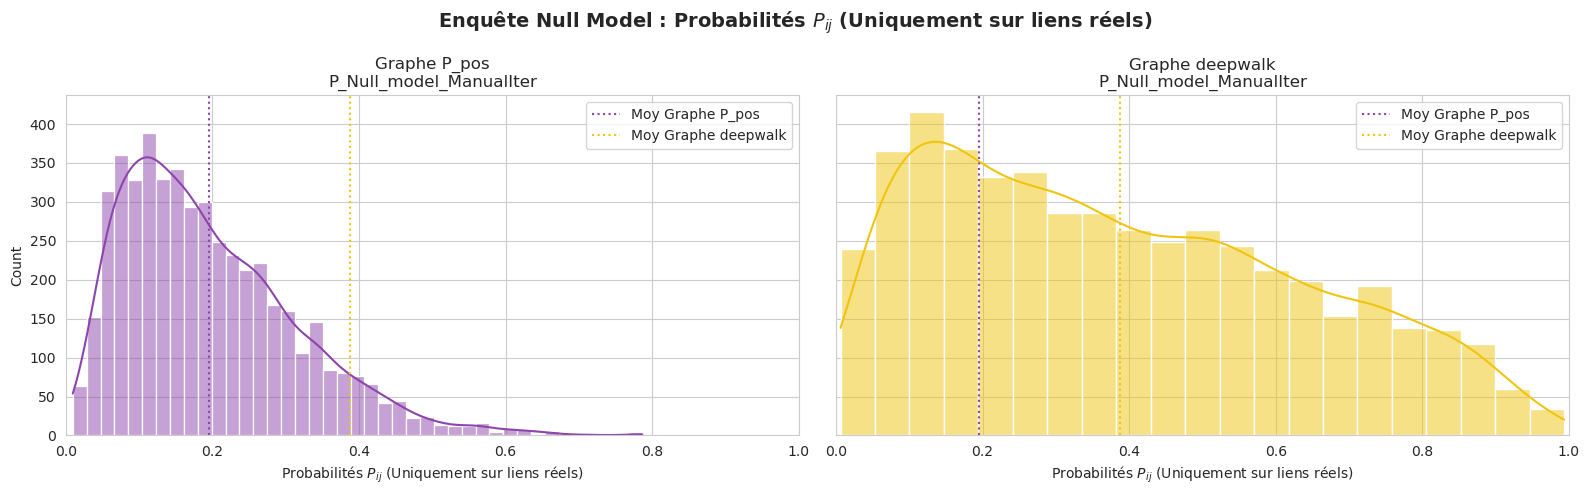

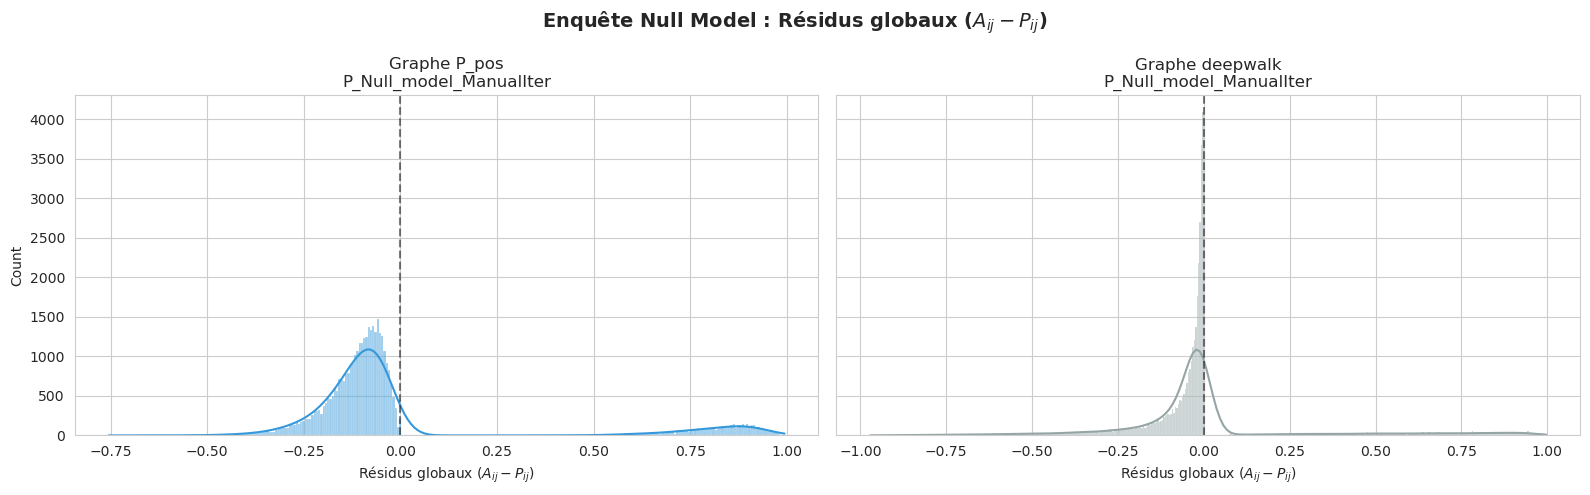

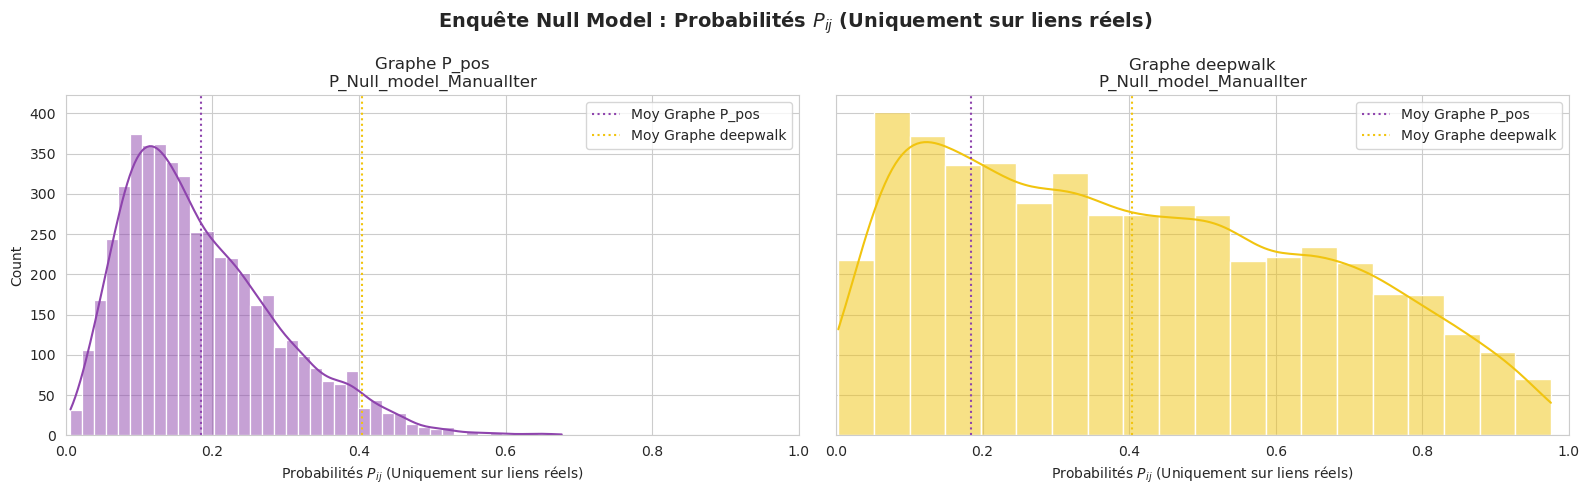

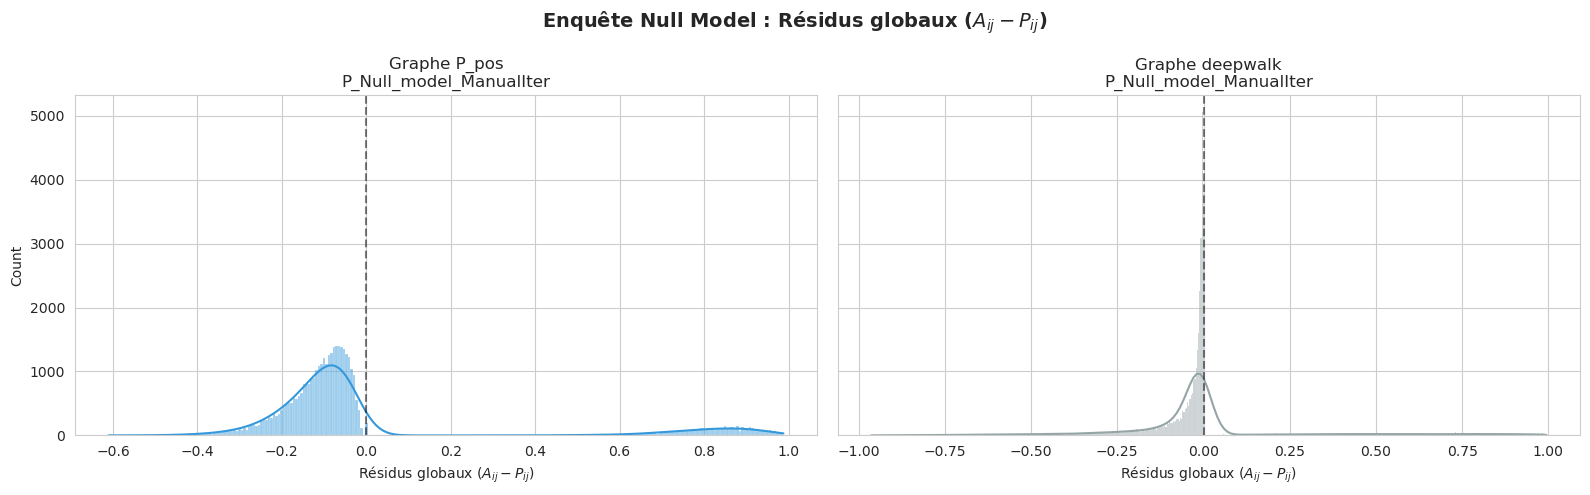

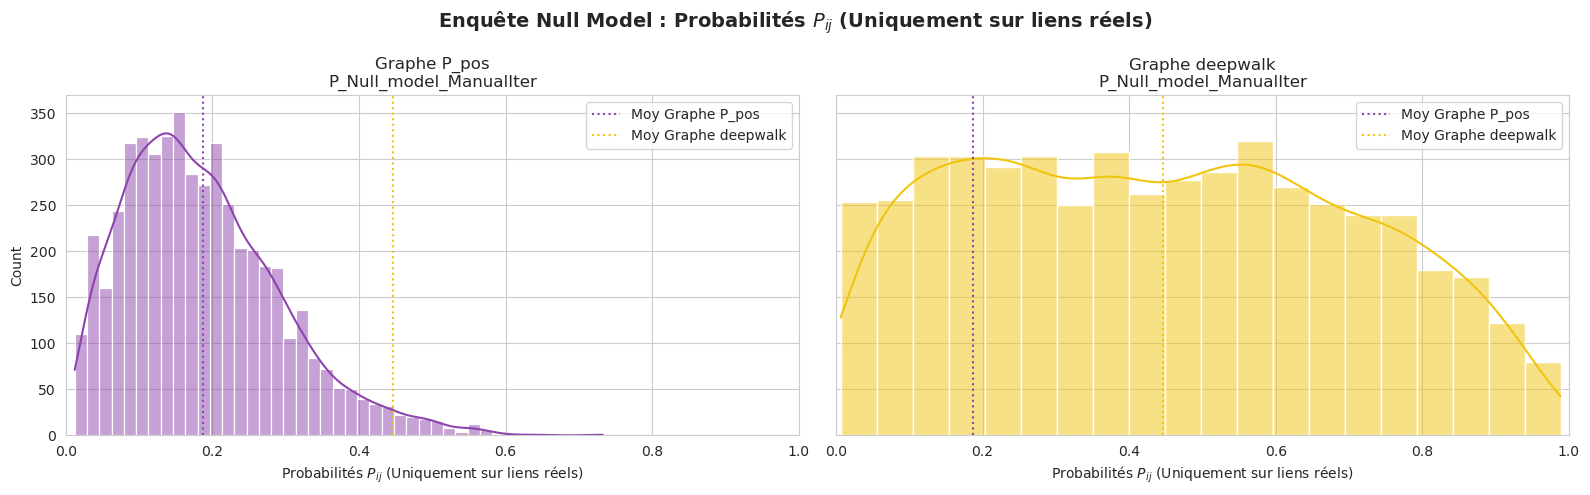

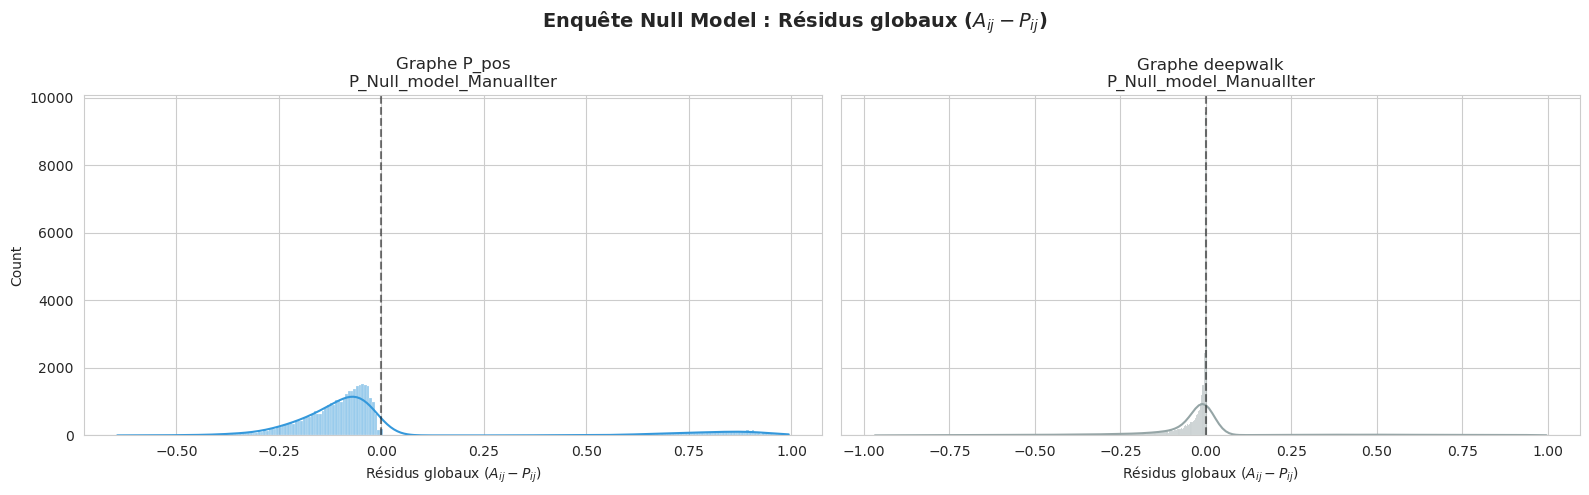

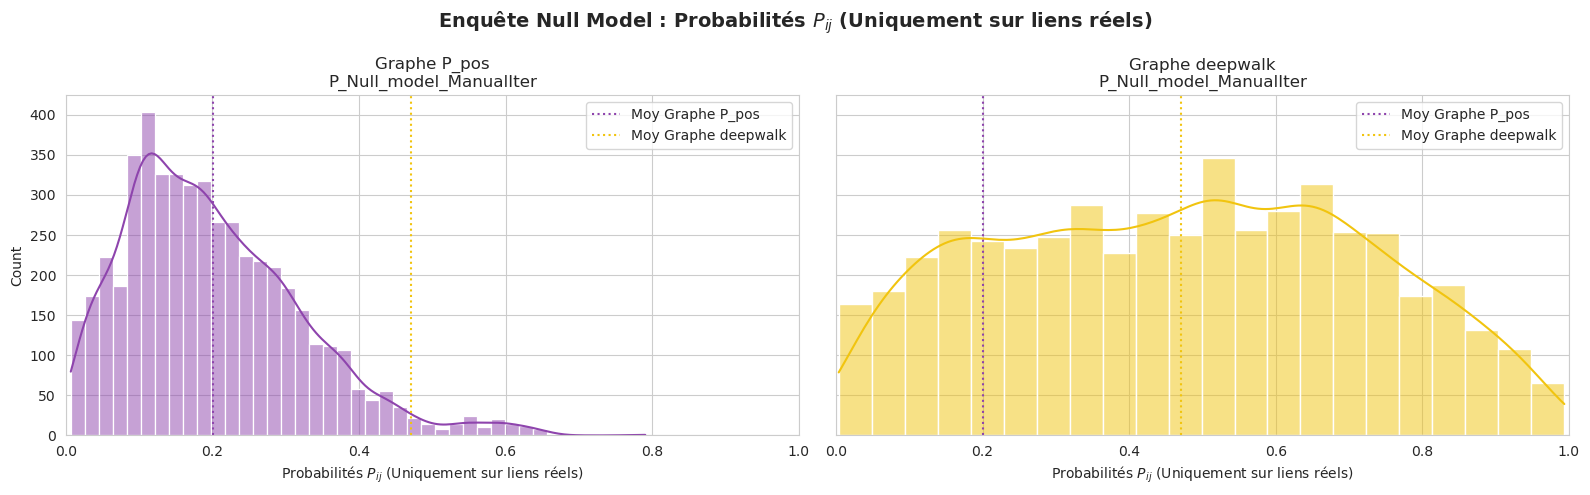

In [49]:
for i_rep in range(1, 2):
    for j in np.arange(0.00, 1.10, 0.10):
        sbm_val = f"{j:.2f}"
        pos_val = f"{1-j:.2f}"
        #G_name = f"artificial_graph_sbmv4_{sbm_val.replace('.', '_')}_pos_{pos_val.replace('.', '_')}"
        G_name = f"artificial_graph_sbmv4_{sbm_val.replace('.', '_')}_pos_{pos_val.replace('.', '_')}_{i_rep}"
        
        # 1. Chargement des données d'entraînement
        #Graph, dataset_train, dataset_eval, _, _, _ = gp.load_all_data_for_graph(G_name)
        Graph_GT_Pos = gp.loadsave_data_joblib(data=None, filename=f"G_kept_w_struct_com_dist_{G_name}", mode="load")
        Graph_deepwalk = gp.loadsave_data_joblib(data=None, filename=f"G_kept_w_struct_com_dist_{G_name}_deepwalk", mode="load")

        print("="*60)
        print(f"--------- sbm_val {sbm_val} Iter {i_rep} ---------")
        print("="*60)
        plot_null_model_comparison(Graph_GT_Pos, Graph_deepwalk, mode="residuals", p_matrix_name="P_Null_model_ManualIter")
        plot_null_model_comparison(Graph_GT_Pos, Graph_deepwalk, mode="probabilities", p_matrix_name="P_Null_model_ManualIter")


## 2 - Exploration des Shap values

### 2.1 - Concaténation des Shap_Values pour toutes les valeurs de ratio_sbm

In [9]:
all_summaries = []

for iteration in range (0,4):
#for i in np.arange(0, 1.10, 0.10):
    #sbm_val = f"{i:.2f}"
    #pos_val = f"{1-i:.2f}"
    #G_name = f"artificial_graph_sbmv4_{sbm_val.replace('.', '_')}_pos_{pos_val.replace('.', '_')}"
    G_name=f"Airports_{iteration}"
    
    _, _, _, xgboost_data, shap_explainer, _ = gp.load_all_data_for_graph(G_name)
    X_test = xgboost_data['X_test']

    print(f"Type de l'objet : {type(shap_explainer)}")
    print(f"Dimensions des valeurs : {shap_explainer.values.shape}")

    vals = shap_explainer.values
    
    if isinstance(vals, list):
        vals = vals[1]

    df_shap = pd.DataFrame(vals, columns=X_test.columns)
    mean_shap = df_shap.mean()
    mean_abs_shap = df_shap.abs().mean()
    
    summary = pd.DataFrame({
        'feature': X_test.columns,
        'mean_shap': mean_shap.values,
        'mean_abs_shap': mean_abs_shap.values,
        #'sbm_param': i
        'sbm_param': iteration
    })
    all_summaries.append(summary)

df_shapvals_concat = pd.concat(all_summaries)


G_train introuvable pour Airports_0, création d'un graphe vide.
SHAP Analysis introuvable pour Airports_0.
Type de l'objet : <class 'shap._explanation.Explanation'>
Dimensions des valeurs : (2710, 6)
G_train introuvable pour Airports_1, création d'un graphe vide.
SHAP Analysis introuvable pour Airports_1.
Type de l'objet : <class 'shap._explanation.Explanation'>
Dimensions des valeurs : (2710, 6)
G_train introuvable pour Airports_2, création d'un graphe vide.
SHAP Analysis introuvable pour Airports_2.
Type de l'objet : <class 'shap._explanation.Explanation'>
Dimensions des valeurs : (2710, 6)
G_train introuvable pour Airports_3, création d'un graphe vide.
SHAP Analysis introuvable pour Airports_3.
Type de l'objet : <class 'shap._explanation.Explanation'>
Dimensions des valeurs : (2710, 6)


### 2.2 - Plot des shap_values par sbm_ratio et par feature

Graphique sauvegardé sous : outputs/plots/heatmap_feat_importance_per_ratio_v5_reduced_GT_mean_abs_shap.png


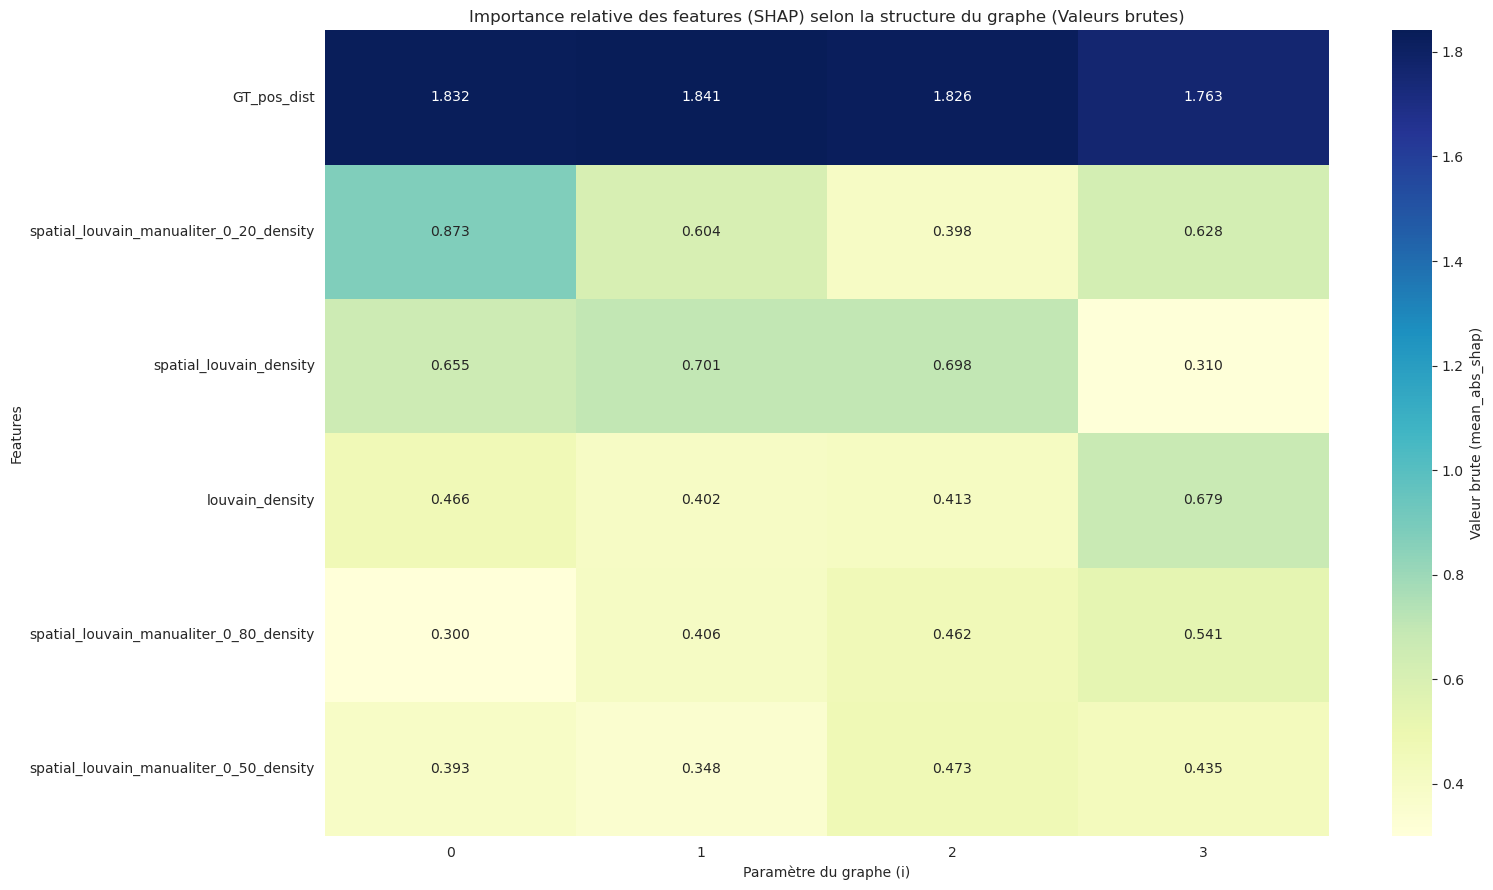

Index(['feature', 'mean_shap', 'mean_abs_shap', 'sbm_param'], dtype='object')
louvain_density, spatial_louvain_density, spatial_louvain_manualiter_0_20_density, spatial_louvain_manualiter_0_50_density, spatial_louvain_manualiter_0_80_density, GT_pos_dist, louvain_density, spatial_louvain_density, spatial_louvain_manualiter_0_20_density, spatial_louvain_manualiter_0_50_density, spatial_louvain_manualiter_0_80_density, GT_pos_dist, louvain_density, spatial_louvain_density, spatial_louvain_manualiter_0_20_density, spatial_louvain_manualiter_0_50_density, spatial_louvain_manualiter_0_80_density, GT_pos_dist, louvain_density, spatial_louvain_density, spatial_louvain_manualiter_0_20_density, spatial_louvain_manualiter_0_50_density, spatial_louvain_manualiter_0_80_density, GT_pos_dist


'\nall_distribs = []\nfor i in np.arange(0, 1.05, 0.05):\n    sbm_val = f"{i:.2f}"\n    pos_val = f"{1-i:.2f}"\n    G_name = f"artificial_graph_sbm_{sbm_val.replace(\'.\', \'_\')}_pos_{pos_val.replace(\'.\', \'_\')}"\n    \n    _, _,_, xgboost_data, _, _ = gp.load_all_data_for_graph(G_name)\n    X_test = xgboost_data[\'X_test\']\n    y_test = xgboost_data[\'y_test\']\n    \n    pos_sp = X_test[y_test == 1][\'sp\'].value_counts(normalize=True).to_dict()\n    neg_sp = X_test[y_test == 0][\'sp\'].value_counts(normalize=True).to_dict()\n    \n    row = {\'sbm_param\': round(i, 2)}\n    for dist in range(1, 7):\n        row[f\'pos_sp_{dist}\'] = pos_sp.get(dist, 0)\n        row[f\'neg_sp_{dist}\'] = neg_sp.get(dist, 0)\n    \n    row[\'pos_sp_7+\'] = sum(v for k, v in pos_sp.items() if k >= 7 or k == 0)\n    row[\'neg_sp_7+\'] = sum(v for k, v in neg_sp.items() if k >= 7 or k == 0)\n    \n    all_distribs.append(row)\n\ndf_sp_detailed = pd.DataFrame(all_distribs)\n\ncols = [\'sbm_param\'] +

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

def plot_feature_importance_evolution(df_results, metric="mean_shap", as_ratio=True):
    """
    Génère une heatmap montrant l'évolution de l'importance des features (SHAP).
    """
    heatmap_data = df_results.pivot(index='feature', columns='sbm_param', values=metric)
    
    if as_ratio:
        heatmap_data = heatmap_data.div(heatmap_data.sum(axis=0), axis=1)
        label_name = f"Ratio de contribution ({metric})"
        fmt_type = ".2%"
    else:
        label_name = f"Valeur brute ({metric})"
        fmt_type = ".3f"

    heatmap_data['avg_importance'] = heatmap_data.mean(axis=1)
    heatmap_data = heatmap_data.sort_values(by='avg_importance', ascending=False).drop(columns='avg_importance')

    plt.figure(figsize=(16, 9))
    sns.heatmap(heatmap_data, annot=True, fmt=fmt_type, cmap="YlGnBu", yticklabels=True, cbar_kws={'label': label_name})

    title_suffix = "(Ratios normalisés)" if as_ratio else "(Valeurs brutes)"
    plt.title(f"Importance relative des features (SHAP) selon la structure du graphe {title_suffix}")
    plt.xlabel("Paramètre du graphe (i)")
    plt.ylabel("Features")
    plt.tight_layout()

    filename = f"outputs/plots/heatmap_feat_importance_per_ratio_v5_reduced_GT_{metric}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"Graphique sauvegardé sous : {filename}")
    plt.show()

plot_feature_importance_evolution(df_shapvals_concat, metric="mean_abs_shap", as_ratio=False)
print(df_shapvals_concat.columns)
features_list = df_shapvals_concat['feature']
print(", ".join(map(str, features_list)))

"""
all_distribs = []
for i in np.arange(0, 1.05, 0.05):
    sbm_val = f"{i:.2f}"
    pos_val = f"{1-i:.2f}"
    G_name = f"artificial_graph_sbm_{sbm_val.replace('.', '_')}_pos_{pos_val.replace('.', '_')}"
    
    _, _,_, xgboost_data, _, _ = gp.load_all_data_for_graph(G_name)
    X_test = xgboost_data['X_test']
    y_test = xgboost_data['y_test']
    
    pos_sp = X_test[y_test == 1]['sp'].value_counts(normalize=True).to_dict()
    neg_sp = X_test[y_test == 0]['sp'].value_counts(normalize=True).to_dict()
    
    row = {'sbm_param': round(i, 2)}
    for dist in range(1, 7):
        row[f'pos_sp_{dist}'] = pos_sp.get(dist, 0)
        row[f'neg_sp_{dist}'] = neg_sp.get(dist, 0)
    
    row['pos_sp_7+'] = sum(v for k, v in pos_sp.items() if k >= 7 or k == 0)
    row['neg_sp_7+'] = sum(v for k, v in neg_sp.items() if k >= 7 or k == 0)
    
    all_distribs.append(row)

df_sp_detailed = pd.DataFrame(all_distribs)

cols = ['sbm_param'] + [f'{prefix}_sp_{d}' for d in list(range(1, 7)) + ['7+'] for prefix in ['pos', 'neg']]
df_sp_detailed = df_sp_detailed[cols]

pd.options.display.float_format = '{:.3f}'.format
print(df_sp_detailed.to_string(index=False))
"""

### 2.3 - Exploration du ranking des SHAP vals des features sur chaque paire (voir si qq métriques on avg pas ouf perfs fort sur qq paires) 

In [ ]:
def plot_feature_importance_heatmap(df_results, output_filename="heatmap_shap_percentage_presence_top_k.png"):
    """
    Génère une heatmap dynamique selon le ratio présent dans le DataFrame.
    """
    ratio_col = [c for c in df_results.columns if '_ratio' in c][0]
    k_val = ratio_col.replace('top', '').replace('_ratio', '')

    heatmap_data = df_results.pivot(index='feature', columns='sbm_param', values=ratio_col)
    
    heatmap_data['avg'] = heatmap_data.mean(axis=1)
    heatmap_data = heatmap_data.sort_values('avg', ascending=False).drop(columns='avg')

    plt.figure(figsize=(14, 8))
    sns.heatmap(heatmap_data, 
                annot=True, 
                fmt=".1%", 
                cmap="YlGnBu", 
                cbar_kws={'label': f'% de présence au Top {k_val} (SHAP)'})

    plt.title(f"Évolution de la dominance des features (Top {k_val})")
    plt.xlabel("Paramètre SBM (i)")
    plt.ylabel("Features")
    
    os.makedirs("outputs/plots", exist_ok=True)
    plt.savefig(f"outputs/plots/{output_filename}", dpi=300, bbox_inches='tight')
    plt.show()


results_list = []
k_target = 3 

for i in np.arange(0, 1.05, 0.25):
    sbm_val = f"{i:.2f}"
    pos_val = f"{1-i:.2f}"
    G_name = f"artificial_graph_sbmv2_{sbm_val.replace('.', '_')}_pos_{pos_val.replace('.', '_')}"
    
    try:
        _, _, _, xgboost_data, shap_explainer, _ = gp.load_all_data_for_graph(G_name)
        vals = shap_explainer.values
        if isinstance(vals, list): vals = vals[1]

        df_ranks = gp.calculate_feature_rankings(vals, xgboost_data['X_test'].columns, top_k=k_target, plot=False)
        
        top_k_sum = df_ranks.iloc[0:k_target, :].sum(axis=0)
        
        for feat_name, val in top_k_sum.items():
            results_list.append({
                'sbm_param': i,
                'feature': feat_name,
                f'top{k_target}_ratio': val / 100  
            })
            
    except Exception as e:
        print(f"Skipping {G_name} due to error: {e}")

df_shap_rankings = pd.DataFrame(results_list)

plot_feature_importance_heatmap(df_shap_rankings)

### 2.4 - Explo locale des shap values par catégorie & corrélations

In [20]:
from scipy import stats

def plot_Dominance_Index_VS_probas(explainability_dataset, ax, ratio_sbm):
    rho, _ = stats.spearmanr(explainability_dataset["Dominance_probas_Index"], explainability_dataset["Dominance_Index"])
    
    sns.regplot(
        data=explainability_dataset,
        x="Dominance_probas_Index",
        y="Dominance_Index",
        scatter_kws={'alpha': 0.3, 's': 10, 'color': 'steelblue'}, # Couleur de base
        line_kws={'color': 'red', 'linewidth': 2}, # Ligne de tendance rouge
        ax=ax # IMPORTANT : On dessine sur l'axe donné
    )
    
    ax.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.5)
    ax.axvline(0, color='black', linewidth=1, linestyle='--', alpha=0.5)
    
    ax.set_title(f"Ratio SBM: {ratio_sbm:.2f} ($\\rho$={rho:.2f})")
    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)
    ax.set_xlabel("Probas (Spatial < 0 | SBM > 0)")
    
    if ax.get_subplotspec().is_first_col():
        ax.set_ylabel("SHAP (Embed < 0 | Commu > 0)")
    else:
        ax.set_ylabel("")
        
    ax.grid(alpha=0.3)
    

def test_Mann_Whitney(explainability_dataset, silent = True) :
    rho, p_val_rho = stats.spearmanr(explainability_dataset["Dominance_probas_Index"], 
                                     explainability_dataset["Dominance_Index"])
    
    group_spatial = explainability_dataset[explainability_dataset["Dominance_probas_Index"] < 0]["Dominance_Index"]
    group_sbm = explainability_dataset[explainability_dataset["Dominance_probas_Index"] > 0]["Dominance_Index"]
    
    # 3. Test de significativité (Mann-Whitney U car les distributions ne sont sûrement pas normales, se base sur les rangs)
    u_stat, p_val_test = stats.mannwhitneyu(group_spatial, group_sbm)

    if silent == False : 
        print(f"=== ANALYSE STATISTIQUE ===")
        print(f"Corrélation de Spearman : {rho:.4f} (p-value: {p_val_rho:.2e})")
        print(f"Moyenne Dominance SHAP (Groupe Spatial) : {group_spatial.mean():.4f}")
        print(f"Moyenne Dominance SHAP (Groupe SBM)     : {group_sbm.mean():.4f}")
        print(f"Différence significative (Mann-Whitney) : {'OUI' if p_val_test < 0.05 else 'NON'} (p={p_val_test:.2e})")

    return {
        "rho": rho,
        "p_val_test": p_val_test,
        "mean_spatial": group_spatial.mean(),
        "mean_sbm": group_sbm.mean()
    }

SHAP Analysis introuvable pour artificial_graph_sbmv4_1_00_pos_0_00_GT.
   u   v  target     proba  SHAP_Groupe_Embeddings  SHAP_Groupe_Communities  \
0  0  19       1  0.251146                0.014440                 0.654105   
1  0   6       1  0.170210                0.004708                 0.580387   

   Dominance_Index  p_uv_sbm  p_uv_pos  p_uv_hyb  Dominance_probas_Index  
0         0.956801  0.272727  0.002341  0.272727                0.982980  
1         0.983908  0.241667  0.009376  0.241667                0.925301  
SHAP Analysis introuvable pour artificial_graph_sbmv4_0_75_pos_0_25_GT.
   u   v  target     proba  SHAP_Groupe_Embeddings  SHAP_Groupe_Communities  \
0  0  81       1  0.131576                0.191993                 0.342465   
1  0   8       1  0.211974                0.140949                 1.039547   

   Dominance_Index  p_uv_sbm  p_uv_pos  p_uv_hyb  Dominance_probas_Index  
0         0.281542  0.166667  0.069923  0.142481                0.408907  
1    

/var/folders/c1/t05kmpw95cg2nqvcvcdvhd200000gn/T/ipykernel_29165/4273595977.py:102: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(p_val_summary.applymap(lambda x: f"{x:.2e}").reset_index().to_string(index=False))


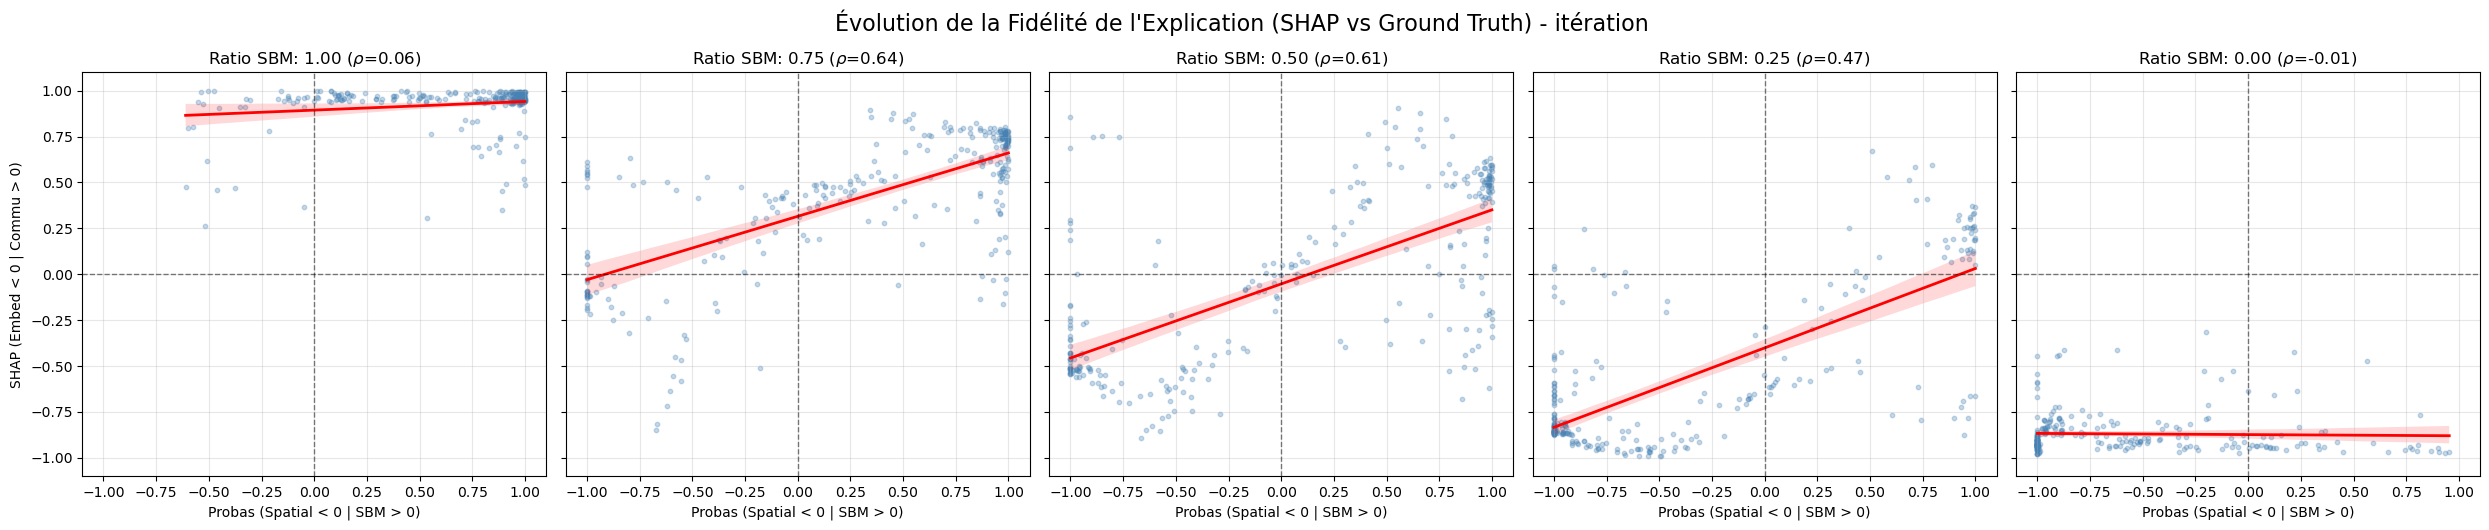

In [23]:
from scipy import stats

feature_mapping = {
        "Groupe_Structure": ['pr_u', 'pr_v','ppr_u', 'ppr_v', 'lcc_u', 'lcc_v', 'and_u', 'and_v', 'dc_u', 'dc_v', 'katz_u', 'katz_v',
                              'sp', 'jc', 'aa', 'cn','pa', 'ra'],
        "Groupe_Communities": ['louvain_density', 'same_louvain', 'infomap_density', 'same_infomap', 'sbm_density', 'same_sbm',
                            'leiden_density', 'same_leiden', "surprise_density", "same_surprise", 
                            "significance_density", "same_significance"],
        "Groupe_Embeddings": ["deepwalk_cos", "deepwalk_rank", "deepwalk_had_mean",  "deepwalk_had_std",
                        "n2v_homophily_cos", "n2v_homophily_rank", "n2v_homophily_had_mean",  "n2v_homophily_had_std",
                      "crosswalk_cos", "crosswalk_rank", "crosswalk_had_mean",  "crosswalk_had_std"]
}

feature_mapping = {
    "Groupe_Embeddings": ['GT_pos_dist', 'GT_spatial_deg_product'],
    "Groupe_Communities": ['GT_sbm_density', 'GT_sbm_deg_product']
}

#p_matrices = joblib.load("graph_library/artificial_graph_sbmv5_P_matrices.joblib")
correlations_recap = []
Mann_Whitney_recap = []
fig, axes = plt.subplots(1, 5, figsize=(25, 5), sharey=True)
plot_idx = 0

for j in [""] :
    for i in np.arange(1.00, -0.25, -0.25):
        sbm_val = f"{i:.2f}"
        pos_val = f"{1-i:.2f}"
        G_name = f"artificial_graph_sbmv4{j}_{sbm_val.replace('.', '_')}_pos_{pos_val.replace('.', '_')}_GT"
        G_name_reduced = f"artificial_graph_sbmv4{j}_{sbm_val.replace('.', '_')}_pos_{pos_val.replace('.', '_')}_reduced_GT"

        
        G, _, dataset_hidden, xgboost_data, shap_explainer, _ = gp.load_all_data_for_graph(G_name)
        #_, _, _, xgboost_data, shap_explainer, _ = gp.load_all_data_for_graph(G_name_reduced)

        p_matrices = joblib.load(f"graph_library/artificial_graph_sbmv4{j}_P_matrices.joblib")
    
        explainability_dataset = gput.build_explainability_dataset(shap_explainer, xgboost_data, dataset_hidden, feature_mapping, 
                                                                   p_matrices_origin =p_matrices, ratio_sbm=i)

    
        explainability_dataset["Dominance_probas_Index"] = (explainability_dataset["p_uv_sbm"]-explainability_dataset["p_uv_pos"]) / (explainability_dataset["p_uv_sbm"]+explainability_dataset["p_uv_pos"])
    
        print(explainability_dataset.head(2))
        if i == 0.25 :
            gput.plot_pyvis_eval_graph_map(explainability_dataset, G, G_name,  filename="logic_map.html")
        #gput.plot_dominance_distribution(explainability_dataset, title = f"Distribution de la Dominance (Spatial vs SBM) - ratio_sbm = {i}")
        if plot_idx < 5:
            plot_Dominance_Index_VS_probas(explainability_dataset, axes[plot_idx], i)
            plot_idx += 1
        
        # --- Test statistique Mann_Whitney entre "Dominance_probas_Index" & "Dominance_Index" ---
        Mann_Whitney = test_Mann_Whitney(explainability_dataset, silent=True)
        Mann_Whitney["ratio_sbm"] = i 
        Mann_Whitney_recap.append(Mann_Whitney)

        # --- Test statistique spearman entre "Dominance_probas_Index" & "Dominance_Index" ---
        s_corr, s_p = stats.kendalltau(explainability_dataset["Dominance_Index"], explainability_dataset["Dominance_probas_Index"])
    
        # --- Coefficients de Corrélation avec Dominance_idex ---
        row = {
            "ratio_sbm": i,
            "SHAP_Probas_Kendall": round(s_corr, 4),
            "SHAP_Probas_P_Value": s_p
        }
        colonnes_p = ["p_uv_sbm", "p_uv_pos", "p_uv_hyb"]
        groupes_shap = {"SHAP_Groupe_Communities": "Com",
                        "SHAP_Groupe_Embeddings": "Emb"
                        #"SHAP_Groupe_Structure": "Str"
                       }
    
        for full_name, short_name in groupes_shap.items():
            for p_col in colonnes_p:
                corr = explainability_dataset[full_name].corr(explainability_dataset[p_col], method = "kendall")
                suffix = p_col.split('_')[-1]
                col_name = f"{short_name}_{suffix}"
                row[col_name] = round(corr, 4)
    
        correlations_recap.append(row)

correlations_recap = pd.DataFrame(correlations_recap)

print("\n=== TABLEAU RÉCAPITULATIF DES CORRÉLATIONS de plusieurs itérations ===")
print(correlations_recap.to_string(index=False))

print("\n=== SYNTHÈSE DES CORRÉLATIONS (MOYENNE ET ÉCART-TYPE) ===")
stats = correlations_recap.groupby("ratio_sbm").agg(["mean", "std", "min", "max"])
final_table = pd.DataFrame(index=stats.index)

for col in stats.columns.levels[0]:
    if col == "ratio_sbm": continue
    final_table[col] = stats[col].apply(
        lambda x: f"{x['mean']:.3f} ({x['std']:.3f})", axis=1
    )

print(final_table.reset_index().to_string(index=False))

print("\n=== RÉCAPITULATIF STATISTIQUE (MANN-WHITNEY P-VALUE) ===")
Mann_Whitney_stats = pd.DataFrame(Mann_Whitney_recap)
p_val_summary = Mann_Whitney_stats.groupby("ratio_sbm")["p_val_test"].agg(["mean", "std", "min", "max"])
print(p_val_summary.applymap(lambda x: f"{x:.2e}").reset_index().to_string(index=False))

print("\n=== PLOTS GLOBAUX DES DOMINANCE INDEXES ===")
plt.tight_layout()
fig.suptitle(f"Évolution de la Fidélité de l'Explication (SHAP vs Ground Truth) - itération {j}", fontsize=16, y=1.05)
plt.savefig("outputs/plots/evolution_dominance_debiaisée_multi_ratio_v4_20260415.png", bbox_inches='tight')
plt.show()

### 2.5 - Explo spécifique pour Graphe réels, affichage graphe

In [3]:
def get_all_positive_shap_values(model, X_hidden, y_hidden):
    """
    Calcule les SHAP values pour TOUS les liens réels (target == 1).
    """
    X_links = X_hidden[y_hidden == 1]
    
    print(f"Calcul SHAP pour les {len(X_links)} liens réels...")
    explainer = shap.TreeExplainer(model.get_booster())
    shap_values = explainer(X_links)
    
    vals = shap_values.values
    if len(vals.shape) == 3: 
        vals = vals[:, :, 1]
        
    return pd.DataFrame(vals, columns=X_links.columns, index=X_links.index)

import pandas as pd
import networkx as nx
import plotly.graph_objects as go
import numpy as np
import shap
import json


import random

def generate_shap_html_report_spatial_clean(G, df_links, df_shap, features, sample_ratio=0.1, filename="airport_spatial_shap_3d.html"):
    pos_3d = {node_id: data.get('GT_pos', [0, 0, 0]) for node_id, data in G.nodes(data=True)}

    abs_shap = df_shap.abs()
    dominant_feat = abs_shap.idxmax(axis=1)
    max_s = abs_shap.max(axis=1)
    
    s_min, s_max = max_s.min(), max_s.max()
    norm_thick = 1 + 14 * ((max_s - s_min) / (s_max - s_min + 1e-9))
    
    feat_cols = {f: c for f, c in zip(features, ['#FF4B4B', '#1CBEFF', '#00E676', '#FFD600', '#AB63FA'])}
    fig = go.Figure()
    found_count = 0
    
    # --- Tracé des arrêtes avec échantillonnage ---
    for idx in df_links.index:
        # Filtre de densité : on ne garde que X% des liens aléatoirement
        if random.random() > sample_ratio:
            continue
            
        u, v = str(df_links.loc[idx, 'u']), str(df_links.loc[idx, 'v'])
        if u in pos_3d and v in pos_3d:
            f = dominant_feat.loc[idx]
            p1, p2 = pos_3d[u], pos_3d[v]
            
            fig.add_trace(go.Scatter3d(
                x=[p1[0], p2[0]], y=[p1[1], p2[1]], z=[p1[2], p2[2]],
                mode='lines', 
                line=dict(color=feat_cols[f], width=norm_thick.loc[idx]),
                hoverinfo='text', 
                text=f"Lien: {G.nodes[u].get('city_name', u)} - {G.nodes[v].get('city_name', v)}<br>Top: {f}<br>SHAP: {df_shap.loc[idx, f]:.4f}", 
                showlegend=False))
            found_count += 1

    # --- Noeuds (on garde tous les noeuds pour voir la forme de la Terre) ---
    nodes_list = list(G.nodes())
    coords = np.array([pos_3d[n] for n in nodes_list])
    fig.add_trace(go.Scatter3d(
        x=coords[:,0], y=coords[:,1], z=coords[:,2], mode='markers',
        marker=dict(size=2, color='#FFFFFF', opacity=0.5),
        text=[G.nodes[n].get('city_name', n) for n in nodes_list], 
        hoverinfo='text', name='Villes'))

    # --- Légende ---
    for f, c in feat_cols.items():
        fig.add_trace(go.Scatter3d(x=[None], y=[None], z=[None], mode='lines', 
                                  line=dict(color=c, width=6), name=f))

    fig.update_layout(
        title=f"SHAP Géographique (Échantillonnage {int(sample_ratio*100)}%)",
        template="plotly_dark", 
        margin=dict(l=0,r=0,b=0,t=40),
        scene=dict(xaxis_visible=False, yaxis_visible=False, zaxis_visible=False, aspectmode='data')
    )
    
    fig.write_html(filename)
    print(f"Visualisation épurée générée : {filename} ({found_count} liens affichés)")

In [16]:
 G_names_list = [
        "Airports",
        #"eu_airlines",
        #"faa_routes"
    ]

features_to_explore = ["GT_pos_dist", "louvain_density", "spatial_louvain_density"]
    
for iteration in range (0,4):
    for G_name in G_names_list : 
        G_name_bis = f"{G_name}_{iteration}"
        print("######################################")
        print(f"#### graph {G_name_bis} :  ####")
        print("######################################")

        dataset_train = gp.load_dataset(filename=f"dataset_train_{G_name_bis}")
        dataset_hidden = gp.load_dataset(filename=f"dataset_hidden_{G_name_bis}")

        best_params = {'n_estimators': 1000, 'learning_rate': 0.05,'max_depth': 5,'min_child_weight': 5,
            'subsample': 0.8,'colsample_bytree': 0.8,'reg_alpha': 0.1, 'reg_lambda': 1.0,
            'tree_method': 'hist','n_jobs': -1,'random_state': 42
        }
        
        results_test, model, X_train, y_train, X_test, y_test = gp.train_and_test_xgboost(dataset_train, features=features_to_explore, parameters=best_params)
        
        X_hidden = dataset_hidden[features_to_explore]
        y_hidden = dataset_hidden['target']
        
        results_hidden = gp.get_performance_metrics(model, X_hidden, y_hidden, "Hidden_")
        results_test_hidden = pd.concat([results_test, results_hidden], axis=1)
    
        print("\n RÉSULTATS")
        print(results_test_hidden.to_string(index=False))

        shap_explanation = gp.analyze_with_shap_tree(model, X_hidden, y_hidden)

        vals = shap_explanation.values
        if isinstance(vals, list):
            vals = vals[1]
    
        df_shap = pd.DataFrame(vals, columns=X_test.columns)
        mean_shap = df_shap.mean()
        mean_abs_shap = df_shap.abs().mean()
        
        summary = pd.DataFrame({
            'G_name': G_name,
            'feature': X_test.columns,
            'mean_shap': mean_shap.values,
            'mean_abs_shap': mean_abs_shap.values,
            'iteration': iteration
        })
        all_summaries.append(summary)

df_shapvals_concat = pd.concat(all_summaries)

######################################
#### graph Airports_0 :  ####
######################################

 RÉSULTATS
 Test_AP  Test_AUC-ROC  Test_F1-Score  Test_AUC-PR  Hidden_AP  Hidden_AUC-ROC  Hidden_F1-Score  Hidden_AUC-PR
0.822724      0.968802       0.779221     0.822294   0.405861        0.948247         0.455535       0.405247
Calcul TreeExplainer : 2710 échantillons au total.
######################################
#### graph Airports_1 :  ####
######################################

 RÉSULTATS
 Test_AP  Test_AUC-ROC  Test_F1-Score  Test_AUC-PR  Hidden_AP  Hidden_AUC-ROC  Hidden_F1-Score  Hidden_AUC-PR
0.778609      0.967905       0.732394     0.777602    0.38966        0.956838         0.435786       0.389073
Calcul TreeExplainer : 2710 échantillons au total.
######################################
#### graph Airports_2 :  ####
######################################

 RÉSULTATS
 Test_AP  Test_AUC-ROC  Test_F1-Score  Test_AUC-PR  Hidden_AP  Hidden_AUC-ROC  Hidden_F1-Score  Hi

KeyError: 'source'

In [5]:
# --- PLOT DU GRAPHE ---
G_Airports = gp.loadsave_data_joblib(data=None, filename="G_kept_w_struct_com_dist_Airports_0", mode="load", talk=False)
if 'GroundTruth_JSON' in G_Airports.graph:
    print(f"[INIT] Extraction de la GT GroundTruth pour {G_name}...")
    gt_raw = json.loads(G_Airports.graph['GroundTruth_JSON'])
    raw_pos = gt_raw.get('GT_pos', [])
    gt_pos_array = np.array(raw_pos, dtype=float)

    GT = {'GT_pos': gt_pos_array}
else:
    print("[WARNING] Aucune GroundTruth_JSON trouvée dans G.graph")
    GT = None

if GT is not None and 'GT_pos' in GT:
    for i, node_id in enumerate(G_Airports.nodes()):
        G_Airports.nodes[node_id]['GT_pos'] = GT['GT_pos'][i]

dataset_hidden = gp.load_dataset(filename=f"dataset_hidden_Airports_0")
dataset_train = gp.load_dataset(filename=f"dataset_train_Airports_0")
full_dataset = pd.concat([dataset_train, dataset_hidden], axis=0).reset_index(drop=True)
results_test, model, X_train, y_train, X_test, y_test = gp.train_and_test_xgboost(full_dataset, features=features_to_explore, parameters=best_params)

df_full = gp.prepare_balanced_data(G_Airports, G_Airports, negative_ratio=0.0, GroundTruth=GT)
df_links = df_full[df_full['target'] == 1].copy()

explainer = shap.TreeExplainer(model.get_booster())
shap_vals = explainer(df_links[features_to_explore]).values
if len(shap_vals.shape) == 3: shap_vals = shap_vals[:, :, 1]
df_shap = pd.DataFrame(shap_vals, columns=features_to_explore, index=df_links.index)

generate_shap_html_report(G_real, df_links, df_shap, features_to_explore)

FileNotFoundError: Fichier introuvable : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/G_kept_w_struct_com_dist_Airports_0

In [43]:
generate_shap_html_report_spatial(G_Airports, df_links, df_shap, features_to_explore)

Globe SHAP généré : airport_spatial_shap_3d.html (12192 liens)


In [6]:
generate_shap_html_report_spatial_clean(G_Airports, df_links, df_shap, features_to_explore, sample_ratio=1.0)

NameError: name 'G_Airports' is not defined

## 3 - Exploration des features et groupes de features

### 3.1 - Correlation des features entre elles

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform

RRRRRRRRRRRRATIO i : 0
Features ac 1 unique valeur pour rati_sbm=0.00 :    sbm_density  same_sbm
0     0.023002         1
Graphique sauvegardé : outputs/plots/correlation_clustermap_sbm_0_00.png


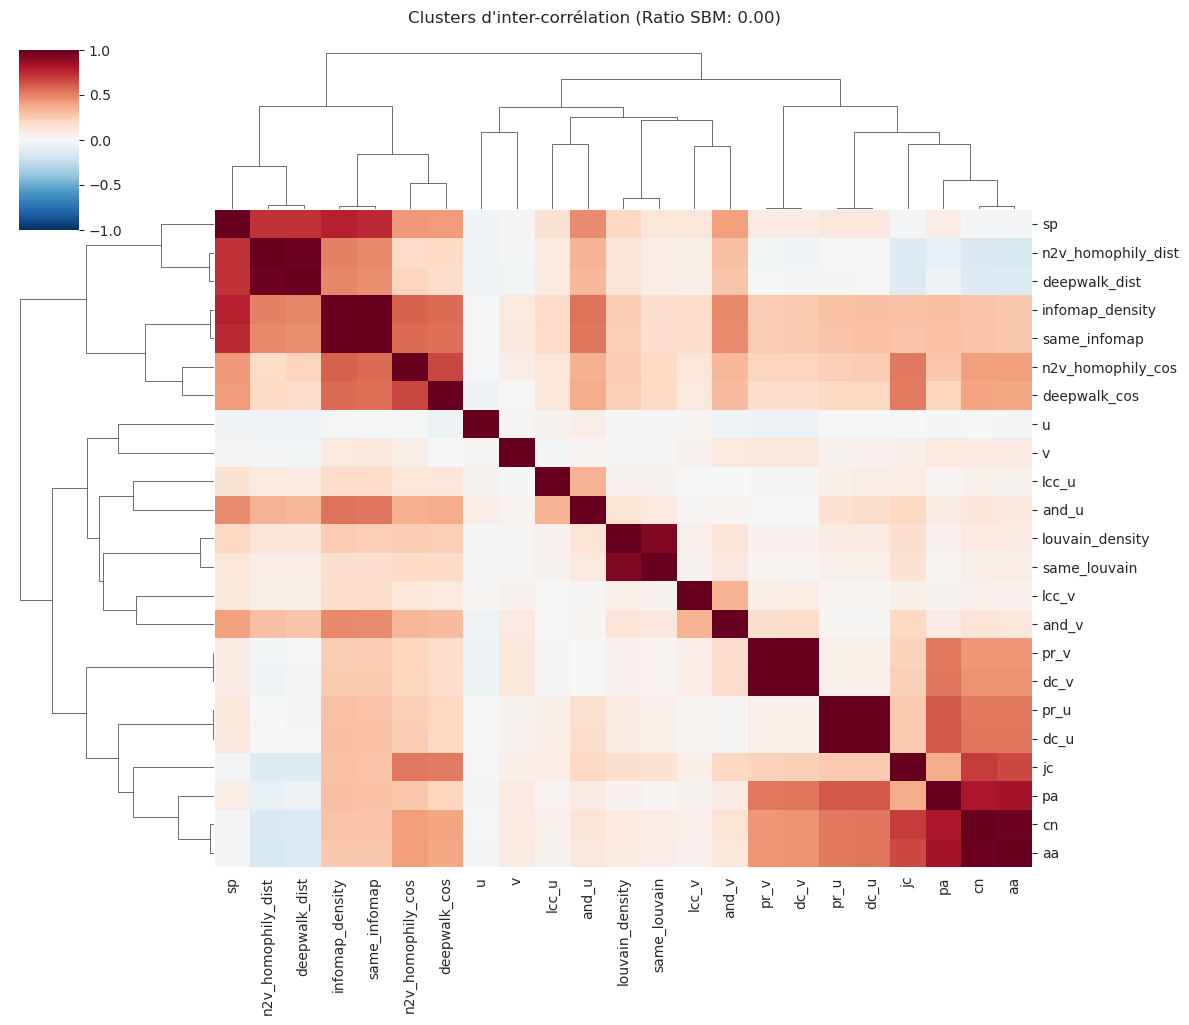

NameError: name 'hierarchy' is not defined

<Figure size 1000x500 with 0 Axes>

In [67]:
# On garde tes groupes pour l'analyse
group_mapping = {
    "Groupe_Structure": ['cn', 'aa', 'jc', 'pa', 'sp', 'pr_u', 'pr_v', 'lcc_u', 'lcc_v', 'and_u', 'and_v', 'dc_u', 'dc_v'],
    "Groupe_Communities": ['sbm_density', 'same_sbm', 'infomap_density', 'same_infomap',"louvain_density", "same_louvain"],
    "Groupe_Embeddings": ['n2v_homophily_cos', 'n2v_homophily_dist', 'deepwalk_cos', 'deepwalk_dist']
}

output_folder = "outputs/plots"
os.makedirs(output_folder, exist_ok=True)

ratios = [0, 0.25, 0.50, 0.75, 1.00]
for i in ratios:
    print(f"RRRRRRRRRRRRATIO i : {i}")
    sbm_val_str = f"{i:.2f}"
    pos_val_str = f"{1-i:.2f}"
    G_name = f"artificial_graph_sbmv2_{sbm_val_str.replace('.', '_')}_pos_{pos_val_str.replace('.', '_')}"
    
    _, dataset_train, _, _, _, _ = gp.load_all_data_for_graph(G_name)    
    features = [c for c in dataset_train.columns if c != 'target']
    df_features = dataset_train[features]

    print(f"Features ac 1 unique valeur pour rati_sbm={sbm_val_str} : {df_features.loc[:, df_features.nunique() <= 1].head(1)}")
    df_features = df_features.loc[:, df_features.nunique() > 1]

    # --- CALCUL DE LA MATRICE DE CORRÉLATION ---
    corr_matrix = df_features.corr(method='pearson')
    
    # --- PLOT 1 : CLUSTERMAP (La vue d'ensemble) ---
    # Combine la heatmap et le dendrogramme
    g = sns.clustermap(corr_matrix, 
                       method='complete', 
                       cmap='RdBu_r', 
                       vmin=-1, vmax=1,
                       figsize=(12, 10))
    g.fig.suptitle(f"Clusters d'inter-corrélation (Ratio SBM: {sbm_val_str})", y=1.02)
    
    save_path = os.path.join(output_folder, f"correlation_clustermap_sbm_{sbm_val_str.replace('.', '_')}.png")
    plt.savefig(save_path, bbox_inches='tight', dpi=300)
    print(f"Graphique sauvegardé : {save_path}")

    plt.show()

    # --- PLOT 2 : DENDROGRAMME PUR (Focus structure) ---
    plt.figure(figsize=(10, 5))
    features_clean = df_features.columns.tolist()
    # Distance = 1 - valeur absolue de la corrélation
    dissimilarity = 1 - np.abs(corr_matrix)
    # Linkage sur la matrice de corrélation nettoyée
    Z = hierarchy.linkage(squareform(dissimilarity, checks=False), method='complete')
    
    hierarchy.dendrogram(Z, labels=features_clean, leaf_rotation=90, color_threshold=0.3)
    plt.axhline(y=0.3, color='r', linestyle='--', label='Seuil de forte corrélation (0.7)')
    plt.title(f"Hiérarchie des variables (Ratio SBM: {sbm_val_str})")
    plt.ylabel("Dissimilarité (1 - |corr|)")
    plt.legend()
    plt.tight_layout()
    plt.show()

### 3.2 - Exploration gu Gain  de chaque feature 

In [78]:
# --- 1. GÉNÉRATION DES DICTIONNAIRES D'IMPORTANCE ---
rank_dfs = {}

for i in [1.0, 0.75, 0.5, 0.25, 0.0]:
    sbm_val = f"{i:.2f}"
    pos_val = f"{1-i:.2f}"
    ratio_label = f"Ratio_SBM_{sbm_val}"
    G_name = f"artificial_graph_sbmv4_{sbm_val.replace('.', '_')}_pos_{pos_val.replace('.', '_')}"
    
    _, _, _, xgboost_data, _, _ = gp.load_all_data_for_graph(G_name)
    model = xgboost_data['model']
    
    # Gain du booster
    importance_gain = model.get_booster().get_score(importance_type='gain')
    
    # Création du DF
    df = pd.DataFrame(list(importance_gain.items()), columns=['Feature', 'Gain'])
    df = df.sort_values(by='Gain', ascending=False).reset_index(drop=True)
    
    # Calcul Rang et Poids
    df['Rank'] = df.index + 1
    df['Weight_pct'] = (df['Gain'] / df['Gain'].sum()) * 100
    
    rank_dfs[ratio_label] = df
    print(f"{ratio_label} chargé.")


if "Ratio_SBM_1.00" in rank_dfs and "Ratio_SBM_0.00" in rank_dfs:
    # 1. Préparation des données sources
    df_sbm = rank_dfs["Ratio_SBM_1.00"].copy()
    df_spa = rank_dfs["Ratio_SBM_0.00"].copy()
    
    # 2. Merge avec renommage propre
    comparison = pd.merge(
        df_sbm[['Feature', 'Rank', 'Weight_pct']], 
        df_spa[['Feature', 'Rank', 'Weight_pct']], 
        on='Feature', 
        suffixes=('_SBM', '_Spatial'), 
        how='outer'
    )
    
    # 3. Nettoyage des valeurs manquantes
    comparison['Weight_pct_SBM'] = comparison['Weight_pct_SBM'].fillna(0.0)
    comparison['Weight_pct_Spatial'] = comparison['Weight_pct_Spatial'].fillna(0.0)
    comparison['Rank_SBM'] = comparison['Rank_SBM'].fillna(99).astype(int)
    comparison['Rank_Spatial'] = comparison['Rank_Spatial'].fillna(99).astype(int)
    
    # 4. Calcul des colonnes de tri et d'analyse
    comparison['Sum_Weight'] = comparison['Weight_pct_SBM'] + comparison['Weight_pct_Spatial']
    comparison['Weight_Delta'] = comparison['Weight_pct_SBM'] - comparison['Weight_pct_Spatial']
    
    # 5. Filtrage : au moins 0.5% dans l'un des deux mondes
    mask = (comparison['Weight_pct_SBM'] >= 0.5) | (comparison['Weight_pct_Spatial'] >= 0.5)
    final_table = comparison[mask].copy()
    
    # 6. Tri par importance cumulée
    final_table = final_table.sort_values(by='Sum_Weight', ascending=False)
    
    # Affichage final
    pd.options.display.float_format = '{:.2f}'.format
    cols_to_print = [
        'Feature', 
        'Weight_pct_SBM', 'Rank_SBM', 
        'Weight_pct_Spatial', 'Rank_Spatial', 
        'Weight_Delta', 'Sum_Weight'
    ]
    
    print("Tableau des Features Significatives (Seuil > 0.5%)")
    print("-" * 100)
    print(final_table[cols_to_print].to_string(index=False))

SHAP Analysis introuvable pour artificial_graph_sbmv4_1_00_pos_0_00.
Ratio_SBM_1.00 chargé.
SHAP Analysis introuvable pour artificial_graph_sbmv4_0_75_pos_0_25.
Ratio_SBM_0.75 chargé.
SHAP Analysis introuvable pour artificial_graph_sbmv4_0_50_pos_0_50.
Ratio_SBM_0.50 chargé.
SHAP Analysis introuvable pour artificial_graph_sbmv4_0_25_pos_0_75.
Ratio_SBM_0.25 chargé.
SHAP Analysis introuvable pour artificial_graph_sbmv4_0_00_pos_1_00.
Ratio_SBM_0.00 chargé.
Tableau des Features Significatives (Seuil > 0.5%)
----------------------------------------------------------------------------------------------------
               Feature  Weight_pct_SBM  Rank_SBM  Weight_pct_Spatial  Rank_Spatial  Weight_Delta  Sum_Weight
     same_significance           12.15         1                6.88             6          5.27       19.02
                    jc            9.18         2                8.56             3          0.62       17.74
  significance_density            5.81         5             

### 3.3 - Exploration corrélation inter-features via Kendall

SHAP Analysis introuvable pour artificial_graph_sbmv4_1_00_pos_0_00.


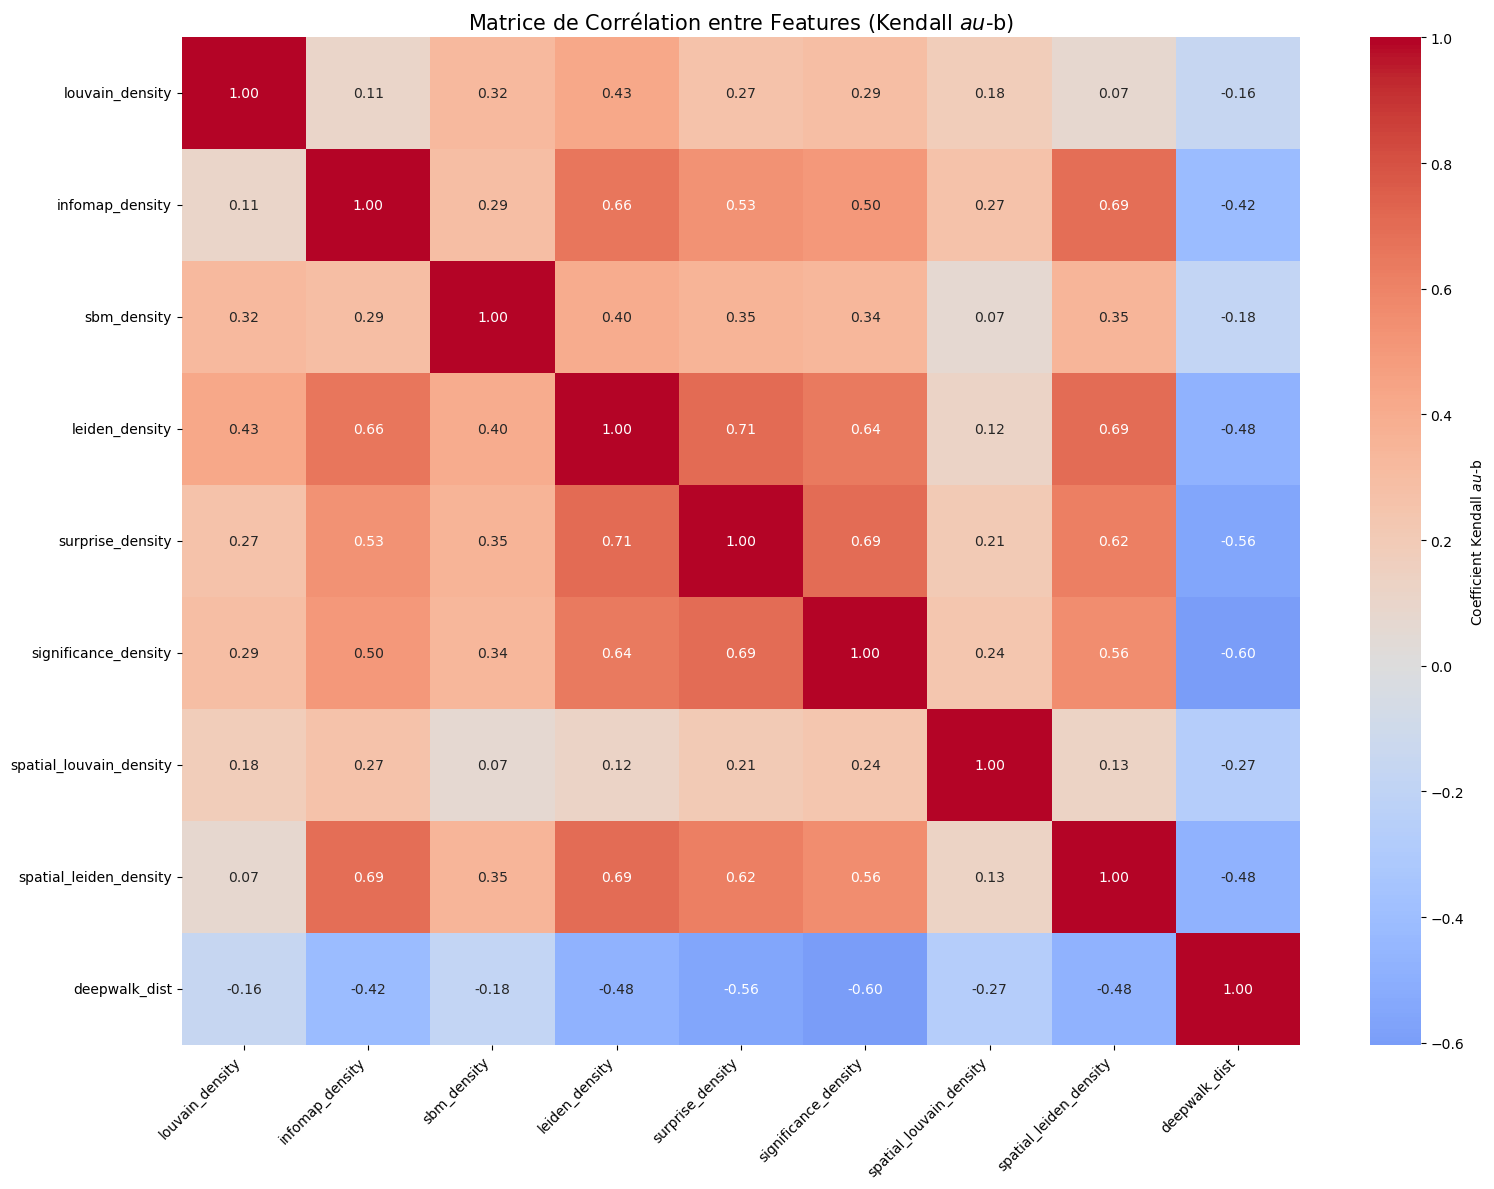

                         louvain_density  infomap_density  sbm_density  \
louvain_density                 1.000000         0.109383     0.318951   
infomap_density                 0.109383         1.000000     0.292402   
sbm_density                     0.318951         0.292402     1.000000   
leiden_density                  0.425807         0.659796     0.402855   
surprise_density                0.265606         0.532697     0.349590   
significance_density            0.292213         0.502481     0.336569   
spatial_louvain_density         0.184022         0.266841     0.066006   
spatial_leiden_density          0.073260         0.689122     0.346626   
deepwalk_dist                  -0.162942        -0.416099    -0.178445   

                         leiden_density  surprise_density  \
louvain_density                0.425807          0.265606   
infomap_density                0.659796          0.532697   
sbm_density                    0.402855          0.349590   
leiden_density 

In [35]:
from scipy import stats

feature_mapping = {
        "Groupe_Structure": ['pr_u', 'pr_v','ppr_u', 'ppr_v', 'lcc_u', 'lcc_v', 'and_u', 'and_v', 'dc_u', 'dc_v', 'katz_u', 'katz_v',
                              'sp', 'jc', 'aa', 'cn','pa', 'ra'],
        "Groupe_Communities": ['louvain_density', 'infomap_density', 'sbm_density', 'leiden_density', "surprise_density", "significance_density",
                               'same_louvain', 'same_infomap', 'same_sbm','same_leiden', "same_surprise", "same_significance"],
        "Groupe_Embeddings": ["deepwalk_cos", "n2v_homophily_cos", "crosswalk_cos",
                              "deepwalk_rank",  "n2v_homophily_rank", "crosswalk_rank", 
                              "deepwalk_had_mean", "n2v_homophily_had_mean", "crosswalk_had_mean",
                              "deepwalk_had_std",  "n2v_homophily_had_std","crosswalk_had_std", 
                              'deepwalk_dist','n2v_homophily_dist','crosswalk_dist'],
        "Groupe_stars": ['louvain_density', 'infomap_density', 'sbm_density', 'leiden_density', "surprise_density", "significance_density",
                         'spatial_louvain_density', 'spatial_leiden_density',
                         'deepwalk_dist']
}

for i in np.arange(1.00, 0.75, -0.25):
    sbm_val = f"{i:.2f}"
    pos_val = f"{1-i:.2f}"
    G_name = f"artificial_graph_sbmv4_{sbm_val.replace('.', '_')}_pos_{pos_val.replace('.', '_')}"

    G, dataset_train, _, _, _, _ = gp.load_all_data_for_graph(G_name)  
    #features = [c for c in dataset_train.columns if c != 'target']
    features = feature_mapping["Groupe_stars"]

    corr_matrix = dataset_train[features].corr(method="kendall")

    plt.figure(figsize=(16, 12))
    sns.heatmap(corr_matrix, annot=True, fmt=".2f",cmap='coolwarm',center=0,cbar_kws={'label': 'Coefficient Kendall $\tau$-b'})
    plt.title("Matrice de Corrélation entre Features (Kendall $\tau$-b)", fontsize=15)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    print (corr_matrix)

### 3.4 - Information mutuelle étude

In [192]:
from sklearn.feature_selection import mutual_info_regression

def compute_mi_matrix(df, features, categorical = True, normalized = False):
    n = len(features)
    mi_matrix = pd.DataFrame(np.zeros((n, n)), index=features, columns=features)
    
    for i in range(n):
        for j in range(i, n):
            f1, f2 = features[i], features[j]

            if categorical : 
                #val = normalized_mutual_info_score(df[f1], df[f2], average_method='arithmetic')
                val = adjusted_mutual_info_score(df[f1], df[f2])
            else : 
                val = mutual_info_regression(df[[f1]], df[f2])[0] # PB D'ID UNIK SI ON AJOUTE PRODUIT D DEGRES.

                if normalized : 
                    h_x = mutual_info_regression(df[[f1]], df[f1], random_state=42)[0]
                    h_y = mutual_info_regression(df[[f2]], df[f2], random_state=42)[0]
                    denom = min(h_x, h_y)
                
                    val = val / denom
                
            
            mi_matrix.loc[f1, f2] = val
            mi_matrix.loc[f2, f1] = val # Symetry, si i == j on écrase et c pa grav
            
    return mi_matrix

def get_unique_information(dataset, all_features, features_GT):
    # Calcul de I(X,GT|Autres) 
    unique_info_results = []
    
    series_GT = dataset[features_GT].astype(str).agg('-'.join, axis=1)
    series_ALL = dataset[all_features].astype(str).agg('-'.join, axis=1)
    mi_all_gt = mutual_info_score(series_ALL, series_GT)
    
    for feature in all_features:
        others = [f for f in all_features if f != feature]
        series_others = dataset[others].astype(str).agg('-'.join, axis=1)
        
        # I(Autres ; GT)
        mi_others_gt = mutual_info_score(series_others, series_GT)
        
        unique_info = max(0, mi_all_gt - mi_others_gt)
        unique_pct = (unique_info / mi_all_gt) * 100 if mi_all_gt > 0 else 0
        
        unique_info_results.append({
            "Feature": feature,
            "Unique Info (nats)": unique_info,
            "Contribution Unique (%)": unique_pct
        })
        
    return pd.DataFrame(unique_info_results).sort_values("Unique Info (nats)", ascending=False)

def bining_features_dataset(dataset, features, n_bins) :
    df_binned = dataset.copy()
    
    for col in features:
        # On binne chaque feature en quantiles (même nombre de points par bin)
        # On gère les duplicates au cas où une valeur (ex: 0) est ultra majoritaire
        try:
            df_binned[col] = pd.qcut(dataset_train[col], n_bins, labels=False, duplicates='drop')
        except Exception:
            # Si vraiment pas assez de valeurs distinctes pour faire des bins
            df_binned[col] = dataset_train[col]

    return df_binned


def get_joint_series(dataset, feature_list):
    """Combine plusieurs colonnes en une seule variable de partitions."""
    if not feature_list:
        return pd.Series(['0'] * len(dataset))
    return dataset[feature_list].astype(str).agg('-'.join, axis=1)

def get_entropy(series):
    p_data = series.value_counts(normalize=True)
    return entropy(p_data)

def get_cmi_score(dataset, X_features, Y_features, GT_features, divideByEntropyOfYknowingX = True):
    """
    Calcule l'Information Mutuelle Conditionnelle I(Y ; GT | X)
    Basée sur la règle de la chaîne : I(Y;GT|X) = I(X,Y;GT) - I(X;GT)
    """
    series_X = get_joint_series(dataset, X_features)
    series_XY = get_joint_series(dataset, X_features + Y_features)
    series_GT = get_joint_series(dataset, GT_features)
    
    i_xy_gt = mutual_info_score(series_XY, series_GT)
    i_x_gt = mutual_info_score(series_X, series_GT)
    cmi = max (0.0, i_xy_gt - i_x_gt)

    # Calcul de H(Y | X) = H(X, Y) - H(X)
    h_x = get_entropy(series_X)
    h_xy = get_entropy(series_XY)
    h_y_knowing_x = max(1e-9, h_xy - h_x) 

    if divideByEntropyOfYknowingX : 
        cmi = cmi / h_y_knowing_x
    
    return cmi

def get_coverage_ratio(dataset, feature_list, features_GT):
    """
    Calcule = I(Features ; GT) / H(GT)
    """
    series_X = dataset[feature_list].astype(str).agg('-'.join, axis=1)
    series_GT = dataset[features_GT].astype(str).agg('-'.join, axis=1)
    
    mi_score = mutual_info_score(series_X, series_GT)

    p_gt = series_GT.value_counts(normalize=True)
    h_gt = entropy(p_gt)
    coverage = (mi_score / h_gt)
    
    return min(1.0, coverage)

def get_nmi_for_group(df, feature_list, target_features):
    joint_X = df[feature_list].astype(str).agg('-'.join, axis=1)
    joint_Y = df[target_features].astype(str).agg('-'.join, axis=1)
  
    return adjusted_mutual_info_score(joint_X, joint_Y, average_method='min')


feature_mapping = {
        "Groupe_Structure": ['pr_u', 'pr_v','ppr_u', 'ppr_v', 'lcc_u', 'lcc_v', 'and_u', 'and_v', 'dc_u', 'dc_v', 'katz_u', 'katz_v',
                              'sp', 'jc', 'aa', 'cn','pa', 'ra'],
        "Groupe_Communities": ['louvain_density', 'infomap_density', 'sbm_density', 'leiden_density', "surprise_density", "significance_density",
                               #'same_louvain', 'same_infomap', 'same_sbm','same_leiden', "same_surprise", "same_significance"
                              ],
        "Groupe_Embeddings": ["deepwalk_cos", "n2v_homophily_cos", "crosswalk_cos",
                              "deepwalk_rank",  "n2v_homophily_rank", "crosswalk_rank", 
                              "deepwalk_had_mean", "n2v_homophily_had_mean", "crosswalk_had_mean",
                              "deepwalk_had_std",  "n2v_homophily_had_std","crosswalk_had_std", 
                              'deepwalk_dist','n2v_homophily_dist','crosswalk_dist'],
        "GT_sbm" : ['GT_sbm_density', 'GT_spatial_deg_product']
}

In [194]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.metrics.cluster._supervised")

for i in np.arange(1.00, 0.75, -0.25):
    sbm_val = f"{i:.2f}"
    pos_val = f"{1-i:.2f}"
    G_name = f"artificial_graph_sbm4_{sbm_val.replace('.', '_')}_pos_{pos_val.replace('.', '_')}_GT"

    _, dataset_train, _, _, _, _ = gp.load_all_data_for_graph(G_name)

    features = feature_mapping["Groupe_Communities"] + feature_mapping["GT_sbm"]
    features_GT = feature_mapping["GT_sbm"]
    
    # Bining de toutes les features
    dataset_train = bining_features_dataset(dataset_train, features, 13)
    
    mi_matrix_categorical = compute_mi_matrix(dataset_train, features)
    mi_matrix_continuous = compute_mi_matrix(dataset_train, features, categorical=False, normalized=False)

    """
    plt.figure(figsize=(16, 12))
    sns.heatmap(mi_matrix_categorical, annot=True, fmt=".2f",cmap='coolwarm',center=0,cbar_kws={'label': 'Coefficient Kendall $\tau$-b'})
    plt.title("Matrice des Mutal Information entre paires des Features", fontsize=15)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    """

    current_best_features = ["surprise_density", "sbm_density", "significance_density"]
    all_features = ["infomap_density", "louvain_density", "leiden_density", "sbm_density", "surprise_density", "significance_density"]

    baseline_coverage_ratio = get_coverage_ratio(dataset_train, current_best_features, features_GT)
    best_coverage_ratio = get_coverage_ratio(dataset_train, all_features, features_GT)
    candidates = [f for f in all_features if f not in current_best_features]
    extension_results = []
    
    for candidate in candidates:
        #cmi_score_divided_by_hy_knowing_x = get_cmi_score(dataset_train, current_best_features, [candidate], features_GT)
        cmi_score = get_cmi_score(dataset_train, current_best_features, [candidate], features_GT, divideByEntropyOfYknowingX = False)

        coverage_ratio = get_coverage_ratio(dataset_train, current_best_features + [candidate], features_GT)
        
        extension_results.append({
            "Variable testée": candidate,
            "Cmi Score": cmi_score,
            "Coverage_ratio" : coverage_ratio,
            "Coverage_ratio/best_possible" : coverage_ratio/best_coverage_ratio
        })
    
    print(f"Score de base avec {current_best_features} : {baseline_coverage_ratio:.4f}\n, soit {baseline_coverage_ratio/best_coverage_ratio:.2f} du best possible, aka {best_coverage_ratio:.2f}")
    df_ext = pd.DataFrame(extension_results).sort_values("Cmi Score", ascending=False)
    print(df_ext)

    unique_info = get_unique_information(dataset_train, all_features, features_GT)
    print(unique_info)
    


SHAP Analysis introuvable pour artificial_graph_sbmv5_1_00_pos_0_00_GT.
Score de base avec ['surprise_density', 'sbm_density', 'significance_density'] : 0.3619
, soit 0.76 du best possible, aka 0.48
   Variable testée  Cmi Score  Coverage_ratio  Coverage_ratio/best_possible
2   leiden_density   0.434163        0.458842                      0.963437
1  louvain_density   0.235475        0.414461                      0.870249
0  infomap_density   0.200772        0.406709                      0.853973
                Feature  Unique Info (nats)  Contribution Unique (%)
5  significance_density            0.480216                22.522789
4      surprise_density            0.412733                19.357730
3           sbm_density            0.311750                14.621505
2        leiden_density            0.170063                 7.976200
0       infomap_density            0.077957                 3.656298
1       louvain_density            0.000000                 0.000000


### 3.5 - MI(X,GT)/H(X) entre features et GT

In [14]:
def calculate_entropy(labels):
    """Calcule l'entropie H(X) en bits."""
    prob_dist = pd.Series(labels).value_counts(normalize=True)
    return -(prob_dist * np.log2(prob_dist)).sum()

def get_adjusted_mi(feature, target):
    """Calcule l'AMI qui gère la normalisation par une comparaison et correction du hasard"""
    # L'AMI s'attend à des variables discrètes (int ou str)
    return adjusted_mutual_info_score(feature, target)

def get_normalized_mi(feature, target):
    """Calcule le ratio I(X; GT) / H(X)."""
    # mutual_info_score utilise le log naturel par défaut, on convertit en bits (log2)
    mi = mutual_info_score(feature, target) / np.log(2)
    h_x = calculate_entropy(feature)
    return mi / h_x if h_x > 1e-9 else 0

features_to_test = ["louvain_density", "spatial_louvain_density"]

all_results = []

for nbiter in range (1,31): 
    for i in np.arange(1.00, -0.10, -0.10):
        sbm_val = f"{i:.2f}"
        pos_val = f"{1-i:.2f}"
        G_name = f"artificial_graph_sbmv_4_comuAndEmb_{sbm_val.replace('.', '_')}_pos_{pos_val.replace('.', '_')}_{nbiter}"
    
        #_, dataset_train, _, _, _, _ = gp.load_all_data_for_graph(G_name)
        dataset_train = gp.load_dataset(filename=f"dataset_train_{G_name}", talk=False)
        if round(i, 2) == 0.50 :
            print(f"Dataset récupéré pour {G_name}")
        
        gt_sbm = dataset_train['GT_sbm_density'].round(5).astype(str)
        # Binning Logarithmique pour la distance
        bins_log = np.logspace(np.log10(dataset_train['GT_pos_dist'].min() + 1e-9), 
                               np.log10(dataset_train['GT_pos_dist'].max()), 
                               num=21)
        bins_log[0] = -np.inf 
        bins_log[-1] = np.inf #On évite les "hors bins"
        
        gt_pos = pd.cut(dataset_train['GT_pos_dist'], bins=bins_log, labels=False, include_lowest=True)
    
        for feat in features_to_test:
            #Pour éviter que la MI voit des valeurs différentes si écart minime de précision du float
            feat_vector = dataset_train[feat].round(5).astype(str)
            
            #mi_sbm_ratio = get_normalized_mi(feat_vector, gt_sbm)
            #mi_pos_ratio = get_normalized_mi(feat_vector, gt_pos)
            mi_sbm_ratio = get_adjusted_mi(feat_vector, gt_sbm)
            mi_pos_ratio = get_adjusted_mi(feat_vector, gt_pos)
            entropie_feature = calculate_entropy(feat_vector)
            
            all_results.append({
                'iter': nbiter,
                'ratio_sbm': i,
                'feature': feat,
                'mi_ratio_sbm': mi_sbm_ratio,
                'mi_ratio_pos': mi_pos_ratio,
                'entropie_feature': entropie_feature
            })

df_res = pd.DataFrame(all_results)

KeyError: 'GT_sbm_density'

Graphique sauvegardé dans : outputs/plots/MI_X_GT_by_H_X_smbv4_30iter_GT_pos_inferences_louvain.png


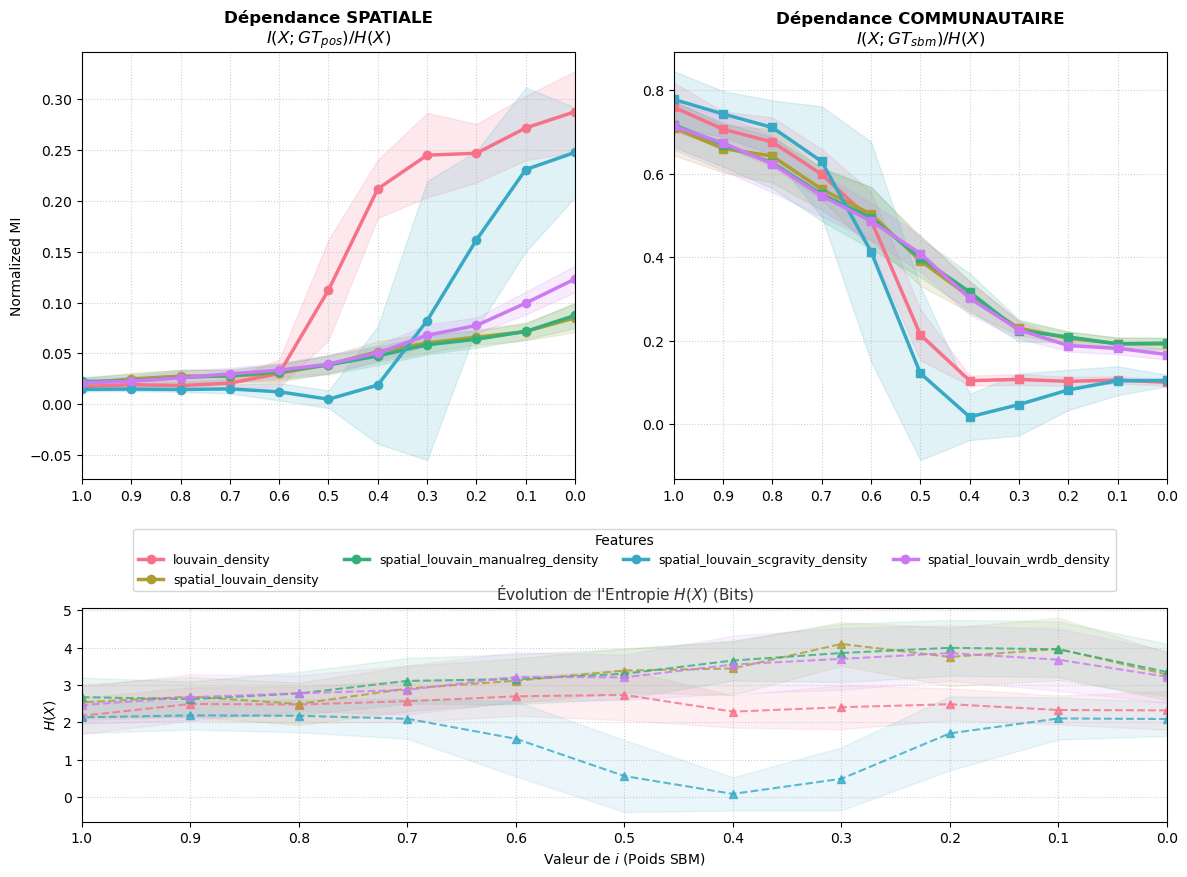

In [149]:
stats = df_res.groupby(['feature', 'ratio_sbm']).agg({
    'mi_ratio_pos': ['mean', 'std'],
    'mi_ratio_sbm': ['mean', 'std'],
    'entropie_feature': ['mean', 'std']
}).reset_index()

# On aplatit les colonnes multi-index pour faciliter l'accès
stats.columns = ['feature', 'ratio_sbm', 
                 'mi_ratio_pos_mean', 'mi_ratio_pos_std', 
                 'mi_ratio_sbm_mean', 'mi_ratio_sbm_std', 
                 'entropie_mean', 'entropie_std']

features = stats['feature'].unique()
i_values = sorted(stats['ratio_sbm'].unique(), reverse=True)
colors = sns.color_palette("husl", len(features))

fig = plt.figure(figsize=(14, 10))
gs = gridspec.GridSpec(2, 2, height_ratios=[2, 1])

ax1 = fig.add_subplot(gs[0, 0]) # MI Pos (Haut Gauche)
ax2 = fig.add_subplot(gs[0, 1]) # MI SBM (Haut Droite)
ax3 = fig.add_subplot(gs[1, :]) # Entropie (Bas, toute la largeur)

# 3. Plotting
for feat, color in zip(features, colors):
    subset = stats[stats['feature'] == feat]
    ax1.plot(subset['ratio_sbm'], subset['mi_ratio_pos_mean'], label=feat, marker='o', color=color, linewidth=2.5)
    ax1.fill_between(subset['ratio_sbm'], subset['mi_ratio_pos_mean'] - subset['mi_ratio_pos_std'], subset['mi_ratio_pos_mean'] + subset['mi_ratio_pos_std'], color=color, alpha=0.15)
    ax2.plot(subset['ratio_sbm'], subset['mi_ratio_sbm_mean'], label=feat, marker='s', color=color, linewidth=2.5)
    ax2.fill_between(subset['ratio_sbm'], subset['mi_ratio_sbm_mean'] - subset['mi_ratio_sbm_std'], subset['mi_ratio_sbm_mean'] + subset['mi_ratio_sbm_std'], color=color, alpha=0.15)
    ax3.plot(subset['ratio_sbm'], subset['entropie_mean'], label=feat, marker='^', linestyle='--', color=color, alpha=0.8)
    ax3.fill_between(subset['ratio_sbm'], subset['entropie_mean'] - subset['entropie_std'], subset['entropie_mean'] + subset['entropie_std'], color=color, alpha=0.1)

# --- Formatage AX1 & AX2 ---
ax1.set_title("Dépendance SPATIALE\n$I(X; GT_{pos}) / H(X)$", fontsize=12, fontweight='bold')
ax2.set_title("Dépendance COMMUNAUTAIRE\n$I(X; GT_{sbm}) / H(X)$", fontsize=12, fontweight='bold')
ax1.set_ylabel("Normalized MI")

# --- Formatage AX3 ---
ax3.set_title("Évolution de l'Entropie $H(X)$ (Bits)", fontsize=11, alpha=0.8)
ax3.set_xlabel("Valeur de $i$ (Poids SBM)")
ax3.set_ylabel("$H(X)$")

# Configuration commune des axes
for ax in [ax1, ax2, ax3]:
    ax.set_xticks(i_values)
    ax.set_xticklabels([f"{v:.1f}" for v in i_values])
    ax.set_xlim(max(i_values), min(i_values))
    ax.grid(True, linestyle=':', alpha=0.6)

# --- Positionnement de la légende ---
ax1.legend(loc='upper center', bbox_to_anchor=(1.1, -0.1), ncol=4, fontsize=9, frameon=True, title="Features")

plt.subplots_adjust(hspace=0.4, wspace=0.2)

output_path = "outputs/plots"
#save_name = os.path.join(output_path, "MI_X_GT_by_H_X_smbv4_30iter_GT_pos_inferences_louvain.png")
save_name = os.path.join(output_path, "MI_adjusted_X_GT_smbv4_30iter_GT_pos_inferences_louvain.png")
plt.savefig(save_name, dpi=300, bbox_inches='tight')
print(f"Graphique sauvegardé dans : {save_name}")

plt.show()

Traitement de : Airports
Traitement de : fullerene_structures_C1500
Traitement de : urban_streets_savannah
Traitement de : urban_streets_seoul
Traitement de : urban_streets_washington
Traitement de : facebook_organizations_S1
Traitement de : facebook_organizations_S2
Graphique sauvegardé dans : outputs/plots/MI_adjusted_X_GT_G_reels.png


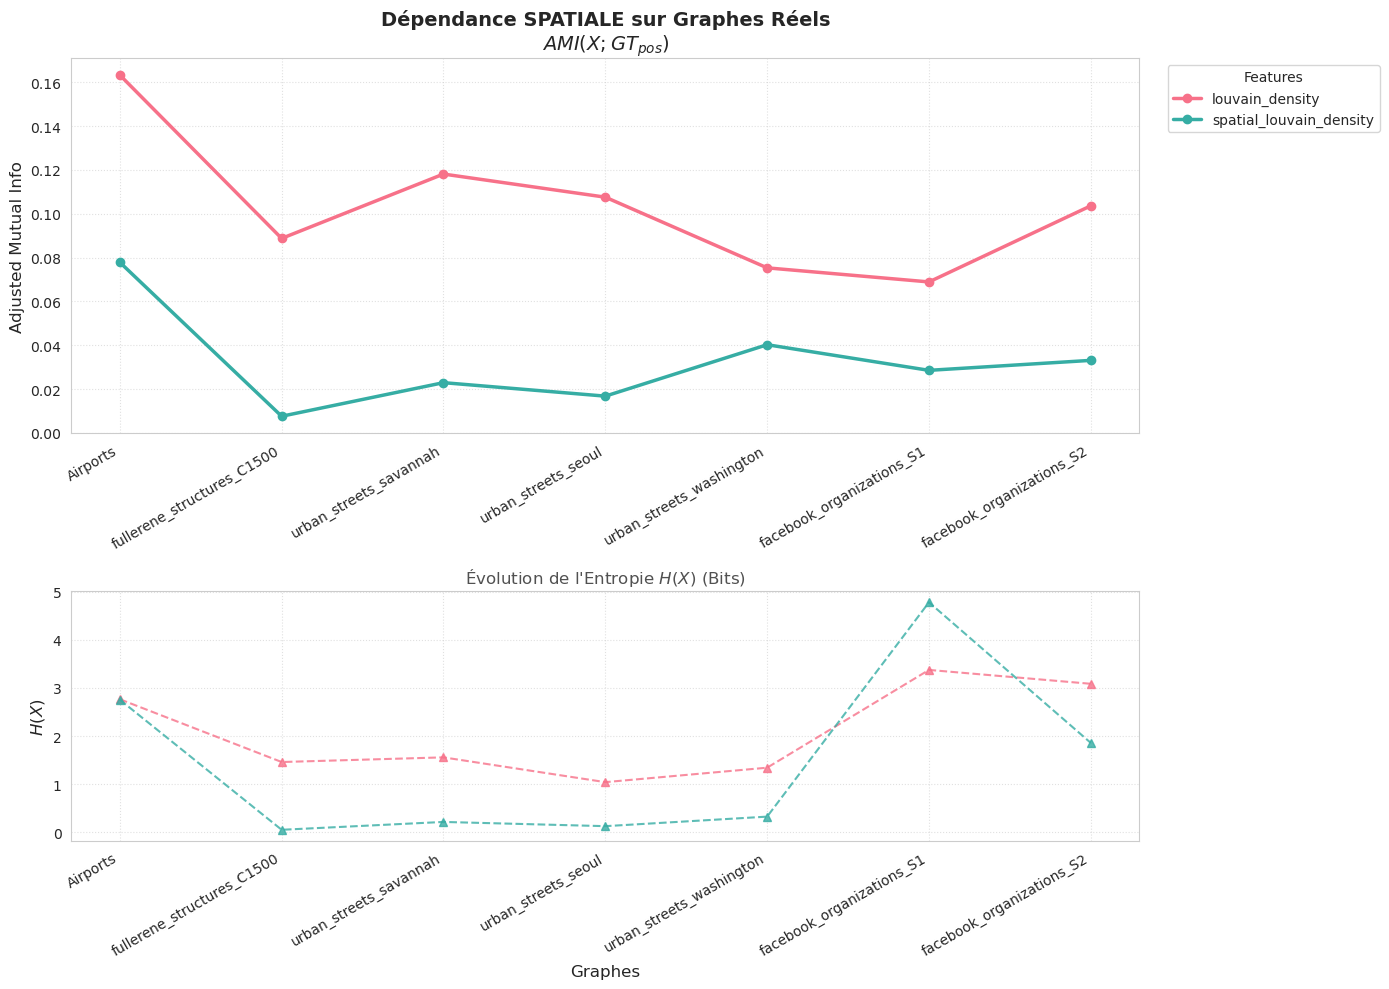

In [35]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import adjusted_mutual_info_score
import os

# --- Fonctions de calcul ---
def calculate_entropy(labels):
    """Calcule l'entropie H(X) en bits."""
    prob_dist = pd.Series(labels).value_counts(normalize=True)
    return -(prob_dist * np.log2(prob_dist)).sum()

def get_adjusted_mi(feature, target):
    """Calcule l'AMI (Adjusted Mutual Information)."""
    return adjusted_mutual_info_score(feature, target)

# --- Configuration ---
G_names_list = [
    "Airports",
    "fullerene_structures_C1500",
    "urban_streets_savannah",
    "urban_streets_seoul",
    "urban_streets_washington",
    "facebook_organizations_S1",
    "facebook_organizations_S2",
]

features_to_test = [
    "louvain_density", 
    "spatial_louvain_density",
    "spatial_louvain_manualreg_density",
    "spatial_louvain_scgravity_density",
    "spatial_louvain_wrdb_density"
]

all_results = []

# --- Boucle sur les Graphes Réels ---
for name in G_names_list:
    try:
        # Chargement du dataset correspondant au graphe réel
        dataset_train = gp.load_dataset(filename=f"dataset_train_{name}", talk=False)
        print(f"Traitement de : {name}")
    except Exception as e:
        print(f"Erreur lors du chargement de {name} : {e}")
        continue
    
    # Binning Logarithmique pour la distance (GT_pos)
    # On ajoute un petit epsilon pour éviter log10(0)
    d_min = dataset_train['GT_pos_dist'].min() + 1e-9
    d_max = dataset_train['GT_pos_dist'].max()
    bins_log = np.logspace(np.log10(d_min), np.log10(d_max), num=21)
    bins_log[0], bins_log[-1] = -np.inf, np.inf 
    
    gt_pos = pd.cut(dataset_train['GT_pos_dist'], bins=bins_log, labels=False, include_lowest=True)

    for feat in features_to_test:
        if feat not in dataset_train.columns:
            continue
        
        # Vecteur de feature arrondi pour stabilité (évite les micro-différences de float)
        feat_vector = dataset_train[feat].round(5).astype(str)
        
        # Calcul des métriques
        mi_pos_ratio = get_adjusted_mi(feat_vector, gt_pos)
        entropie_feature = calculate_entropy(feat_vector)
        
        all_results.append({
            'Graph_Name': name,
            'feature': feat,
            'mi_ratio_pos': mi_pos_ratio,
            'entropie_feature': entropie_feature
        })

# --- Préparation des données ---
df_res = pd.DataFrame(all_results)

# --- Visualisation ---
features = df_res['feature'].unique()
graph_order = G_names_list # On garde l'ordre de la liste initiale
x_coords = np.arange(len(graph_order))
colors = sns.color_palette("husl", len(features))

fig = plt.figure(figsize=(14, 10))
gs = gridspec.GridSpec(2, 1, height_ratios=[1.5, 1])

ax1 = fig.add_subplot(gs[0, 0]) # MI Spatiale
ax2 = fig.add_subplot(gs[1, 0]) # Entropie

for feat, color in zip(features, colors):
    subset = df_res[df_res['feature'] == feat].copy()
    
    # On assure l'alignement des données avec l'ordre des graphes
    subset['Graph_Name'] = pd.Categorical(subset['Graph_Name'], categories=graph_order, ordered=True)
    subset = subset.sort_values('Graph_Name')
    
    # Plot MI Spatiale
    ax1.plot(x_coords, subset['mi_ratio_pos'], label=feat, marker='o', color=color, linewidth=2.5)
    
    # Plot Entropie
    ax2.plot(x_coords, subset['entropie_feature'], label=feat, marker='^', linestyle='--', color=color, alpha=0.8)

# Formatage AX1 (MI)
ax1.set_title("Dépendance SPATIALE sur Graphes Réels\n$AMI(X; GT_{pos})$", fontsize=14, fontweight='bold')
ax1.set_ylabel("Adjusted Mutual Info", fontsize=12)

# Formatage AX2 (Entropie)
ax2.set_title("Évolution de l'Entropie $H(X)$ (Bits)", fontsize=12, alpha=0.8)
ax2.set_xlabel("Graphes", fontsize=12)
ax2.set_ylabel("$H(X)$", fontsize=12)

# Configuration commune des axes
for ax in [ax1, ax2]:
    ax.set_xticks(x_coords)
    ax.set_xticklabels(graph_order, rotation=30, ha='right')
    ax.grid(True, linestyle=':', alpha=0.6)

ax1.legend(loc='upper left', bbox_to_anchor=(1.02, 1), title="Features", frameon=True)

plt.tight_layout()

# --- Sauvegarde ---
output_path = "outputs/plots"
os.makedirs(output_path, exist_ok=True)
save_name = os.path.join(output_path, "MI_adjusted_X_GT_G_reels.png")
plt.savefig(save_name, dpi=300, bbox_inches='tight')
print(f"Graphique sauvegardé dans : {save_name}")

plt.show()

## 4 - Other

In [68]:
sbm_val = "1_00"
pos_val = "0_00"
G_name = f"artificial_graph_sbmv4_{sbm_val}_pos_{pos_val}"

G_train, dataset_train, _, _, _, _ = gp.load_all_data_for_graph(G_name)

if 'GroundTruth_JSON' in G_train.graph:
    print(f"[INIT] Extraction de la GT GroundTruth pour {G_name}...")
    gt_raw = json.loads(G_train.graph['GroundTruth_JSON'])
    
    GT = {'GT_pos': np.array(gt_raw['GT_pos'])}

if GT is not None and 'GT_pos' in GT:
    for i, node_id in enumerate(G_train.nodes()):
        G_train.nodes[node_id]['GT_pos'] = GT['GT_pos'][i]

P, node = gput.get_radiation_null_model_iterative(G_train, "GT_pos", speak=True)

#G_train= gput._appendSpatialLouvainCommunities(G_train)
#G_train= gput._appendSpatialLeidenCommunities(G_train)

P_symetrik = (P+P.T)/2

print(np.sum(P - P_symetrik) / np.sum(P))

SHAP Analysis introuvable pour artificial_graph_sbmv4_1_00_pos_0_00.
[INIT] Extraction de la GT GroundTruth pour artificial_graph_sbmv4_1_00_pos_0_00...
Lancement de l'optimisation L-BFGS-B pour 198 noeuds...


KeyboardInterrupt: 

## 5 - Graphes pour le papier

## 5.1 - ShapVals évolution de la GT


=== TABLEAU POUR VOTRE PAPIER ===
 sbm_val SHAP_GT_pos_dist SHAP_GT_sbm_density
     0.0  2.1644 ± 0.1245     0.2317 ± 0.0206
     0.1  1.8726 ± 0.0900     0.4158 ± 0.0533
     0.2  1.5545 ± 0.0554     0.5908 ± 0.0587
     0.3  1.3979 ± 0.0637     0.7387 ± 0.0348
     0.4  1.1828 ± 0.0692     0.8812 ± 0.0493
     0.5  1.1123 ± 0.0846     1.0491 ± 0.0498
     0.6  0.9279 ± 0.0564     1.1443 ± 0.0700
     0.7  0.8374 ± 0.0492     1.3730 ± 0.0538
     0.8  0.6641 ± 0.0530     1.5164 ± 0.0708
     0.9  0.4696 ± 0.0311     1.7690 ± 0.0415
     1.0  0.3167 ± 0.0300     2.2268 ± 0.1050
Graphique sauvegardé avec succès dans : outputs/plots/SHAPvals_GT_evolution_sbmv4.png


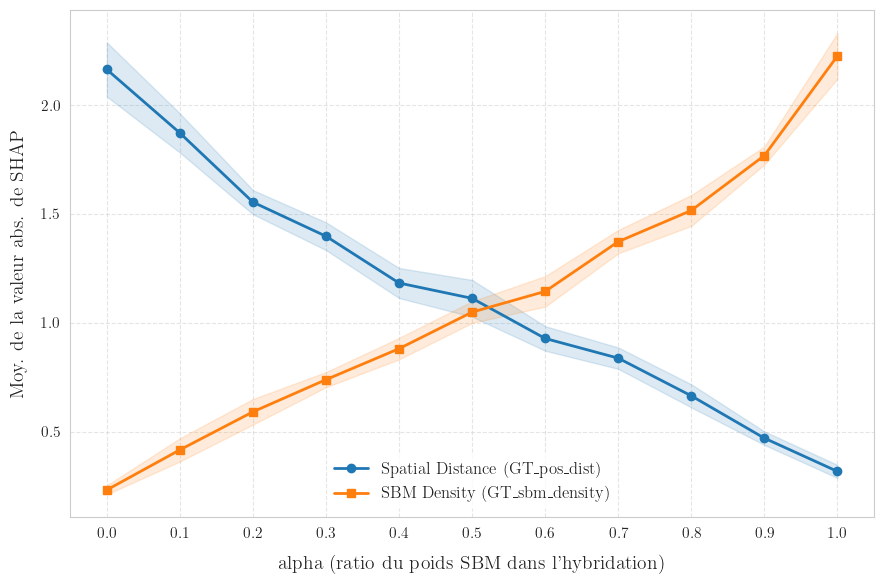

In [5]:
# =====================================================================
# Sur les graphes SBMV V4
# =====================================================================

df_results = pd.read_csv("outputs/results/00_detailed_shap_results_sbmv4_GT.csv")

# Liste de vos métriques SHAP
metrics = ['SHAP_GT_pos_dist', 'SHAP_GT_sbm_density']

# =====================================================================
# PARTIE 1 : CALCUL DES STATISTIQUES (MOYENNE & IC 95%)
# =====================================================================

# Calcul du nombre d'itérations par sbm_val
n_iterations = df_results.groupby('sbm_val').size().iloc[0]

def get_ic95_half_width(series):
    """Calcule la demi-largeur de l'intervalle de confiance à 95%"""
    n = len(series)
    if n <= 1:
        return 0.0
    std_err = stats.sem(series) # Écart-type de la moyenne (std / sqrt(n))
    # Utilisation de la loi de Student pour les petits échantillons (n < 30)
    # Si n est grand, ça converge automatiquement vers 1.96
    h = std_err * stats.t.ppf((1 + 0.95) / 2., n - 1)
    return h

# Agrégation : calcul de la moyenne et de la demi-largeur de l'IC95
df_stats = df_results.groupby('sbm_val').agg(['mean', get_ic95_half_width])

# =====================================================================
# PARTIE 2 : GÉNÉRATION DU TABLEAU (STYLE TEXTE / LATEX)
# =====================================================================
df_table = pd.DataFrame()
df_table['sbm_val'] = df_stats.index

for metric in metrics:
    means = df_stats[(metric, 'mean')].values
    ics = df_stats[(metric, 'get_ic95_half_width')].values
    
    # Formatage propre "Moyenne ± IC95" pour chaque cellule
    df_table[metric] = [f"{m:.4f} ± {ic:.4f}" for m, ic in zip(means, ics)]

print("\n=== TABLEAU POUR VOTRE PAPIER ===")
print(df_table.to_string(index=False))

# Optionnel : Si vous voulez directement copier/coller le code LaTeX (booktabs) !
# print("\n=== CODE LATEX (BOOKTABS) ===")
# print(df_table.to_latex(index=False, column_format='c|cc'))


# =====================================================================
# PARTIE 3 : LE LINE PLOT AVEC BANDE D'ERREUR (IC 95%)
# =====================================================================
# Configuration du style "publication scientifique"
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"], # La police par défaut de LaTeX
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'figure.titlesize': 16
})

plt.rcParams.update({
    
})

plt.figure(figsize=(9, 6))

# Définition des couleurs et labels explicites pour le papier
plot_configs = {
    'SHAP_GT_pos_dist': {'color': '#1f77b4', 'label': 'Spatial Distance (GT_pos_dist)', 'marker': 'o'},
    'SHAP_GT_sbm_density': {'color': '#ff7f0e', 'label': 'SBM Density (GT_sbm_density)', 'marker': 's'}
}

x_vals = df_stats.index.values

for metric in metrics:
    means = df_stats[(metric, 'mean')].values
    ics = df_stats[(metric, 'get_ic95_half_width')].values
    
    # 1. Tracé de la ligne principale
    plt.plot(x_vals, means, 
             label=plot_configs[metric]['label'], 
             color=plot_configs[metric]['color'], 
             marker=plot_configs[metric]['marker'], 
             linewidth=2, markersize=6)
    
    # 2. Tracé de la bande d'ombrage pour l'IC 95%
    plt.fill_between(x_vals, 
                     means - ics, 
                     means + ics, 
                     color=plot_configs[metric]['color'], 
                     alpha=0.15) # alpha gère la transparence de la bande

# Personnalisation des axes
plt.xlabel(r"alpha (ratio du poids SBM dans l'hybridation)", labelpad=10)
plt.ylabel('Moy. de la valeur abs. de SHAP', labelpad=10)
#plt.title('Evolution des SHAP valeurs pendant la transition spatial vers sbm', pad=15, fontweight='bold')

# On force l'affichage de l'axe X de 1.0 à 0.0 pour bien refléter votre boucle décroissante
plt.xlim(-0.05, 1.05) 
plt.xticks(np.arange(0.0, 1.1, 0.1))

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='best', frameon=True, facecolor='white', edgecolor='none')
plt.tight_layout()

# Sauvegarde en haute définition pour les soumissions de papiers (300 DPI minimum)
output_path = "outputs/plots/SHAPvals_GT_evolution_sbmv4.png"
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"Graphique sauvegardé avec succès dans : {output_path}")
plt.show()

## 5.2 - ShapVals évolution par paradigme (all metrics)


=== TABLEAU POUR VOTRE PAPIER ===
 sbm_val CAT_Topologiques CAT_Communautés  CAT_Embeddings
     0.0  1.0903 ± 0.2074 1.4245 ± 0.3273 0.9252 ± 0.0710
     0.1  0.8223 ± 0.1789 1.3070 ± 0.3037 1.1049 ± 0.1099
     0.2  0.6300 ± 0.0830 1.1344 ± 0.2038 1.0245 ± 0.0856
     0.3  0.6352 ± 0.0955 0.9578 ± 0.2119 1.0507 ± 0.0924
     0.4  0.6830 ± 0.1245 0.8372 ± 0.1345 1.0633 ± 0.1726
     0.5  0.7411 ± 0.1351 0.7989 ± 0.1019 0.9739 ± 0.0882
     0.6  0.8017 ± 0.1428 0.8405 ± 0.1255 0.9827 ± 0.1068
     0.7  0.8220 ± 0.1142 0.8300 ± 0.1412 0.9613 ± 0.0844
     0.8  0.8745 ± 0.1492 0.9397 ± 0.1670 1.0082 ± 0.0841
     0.9  1.0157 ± 0.1673 1.1220 ± 0.2738 1.0022 ± 0.1351
     1.0  1.3174 ± 0.2613 1.0609 ± 0.1962 1.0849 ± 0.1439

=== CODE LATEX (BOOKTABS) ===
\begin{tabular}{c|ccc}
\toprule
sbm_val & CAT_Topologiques & CAT_Communautés & CAT_Embeddings \\
\midrule
0.000000 & 1.0903 ± 0.2074 & 1.4245 ± 0.3273 & 0.9252 ± 0.0710 \\
0.100000 & 0.8223 ± 0.1789 & 1.3070 ± 0.3037 & 1.1049 ± 0.1099 \\


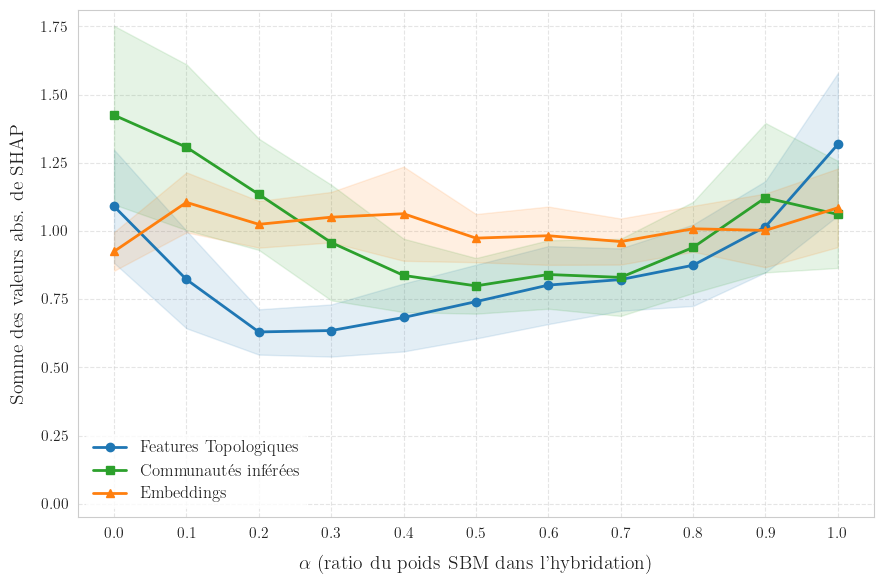

In [76]:
# =====================================================================
# Par catégorie de feature ahora :
# =====================================================================
features_topologiques = [
    'pr_u', 'pr_v', 'ppr_u', 'ppr_v', 'lcc_u', 'lcc_v', 'and_u', 'and_v', 'dc_u', 'dc_v', 'katz_u', 'katz_v',
    'sp', 'jc', 'aa', 'cn', 'pa', 'ra'
]
features_commu_inferee = [
    'louvain_density', 'infomap_density', 'sbm_density', 'leiden_density',
    'surprise_density', 'significance_density'
]
features_embeddings = [
    'deepwalk_cos', 'deepwalk_dist', 'n2v_homophily_cos', 'n2v_homophily_dist', 'crosswalk_cos', 'crosswalk_dist'
]

# Dictionnaire de correspondance pour automatiser le traitement
categories = {
    'CAT_Topologiques': [f"SHAP_{f}" for f in features_topologiques],
    'CAT_Communautés': [f"SHAP_{f}" for f in features_commu_inferee],
    'CAT_Embeddings': [f"SHAP_{f}" for f in features_embeddings]
}

# =====================================================================
# Chargement et Pré-calcul des Sommes par Catégorie
# =====================================================================
input_path = "outputs/results/00_detailed_shap_results_sbmv4_AllBasicMetrics.csv"
df_raw = pd.read_csv(input_path)

# 1. On calcule d'abord la moyenne et l'écart-type de CHAQUE feature individuelle par sbm_val
# On récupère toutes les features uniques présentes dans nos catégories
all_valid_features = []
for col_list in categories.values():
    all_valid_features.extend([c for c in col_list if c in df_raw.columns])

# Groupe par sbm_val pour obtenir les stats de chaque feature
df_feat_stats = df_raw.groupby('sbm_val')[all_valid_features].agg(['mean', 'std', 'count'])

# 2. On construit le DataFrame final block par block (Somme des moyennes)
sbm_vals = df_feat_stats.index
df_stats = pd.DataFrame(index=sbm_vals)

metrics = list(categories.keys())

for cat_name, col_list in categories.items():
    valid_cols = [c for c in col_list if c in df_raw.columns]
    
    if not valid_cols:
        continue
        
    # Somme des moyennes de chaque feature de la catégorie (Votre nouvelle logique)
    cat_means = np.zeros(len(sbm_vals))
    # Pour la propagation de la variance (calcul propre de l'IC95)
    cat_variance_of_mean = np.zeros(len(sbm_vals))
    
    for feat in valid_cols:
        means = df_feat_stats[(feat, 'mean')].values
        stds = df_feat_stats[(feat, 'std')].values
        ns = df_feat_stats[(feat, 'count')].values
        
        cat_means += means
        # Variance de la moyenne de la feature = std^2 / n
        # (On fait la somme des variances pour la propagation de l'erreur)
        cat_variance_of_mean += (stds ** 2) / ns

    # On injecte la moyenne cumulée dans notre structure finale
    df_stats[(cat_name, 'mean')] = cat_means
    
    # Calcul de l'IC95 combiné via la loi de Student et l'erreur type combinée
    # Erreur type combinée = racine(somme des variances des moyennes)
    combined_se = np.sqrt(cat_variance_of_mean)
    
    # On prend le 'n' du premier élément (toutes les features ont le même nombre d'itérations)
    n_total = df_feat_stats[(valid_cols[0], 'count')].values[0]
    
    # Calcul de la demi-largeur de l'IC95 propagé
    t_critical = stats.t.ppf((1 + 0.95) / 2., n_total - 1)
    df_stats[(cat_name, 'get_ic95_half_width')] = combined_se * t_critical

# Réorganisation de l'index des colonnes pour correspondre au reste de votre script de tracé
df_stats.columns = pd.MultiIndex.from_tuples(df_stats.columns)

# =====================================================================
# PARTIE 1 : CALCUL DES STATISTIQUES (MOYENNE & IC 95%)
# =====================================================================

#df_stats = df_results.groupby('sbm_val').agg(['mean', get_ic95_half_width])

# =====================================================================
# PARTIE 2 : GÉNÉRATION DU TABLEAU (STYLE TEXTE / LATEX)
# =====================================================================
df_table = pd.DataFrame()
df_table['sbm_val'] = df_stats.index

for metric in metrics:
    means = df_stats[(metric, 'mean')].values
    ics = df_stats[(metric, 'get_ic95_half_width')].values
    
    # Formatage "Moyenne ± IC95"
    df_table[metric] = [f"{m:.4f} ± {ic:.4f}" for m, ic in zip(means, ics)]

print("\n=== TABLEAU POUR VOTRE PAPIER ===")
print(df_table.to_string(index=False))

print("\n=== CODE LATEX (BOOKTABS) ===")
print(df_table.to_latex(index=False, column_format='c|ccc'))


# =====================================================================
# PARTIE 3 : LE LINE PLOT AVEC BANDE D'ERREUR (IC 95%)
# =====================================================================
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'figure.titlesize': 16
})

plt.figure(figsize=(9, 6))

# Définition des styles visuels par catégorie pour le rendu final
plot_configs = {
    'CAT_Topologiques': {'color': '#1f77b4', 'label': 'Features Topologiques', 'marker': 'o'},
    'CAT_Communautés': {'color': '#2ca02c', 'label': 'Communautés inférées', 'marker': 's'},
    'CAT_Embeddings': {'color': '#ff7f0e', 'label': 'Embeddings', 'marker': '^'}
}

x_vals = df_stats.index.values

for metric in metrics:
    means = df_stats[(metric, 'mean')].values
    ics = df_stats[(metric, 'get_ic95_half_width')].values
    
    # 1. Tracé de la ligne principale
    plt.plot(x_vals, means, 
             label=plot_configs[metric]['label'], 
             color=plot_configs[metric]['color'], 
             marker=plot_configs[metric]['marker'], 
             linewidth=2, markersize=6)
    
    # 2. Tracé de la bande d'ombrage pour l'IC 95%
    plt.fill_between(x_vals, 
                     means - ics, 
                     means + ics, 
                     color=plot_configs[metric]['color'], 
                     alpha=0.12)

# Personnalisation des axes
plt.xlabel(r"$\alpha$ (ratio du poids SBM dans l'hybridation)", labelpad=10)
plt.ylabel('Somme des valeurs abs. de SHAP', labelpad=10)

# nettoyage de l'axe X et Y (1.0 à 0.0)
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.81)
plt.xticks(np.arange(1.0, -0.1, -0.1))

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='best', frameon=True, facecolor='white', edgecolor='none')
plt.tight_layout()

# Sauvegarde HD
output_path = "outputs/plots/SHAPvals_AllMetrics_evolution_sbmv4.png"
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"Graphique sauvegardé avec succès dans : {output_path}")
plt.show()

## 5.3 - ShapVals Heatmap des best prédicteurs (all metrics)

🔥 Heatmap du Top 10 sauvegardée avec succès dans : outputs/plots/SHAPvals_top10_heatmap_sbmv4.png


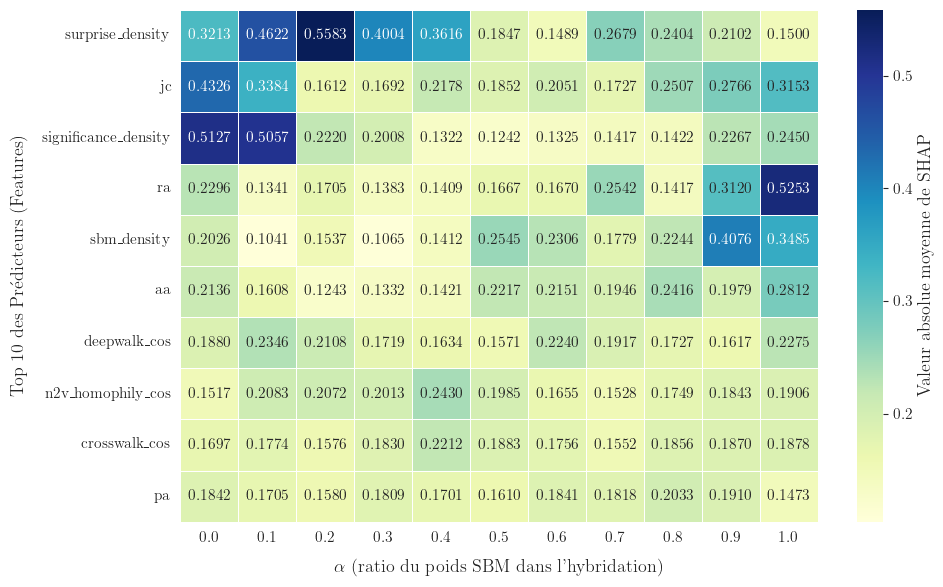

sbm_val                    0.0       0.1       0.2       0.3       0.4  \
surprise_density      0.321271  0.462234  0.558294  0.400357  0.361585   
jc                    0.432600  0.338448  0.161192  0.169176  0.217819   
significance_density  0.512733  0.505659  0.222048  0.200772  0.132220   
ra                    0.229631  0.134122  0.170517  0.138325  0.140858   
sbm_density           0.202579  0.104133  0.153674  0.106517  0.141192   
aa                    0.213567  0.160812  0.124292  0.133237  0.142109   
deepwalk_cos          0.187981  0.234636  0.210753  0.171854  0.163404   
n2v_homophily_cos     0.151671  0.208279  0.207221  0.201343  0.243048   
crosswalk_cos         0.169686  0.177352  0.157600  0.183025  0.221237   
pa                    0.184246  0.170480  0.157993  0.180929  0.170122   

sbm_val                    0.5       0.6       0.7       0.8       0.9  \
surprise_density      0.184699  0.148946  0.267932  0.240368  0.210191   
jc                    0.185174  0.205

In [77]:
# =====================================================================
# 1. Chargement et Calcul des Moyennes Individuelles
# =====================================================================
input_path = "outputs/results/00_detailed_shap_results_sbmv4_AllBasicMetrics.csv"
df_raw = pd.read_csv(input_path)

# On isole toutes les colonnes de features SHAP (commençant par 'SHAP_')
shap_cols = [c for c in df_raw.columns if c.startswith('SHAP_')]

# Calcul de la moyenne de chaque feature pour chaque sbm_val (axe alpha)
df_means_by_alpha = df_raw.groupby('sbm_val')[shap_cols].mean()

# =====================================================================
# 2. Sélection du Top 10 des Prédicteurs (Meilleure Moyenne Globale)
# =====================================================================
# On calcule la moyenne absolue sur l'ensemble des configurations d'alpha
top_10_features = df_means_by_alpha.mean(axis=0).nlargest(10).index

# On filtre notre matrice pour ne garder que ce Top 10
df_heatmap_data = df_means_by_alpha[top_10_features]

# Nettoyage cosmétique des noms de features pour le papier (on enlève le préfixe 'SHAP_')
df_heatmap_data.columns = [c.replace('SHAP_', '') for c in df_heatmap_data.columns]

# Transposition de la matrice : on veut les features en lignes et alpha en colonnes
df_heatmap_data = df_heatmap_data.T

# On trie les colonnes (sbm_val) de 1.0 à 0.0 pour respecter votre sens de transition
df_heatmap_data = df_heatmap_data.reindex(columns=sorted(df_heatmap_data.columns, reverse=False))

# =====================================================================
# 3. Génération de la Heatmap (Style Publication)
# =====================================================================
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    'font.size': 11,
    'axes.labelsize': 13,
    'axes.titlesize': 14
})

plt.figure(figsize=(10, 6))

# Création de la heatmap avec seaborn
# 'YlGnBu' ou 'Viridis' sont très appréciés des reviewers car lisibles en noir & blanc
sns.heatmap(
    df_heatmap_data, 
    annot=True,              # Affiche la valeur brute dans la case
    fmt=".4f",               # Format des floats à 4 décimales
    cmap="YlGnBu",           # Palette scientifique
    linewidths=.5,           # Ligne fine de séparation entre les cases
    cbar_kws={'label': 'Valeur absolue moyenne de SHAP'}
)

# Ajustement des labels
plt.xlabel(r"$\alpha$ (ratio du poids SBM dans l'hybridation)", labelpad=10)
plt.ylabel('Top 10 des Prédicteurs (Features)', labelpad=10)

plt.tight_layout()

# Sauvegarde HD
output_dir = "outputs/plots"
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, "SHAPvals_top10_heatmap_sbmv4.png")

plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"🔥 Heatmap du Top 10 sauvegardée avec succès dans : {output_path}")
plt.show()

print(df_heatmap_data)

## 5.4 - MI entre GT et les groupes de features commu et embedd et topo

In [105]:
import json
import os
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import entropy
from sklearn.metrics import mutual_info_score

warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    message="The number of unique classes is greater than 50%",
)


# --- 1. Fonctions Utiles ---
def bining_features_dataset(dataset, features, n_bins):
    df_binned = dataset.copy()
    for col in features:
        try:
            df_binned[col] = pd.qcut(
                dataset[col], n_bins, labels=False, duplicates="drop"
            )
        except Exception:
            pass
    return df_binned


def get_coverage_ratio(dataset, feature_list, features_GT):
    series_X = dataset[feature_list].astype(str).agg("-".join, axis=1)
    series_GT = dataset[features_GT].astype(str).agg("-".join, axis=1)
    mi_score = mutual_info_score(series_X, series_GT)
    h_gt = entropy(series_GT.value_counts(normalize=True))
    return min(1.0, mi_score / h_gt) if h_gt > 0 else 0.0

features_commu_inferee = [
    "louvain_density","infomap_density","sbm_density",
    "leiden_density","surprise_density","significance_density",]

features_embeddings = ["deepwalk_cos","deepwalk_dist","n2v_homophily_cos",
    "n2v_homophily_dist","crosswalk_cos","crosswalk_dist",]

features_topologiques = ['pr_u', 'pr_v','ppr_u', 'ppr_v', 'lcc_u', 'lcc_v', 'and_u', 'and_v', 'dc_u', 'dc_v', 'katz_u', 'katz_v',
                              'sp', 'jc', 'aa', 'cn','pa', 'ra']

families = {
    "Communautés": features_commu_inferee,
    "Embeddings": features_embeddings,
    "Topologiques": features_topologiques,
}
all_results = []

# --- 3. Boucle de Calcul Conjoint ---
for nbiter in range(1, 11):
    for i in np.arange(1.00, -0.10, -0.10):
        sbm_val, pos_val = f"{i:.2f}", f"{1 - i:.2f}"
        suf = f"{sbm_val.replace('.', '_')}_pos_{pos_val.replace('.', '_')}_{nbiter}"
        if sbm_val == 0.00 :
            print(f"Iter {nbiter} terminada")

        try:
            dataset_train = gp.load_dataset(
                filename=f"dataset_train_artificial_graph_sbmv_4_AllBasicMetrics_{suf}",
                talk=False,
            )
            G = load_graphml_safe(
                f"graph_library/artificial_graph_sbmv_4_{suf}.graphml"
            )
            gt_raw = json.loads(G.graph["GroundTruth_JSON"])
        except Exception:
            continue

        # Calcul GT SBM à la volée
        n1, n2 = (
            dataset_train["u"].astype(int).values,
            dataset_train["v"].astype(int).values,
        )
        dataset_train["GT_sbm_density"] = np.array(gt_raw["GT_sbm_matrix"])[
            np.array(gt_raw["GT_sbm_id"])[n1], np.array(gt_raw["GT_sbm_id"])[n2]
        ]

        # Binning global (13 bins)
        all_cols = (
            features_commu_inferee
            + features_embeddings
            + features_topologiques
            + ["GT_sbm_density", "GT_pos_dist"]
        )
        dt_binned = bining_features_dataset(dataset_train, all_cols, 13)

        # Calcul conjoint direct par famille
        for name, feats in families.items():
            all_results.append(
                {
                    "iter": nbiter,
                    "ratio_sbm": i,
                    "category": name,
                    "cov_sbm": get_coverage_ratio(
                        dt_binned, feats, ["GT_sbm_density"]
                    ),
                    "cov_pos": get_coverage_ratio(
                        dt_binned, feats, ["GT_pos_dist"]
                    ),
                }
            )

# --- 4. Agrégation One-Liner ---
stats_macro = (
    pd.DataFrame(all_results)
    .groupby(["category", "ratio_sbm"])
    .agg({"cov_sbm": ["mean", "std"], "cov_pos": ["mean", "std"]})
    .reset_index()
)
stats_macro.columns = [
    "_".join(col).strip("_") for col in stats_macro.columns.values
]

# --- 5. Tracé ---
i_values = sorted(stats_macro["ratio_sbm"].unique(), reverse=True)
np.save(
    "outputs/results/00_MIstudy_metricsCategories_GTsbmpos.npy",
    np.array(i_values),
)

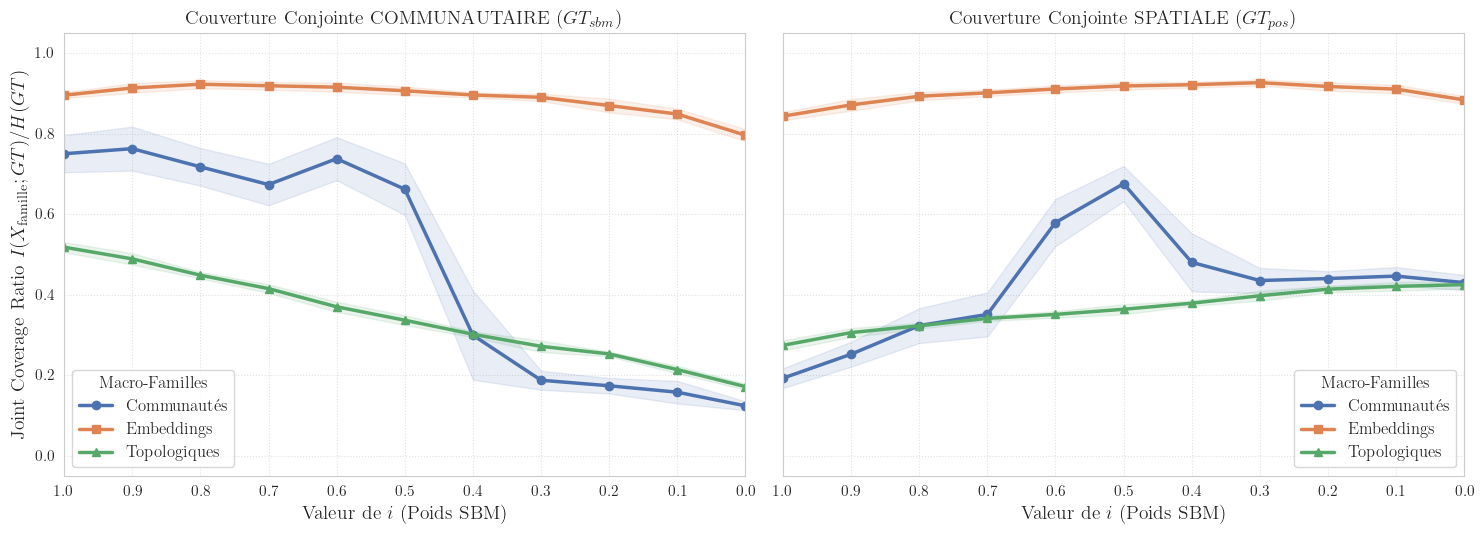

In [108]:
# --- 5. Tracé Sécurisé ---
# On nettoie d'abord les figures précédentes restées en mémoire
plt.close("all")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True)
styles = {
    "Communautés": {"c": "#4C72B0", "m": "o"},
    "Embeddings": {"c": "#DD8452", "m": "s"},
    "Topologiques": {"c": "#55A868", "m": "^"},
}

for cat, style in styles.items():
    # .dropna() pour éviter que Matplotlib ne crashe si une itération a sauté
    sub = stats_macro[stats_macro["category"] == cat].dropna()
    if sub.empty:
        continue

    # Conversion explicite en float/arrays numpy propres pour le moteur graphique
    x = sub["ratio_sbm"].astype(float).values
    y_sbm = sub["cov_sbm_mean"].astype(float).values
    err_sbm = sub["cov_sbm_std"].fillna(0).astype(float).values

    y_pos = sub["cov_pos_mean"].astype(float).values
    err_pos = sub["cov_pos_std"].fillna(0).astype(float).values

    # Gauche : Signal Communautaire
    ax1.plot(x, y_sbm, label=cat, marker=style["m"], color=style["c"], lw=2.5)
    ax1.fill_between(
        x,
        np.maximum(0, y_sbm - err_sbm),
        np.minimum(1, y_sbm + err_sbm),
        color=style["c"],
        alpha=0.12,
    )

    # Droite : Signal Spatial
    ax2.plot(x, y_pos, label=cat, marker=style["m"], color=style["c"], lw=2.5)
    ax2.fill_between(
        x,
        np.maximum(0, y_pos - err_pos),
        np.minimum(1, y_pos + err_pos),
        color=style["c"],
        alpha=0.12,
    )

ax1.set_title(
    "Couverture Conjointe COMMUNAUTAIRE ($GT_{sbm}$)", fontweight="bold"
)
ax2.set_title("Couverture Conjointe SPATIALE ($GT_{pos}$)", fontweight="bold")
ax1.set_ylabel("Joint Coverage Ratio $I(X_{\\mathrm{famille}}; GT) / H(GT)$")

for ax in [ax1, ax2]:
    ax.set_xlabel("Valeur de $i$ (Poids SBM)")
    ax.set_xticks(i_values)
    ax.set_xticklabels([f"{v:.1f}" for v in i_values])
    ax.set_xlim(max(i_values), min(i_values))
    ax.set_ylim(-0.05, 1.05)  # On force les limites pour un affichage propre
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend(title="Macro-Familles")

plt.tight_layout()
os.makedirs(
    "outputs/results/00_MIstudy_metricsCategories_GTsbmpos", exist_ok=True
)
plt.savefig(
    "outputs/results/00_MIstudy_metricsCategories_GTsbmpos/macro_joint_coverage_study.png",
    dpi=300,
    bbox_inches="tight",
)

# Affiche et libère la mémoire
plt.show()
plt.close(fig)

## 5.5 - MI entre features individuelles et GT_sbm / GT_pos

In [199]:
features_commu_inferee = [
    "louvain_density","infomap_density","sbm_density",
    "leiden_density","surprise_density","significance_density"]

features_embeddings = ["deepwalk_cos","deepwalk_dist","n2v_homophily_cos",
    "n2v_homophily_dist","crosswalk_cos","crosswalk_dist",]

plt.close("all")

warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    message="The number of unique classes is greater than 50%",
)


def get_adjusted_mi(feature, target):
    """Calcule l'AMI (Adjusted Mutual Information)."""
    return adjusted_mutual_info_score(feature, target)

# Fusion pour la boucle de calcul
all_features_to_test = features_commu_inferee + features_embeddings
all_results = []

# --- 2. BOUCLE PRINCIPALE : DATA PROCESS & CALCULS ---
for nbiter in range(1, 11):
    for i in np.arange(1.00, -0.10, -0.10):
        sbm_val = f"{i:.2f}"
        pos_val = f"{1 - i:.2f}"
        G_name = f"artificial_graph_sbmv_4_AllBasicMetrics_{sbm_val.replace('.', '_')}_pos_{pos_val.replace('.', '_')}_{nbiter}"
        G_name_graph = f"artificial_graph_sbmv_4_{sbm_val.replace('.', '_')}_pos_{pos_val.replace('.', '_')}_{nbiter}"

        try:
            # Chargement des données d'origine
            dataset_train = gp.load_dataset(
                filename=f"dataset_train_{G_name}", talk=False
            )
            G = load_graphml_safe(f"graph_library/{G_name_graph}.graphml")

            if "GroundTruth_JSON" in G.graph:
                gt_raw = json.loads(G.graph["GroundTruth_JSON"])
                GT = {
                    "GT_sbm_matrix": np.array(gt_raw["GT_sbm_matrix"]),
                    "GT_sbm_id": np.array(gt_raw["GT_sbm_id"]),
                }
            else:
                continue
        except Exception:
            continue  # Protection contre un fichier corrompu/manquant

        if round(i, 2) == 0.50:
            print(f"Calcul en cours pour l'itération {nbiter}, i = 0.50")

        # Reconstruction de la GT SBM à la volée depuis le JSON
        n1 = dataset_train["u"].astype(int).values
        n2 = dataset_train["v"].astype(int).values
        block_n1 = GT["GT_sbm_id"][n1]
        block_n2 = GT["GT_sbm_id"][n2]
        dataset_train["GT_sbm_density"] = GT["GT_sbm_matrix"][
            block_n1, block_n2
        ]

        # --- BINNING SÉLECTIF ET SÉCURISATION ---
        dt_processed = dataset_train.copy()

        # A. Binning par quantiles UNIQUE pour les variables continues (Embeddings + Cible Spatiale)
        features_continues = features_embeddings + ["GT_pos_dist"]
        for col in features_continues:
            if col in dt_processed.columns:
                try:
                    dt_processed[col] = pd.qcut(
                        dt_processed[col], 13, labels=False, duplicates="drop"
                    )
                except Exception:
                    pass

        # B. Arrondi de sécurité pour les variables discrètes (Communautés + Cible SBM)
        features_discretes = features_commu_inferee + ["GT_sbm_density"]
        for col in features_discretes:
            if col in dt_processed.columns:
                dt_processed[col] = dt_processed[col].round(5).astype(str)

        # Extraction finale sécurisée des vecteurs cibles au format str pour sklearn
        gt_sbm_vector = dt_processed["GT_sbm_density"].astype(str)
        gt_pos_vector = dt_processed["GT_pos_dist"].astype(str)

        # C. Calcul de l'AMI individuelle pour chaque feature
        for feat in all_features_to_test:
            if feat not in dt_processed.columns:
                continue

            feat_vector = dt_processed[feat].astype(str)

            all_results.append(
                {
                    "iter": nbiter,
                    "ratio_sbm": i,
                    "feature": feat,
                    "mi_ratio_sbm": get_adjusted_mi(feat_vector, gt_sbm_vector),
                    "mi_ratio_pos": get_adjusted_mi(feat_vector, gt_pos_vector),
                }
            )

# --- 3. AGRÉGATION ET SAUVEGARDE DES STATISTIQUES ---
df_res = pd.DataFrame(all_results)
stats = (
    df_res.groupby(["feature", "ratio_sbm"])
    .agg({"mi_ratio_pos": ["mean", "std"], "mi_ratio_sbm": ["mean", "std"]})
    .reset_index()
)

# Aplatissement propre des colonnes multiniveaux
stats.columns = [
    "_".join(col).strip("_") for col in stats.columns.values
]  # Génère mi_ratio_pos_mean, etc.

i_values = sorted(stats["ratio_sbm"].unique(), reverse=True)
output_path = "outputs/results/00_MIstudy_metricsCategories_GTsbmpos"
os.makedirs(output_path, exist_ok=True)
np.save(os.path.join(output_path, "i_values.npy"), np.array(i_values))

Calcul en cours pour l'itération 1, i = 0.50
Calcul en cours pour l'itération 2, i = 0.50
Calcul en cours pour l'itération 3, i = 0.50
Calcul en cours pour l'itération 4, i = 0.50
Calcul en cours pour l'itération 5, i = 0.50
Calcul en cours pour l'itération 6, i = 0.50
Calcul en cours pour l'itération 7, i = 0.50
Calcul en cours pour l'itération 8, i = 0.50
Calcul en cours pour l'itération 9, i = 0.50
Calcul en cours pour l'itération 10, i = 0.50


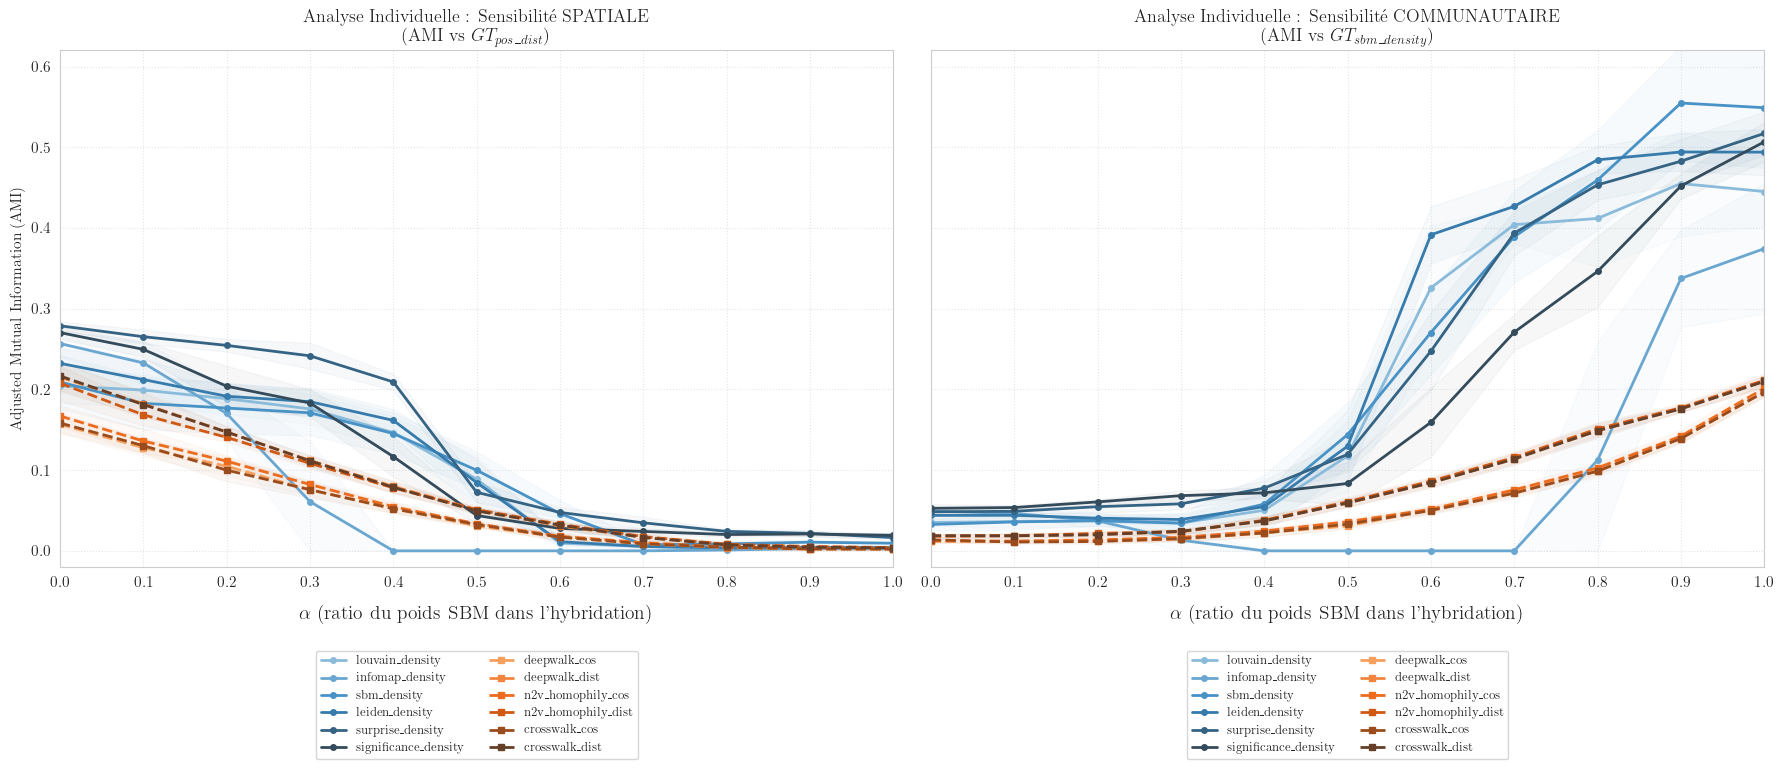

In [200]:
plt.close("all")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8), sharey=True)

# Palettes de couleurs distinctes (Bleu pour les commus, Orange pour les embeddings)
colors_commu = sns.color_palette("Blues_d", len(features_commu_inferee))
colors_embed = sns.color_palette("Oranges_d", len(features_embeddings))

# Mapping graphique pour la lisibilité
feature_styles = {}
for idx, feat in enumerate(features_commu_inferee):
    feature_styles[feat] = {"color": colors_commu[idx], "ls": "-", "marker": "o"}
for idx, feat in enumerate(features_embeddings):
    feature_styles[feat] = {
        "color": colors_embed[idx],
        "ls": "--",
        "marker": "s",
    }

# Tracé des courbes une à une
for feat in all_features_to_test:
    df_feat = stats[stats["feature"] == feat].dropna()
    if df_feat.empty:
        continue

    style = feature_styles[feat]
    x = df_feat["ratio_sbm"].astype(float).values

    y_pos = df_feat["mi_ratio_pos_mean"].astype(float).values
    err_pos = df_feat["mi_ratio_pos_std"].fillna(0).astype(float).values

    y_sbm = df_feat["mi_ratio_sbm_mean"].astype(float).values
    err_sbm = df_feat["mi_ratio_sbm_std"].fillna(0).astype(float).values

    # GAUCHE : AMI vs GT_pos (Signal Spatial)
    ax1.plot(
        x,
        y_pos,
        label=feat,
        color=style["color"],
        linestyle=style["ls"],
        marker=style["marker"],
        markersize=4,
        lw=2,
    )
    ax1.fill_between(
        x,
        np.maximum(0, y_pos - err_pos),
        np.minimum(1, y_pos + err_pos),
        color=style["color"],
        alpha=0.04,
    )

    # DROITE : AMI vs GT_sbm (Signal Communautaire)
    ax2.plot(
        x,
        y_sbm,
        label=feat,
        color=style["color"],
        linestyle=style["ls"],
        marker=style["marker"],
        markersize=4,
        lw=2,
    )
    ax2.fill_between(
        x,
        np.maximum(0, y_sbm - err_sbm),
        np.minimum(1, y_sbm + err_sbm),
        color=style["color"],
        alpha=0.04,
    )

# --- 5. CONFIGURATION FINALE ET HABILLAGE ---
ax1.set_title(
    "Analyse Individuelle : Sensibilité SPATIALE\n(AMI vs $GT_{pos\_dist}$)",
    fontsize=13,
    fontweight="bold",
)
ax2.set_title(
    "Analyse Individuelle : Sensibilité COMMUNAUTAIRE\n(AMI vs $GT_{sbm\_density}$)",
    fontsize=13,
    fontweight="bold",
)

ax1.set_ylabel("Adjusted Mutual Information (AMI)", fontsize=11)

for ax in [ax1, ax2]:
    ax.set_xlabel(r"$\alpha$ (ratio du poids SBM dans l'hybridation)", labelpad=10)
    ax.set_xticks(i_values)
    ax.set_xticklabels([f"{v:.1f}" for v in i_values])
    ax.set_xlim(min(i_values),max(i_values))  # Inversion de l'axe X supprimée
    ax.set_ylim(-0.02, 0.62)
    ax.grid(True, linestyle=":", alpha=0.5)

# Alignement des légendes proprement sous les graphiques
ax1.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2, fontsize=9)
ax2.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2, fontsize=9)

plt.tight_layout()
#plt.savefig("outputs/plots/00_AMI_individual_features_VS_GT_comparison.png",dpi=300,bbox_inches="tight")
plt.savefig("outputs/plots/00_AMI_individual_features_VS_GT_comparison.pdf", bbox_inches="tight")

plt.show()

## 5.6 - Correlation lineaire (spearman) entre feat individuelles et GT_sbm / GT_pos

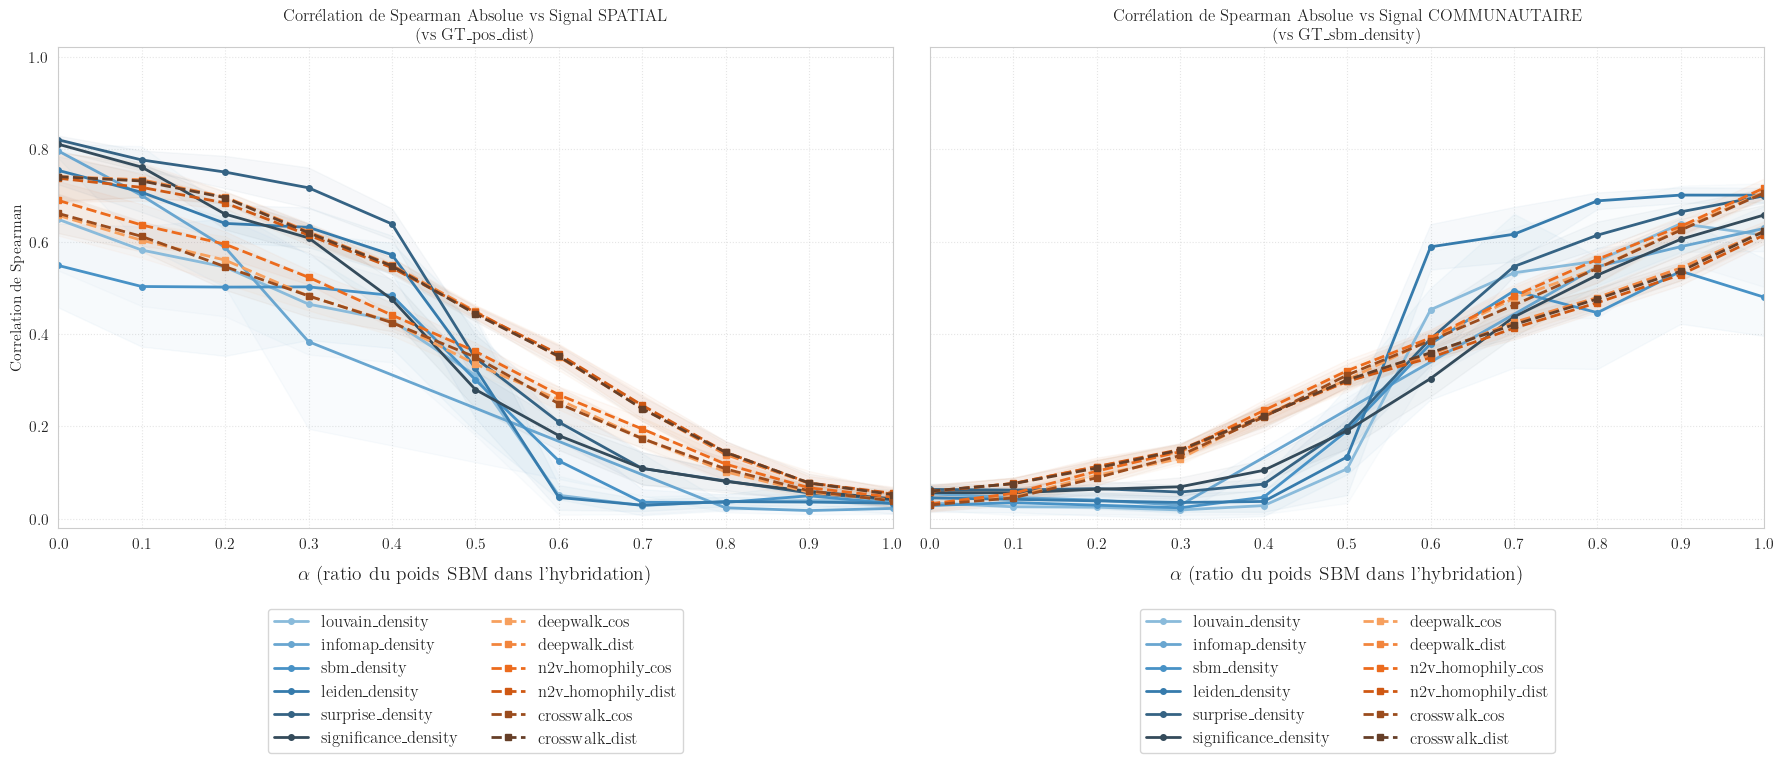

In [197]:
features_commu_inferee = [
    "louvain_density","infomap_density","sbm_density",
    "leiden_density","surprise_density","significance_density",]

features_embeddings = ["deepwalk_cos","deepwalk_dist","n2v_homophily_cos",
    "n2v_homophily_dist","crosswalk_cos","crosswalk_dist",]

features_commus_unbiaised = ['louvain_density', "spatial_louvain_density"]

features_embed_unbiaised = ['SiNEcustom_spatial', 'deepwalk']

plt.close("all")
warnings.filterwarnings("ignore")

all_features_to_test = features_commu_inferee + features_embeddings
#all_features_to_test = features_commus_unbiaised

all_corr_results = []

# --- 2. BOUCLE PRINCIPALE : CALCUL DES CORRÉLATIONS ---
for nbiter in range(1, 11):
    for i in np.arange(1.00, -0.10, -0.10):
        sbm_val, pos_val = f"{i:.2f}", f"{1 - i:.2f}"
        suf = f"{sbm_val.replace('.', '_')}_pos_{pos_val.replace('.', '_')}_{nbiter}"

        dataset_train = gp.load_dataset(filename=f"dataset_train_artificial_graph_sbmv_4_AllBasicMetrics_{suf}",talk=False)
        #dataset_train = gp.load_dataset(filename=f"dataset_train_artificial_graph_sbmv_4_comuAndEmb_{suf}",talk=False)

        G = load_graphml_safe(f"graph_library/artificial_graph_sbmv_4_{suf}.graphml")
        gt_raw = json.loads(G.graph["GroundTruth_JSON"])

        
        # Calcul GT SBM à la volée
        n1, n2 = (
            dataset_train["u"].astype(int).values,
            dataset_train["v"].astype(int).values,
        )
        dataset_train["GT_sbm_density"] = np.array(gt_raw["GT_sbm_matrix"])[
            np.array(gt_raw["GT_sbm_id"])[n1], np.array(gt_raw["GT_sbm_id"])[n2]
        ]

        # --- CALCUL DIRECT DE CORRÉLATION (SPEARMAN) ---
        # On extrait la matrice de corrélation pour les colonnes qui nous intéressent
        cols_to_corr = all_features_to_test + ["GT_sbm_density", "GT_pos_dist"]
        # .corr() renvoie un dataframe contenant les coefficients entre -1 et 1
        corr_matrix = dataset_train[cols_to_corr].corr(method="spearman")

        for feat in all_features_to_test:
            if feat not in corr_matrix.columns:
                continue

            # On extrait la valeur absolue car une corrélation négative forte (ex: -0.90) 
            # signifie une dépendance parfaite (souvent le cas pour les distances vs similitudes)
            corr_sbm = abs(corr_matrix.loc[feat, "GT_sbm_density"])
            corr_pos = abs(corr_matrix.loc[feat, "GT_pos_dist"])

            all_corr_results.append(
                {
                    "iter": nbiter,
                    "ratio_sbm": i,
                    "feature": feat,
                    "corr_sbm": corr_sbm,
                    "corr_pos": corr_pos,
                }
            )

# --- 3. AGRÉGATION ---
df_corr = pd.DataFrame(all_corr_results)
stats_corr = (
    df_corr.groupby(["feature", "ratio_sbm"])
    .agg({"corr_sbm": ["mean", "std"], "corr_pos": ["mean", "std"]})
    .reset_index()
)
stats_corr.columns = [
    "_".join(col).strip("_") for col in stats_corr.columns.values
]

i_values = sorted(stats_corr["ratio_sbm"].unique(), reverse=True)

# --- 4. TRACÉ ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8), sharey=True)

colors_commu = sns.color_palette("Blues_d", len(features_commu_inferee))
colors_embed = sns.color_palette("Oranges_d", len(features_embeddings))

feature_styles = {}
for idx, feat in enumerate(features_commu_inferee):
    feature_styles[feat] = {"color": colors_commu[idx], "ls": "-", "marker": "o"}
for idx, feat in enumerate(features_embeddings):
    feature_styles[feat] = {
        "color": colors_embed[idx],
        "ls": "--",
        "marker": "s",
    }

for feat in all_features_to_test:
    df_feat = stats_corr[stats_corr["feature"] == feat].dropna()
    if df_feat.empty:
        continue

    style = feature_styles[feat]
    x = df_feat["ratio_sbm"].astype(float).values

    y_pos = df_feat["corr_pos_mean"].astype(float).values
    err_pos = df_feat["corr_pos_std"].fillna(0).astype(float).values

    y_sbm = df_feat["corr_sbm_mean"].astype(float).values
    err_sbm = df_feat["corr_sbm_std"].fillna(0).astype(float).values

    # Gauche : Corrélation avec la Géométrie
    ax1.plot(
        x,
        y_pos,
        label=feat,
        color=style["color"],
        linestyle=style["ls"],
        marker=style["marker"],
        markersize=4,
        lw=2,
    )
    ax1.fill_between(
        x,
        np.maximum(0, y_pos - err_pos),
        np.minimum(1, y_pos + err_pos),
        color=style["color"],
        alpha=0.04,
    )

    # Droite : Corrélation avec les Communautés
    ax2.plot(
        x,
        y_sbm,
        label=feat,
        color=style["color"],
        linestyle=style["ls"],
        marker=style["marker"],
        markersize=4,
        lw=2,
    )
    ax2.fill_between(
        x,
        np.maximum(0, y_sbm - err_sbm),
        np.minimum(1, y_sbm + err_sbm),
        color=style["color"],
        alpha=0.04,
    )

# --- 5. CONFIGURATION FINALE ---
ax1.set_title(
    "Corrélation de Spearman Absolue vs Signal SPATIAL\n(vs GT_pos_dist)",
    fontsize=12,
    fontweight="bold",
)
ax2.set_title(
    "Corrélation de Spearman Absolue vs Signal COMMUNAUTAIRE\n(vs GT_sbm_density)",
    fontsize=12,
    fontweight="bold",
)

ax1.set_ylabel("Correlation de Spearman", fontsize=11)

for ax in [ax1, ax2]:
    ax.set_xlabel(r"$\alpha$ (ratio du poids SBM dans l'hybridation)", labelpad=10)
    ax.set_xticks(i_values)
    ax.set_xticklabels([f"{v:.1f}" for v in i_values])
    ax.set_xlim(min(i_values), max(i_values))
    ax.set_ylim(-0.02, 1.02)
    ax.grid(True, linestyle=":", alpha=0.5)

ax1.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2, fontsize=12)
ax2.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2, fontsize=12)

plt.tight_layout()
os.makedirs("outputs/plots", exist_ok=True)
plt.savefig("outputs/plots/00_Correl_individual_features_VS_GT_comparison.pdf", bbox_inches="tight")
#plt.savefig("outputs/plots/00_Correl_louvain_VS_louvainUnbiased_comparison.png",dpi=300,bbox_inches="tight")

plt.show()

## 5.7 - Matrice Correlation entre features

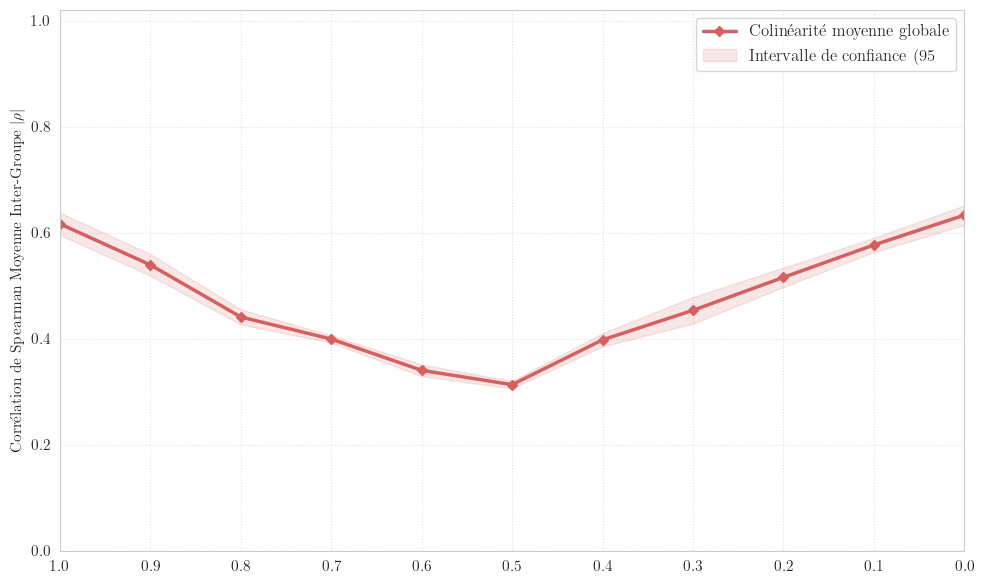


=== CODE LATEX POUR LLNCS ===

\begin{table}
  \centering
  \caption{Évolution de la colinéarité moyenne inter-paradigme (Spearman absolue) en fonction de $\alpha$ avec un intervalle de confiance à 95\,\% (10 itérations).}
  \label{tab:collinearity_alpha}
  \begin{tabular}{cc}
    \toprule
    $\alpha$ (Ratio SBM) & Corrélation Moyenne Inter-Groupe $|\rho| \pm \text{IC}_{95\%}$ \\
    \midrule
    1.0 & 0.6166 $\pm$ 0.0210 \\
    0.9 & 0.5392 $\pm$ 0.0205 \\
    0.8 & 0.4409 $\pm$ 0.0143 \\
    0.7 & 0.3993 $\pm$ 0.0068 \\
    0.6 & 0.3403 $\pm$ 0.0111 \\
    0.5 & 0.3133 $\pm$ 0.0072 \\
    0.4 & 0.3978 $\pm$ 0.0125 \\
    0.3 & 0.4535 $\pm$ 0.0250 \\
    0.2 & 0.5157 $\pm$ 0.0182 \\
    0.1 & 0.5768 $\pm$ 0.0134 \\
    0.0 & 0.6330 $\pm$ 0.0184 \\
    \bottomrule
  \end{tabular}
\end{table}


In [136]:
import json
import os
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

plt.close("all")
warnings.filterwarnings("ignore")

# --- Configuration des familles ---
features_commu_inferee = ["louvain_density",  "sbm_density", "leiden_density", "surprise_density", "significance_density"]
#"infomap_density" enlevée
features_embeddings = ["deepwalk_cos", "deepwalk_dist", "n2v_homophily_cos", "n2v_homophily_dist", "crosswalk_cos", "crosswalk_dist"]

macro_corr_results = []

# --- 1. Boucle de calcul ---
for nbiter in range(1, 11):
    for i in np.arange(1.00, -0.10, -0.10):
        sbm_val, pos_val = f"{i:.2f}", f"{1 - i:.2f}"
        suf = f"{sbm_val.replace('.', '_')}_pos_{pos_val.replace('.', '_')}_{nbiter}"

        try:
            dataset_train = gp.load_dataset(filename=f"dataset_train_artificial_graph_sbmv_4_AllBasicMetrics_{suf}", talk=False)
        except Exception:
            continue

        # Matrice complète de Spearman pour cette itération et cet alpha
        cols = [c for c in features_commu_inferee + features_embeddings if c in dataset_train.columns]
        corr_matrix = abs(dataset_train[cols].corr(method="spearman"))

        # Extraction stricte du bloc inter-groupe (Rectangulaire Commus x Embeddings)
        valid_commus = [c for c in features_commu_inferee if c in corr_matrix.index]
        valid_embeds = [e for e in features_embeddings if e in corr_matrix.columns]
        
        if not valid_commus or not valid_embeds:
            continue
            
        inter_zone = corr_matrix.loc[valid_commus, valid_embeds]

        # Option 3 : On calcule la moyenne de toute cette zone inter-groupe
        mean_inter_corr = inter_zone.to_numpy().mean()

        macro_corr_results.append({
            "iter": nbiter,
            "ratio_sbm": i,
            "mean_inter_collinearity": mean_inter_corr
        })

# --- 2. Agrégation et calcul de l'Intervalle de Confiance (95%) ---
df_macro = pd.DataFrame(macro_corr_results)

# Groupby pour calculer mean, std et count (n) par alpha
stats_macro = df_macro.groupby("ratio_sbm").agg(
    mean_val=("mean_inter_collinearity", "mean"),
    std_val=("mean_inter_collinearity", "std"),
    n_val=("mean_inter_collinearity", "count")
).reset_index()

# Calcul du demi-intervalle de confiance à 95% : 1.96 * (std / sqrt(n))
stats_macro["ci95"] = 1.96 * (stats_macro["std_val"] / np.sqrt(stats_macro["n_val"]))

# --- 3. Tracé de la courbe globale ---
plt.figure(figsize=(10, 6))
x = stats_macro["ratio_sbm"].astype(float).values
y = stats_macro["mean_val"].astype(float).values
ci = stats_macro["ci95"].fillna(0).astype(float).values

plt.plot(x, y, label="Colinéarité moyenne globale", color="#D65F5F", marker="D", lw=2.5, markersize=5)
plt.fill_between(x, np.maximum(0, y - ci), np.minimum(1, y + ci), color="#D65F5F", alpha=0.15, label="Intervalle de confiance (95%)")

i_values = sorted(stats_macro["ratio_sbm"].unique(), reverse=True)
#plt.title("Évolution de la colinéarité inter-paradigme moyenne sur tous les $\\alpha$", fontsize=12, fontweight="bold")
ax.set_xlabel(r"$\alpha$ (ratio du poids SBM dans l'hybridation)", labelpad=10)
plt.ylabel("Corrélation de Spearman Moyenne Inter-Groupe $|\\rho|$", fontsize=11)
plt.xticks(i_values, [f"{v:.1f}" for v in i_values])
plt.xlim(max(i_values), min(i_values))
plt.ylim(0, 1.02)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="best")
plt.tight_layout()

os.makedirs("outputs/plots", exist_ok=True)
plt.savefig("outputs/plots/02_macro_intergroup_collinearity_curve.png", dpi=300, bbox_inches="tight")
plt.show()

# --- 4. GÉNÉRATION DU TABLEAU LATEX (FORMAT LLNCS) ---

# Tri des valeurs par ordre décroissant de ratio_sbm (de 1.0 à 0.0) comme sur ton axe X
stats_sorted = stats_macro.sort_values("ratio_sbm", ascending=False)

latex_lines = []
latex_lines.append(r"\begin{table}")
latex_lines.append(r"  \centering")
latex_lines.append(
    r"  \caption{Évolution de la colinéarité moyenne inter-paradigme (Spearman absolue) en fonction de $\alpha$ avec un intervalle de confiance à 95\,\% (10 itérations).}"
)
latex_lines.append(r"  \label{tab:collinearity_alpha}")
latex_lines.append(r"  \begin{tabular}{cc}")
latex_lines.append(r"    \toprule")
latex_lines.append(
    r"    $\alpha$ (Ratio SBM) & Corrélation Moyenne Inter-Groupe $|\rho| \pm \text{IC}_{95\%}$ \\"
)
latex_lines.append(r"    \midrule")

for _, row in stats_sorted.iterrows():
    alpha = f"{row['ratio_sbm']:.1f}"
    mean_val = f"{row['mean_val']:.4f}"
    # Gestion du cas où le std ou ci95 est NaN ou nul
    ci95_val = (
        f"{row['ci95']:.4f}"
        if not pd.isna(row["ci95"]) and row["ci95"] > 0
        else "0.0000"
    )

    latex_lines.append(f"    {alpha} & {mean_val} $\\pm$ {ci95_val} \\\\")

latex_lines.append(r"    \bottomrule")
latex_lines.append(r"  \end{tabular}")
latex_lines.append(r"\end{table}")

# Regroupement de toutes les lignes
latex_table_code = "\n".join(latex_lines)

# Affichage direct dans le terminal/notebook
print("\n=== CODE LATEX POUR LLNCS ===\n")
print(latex_table_code)

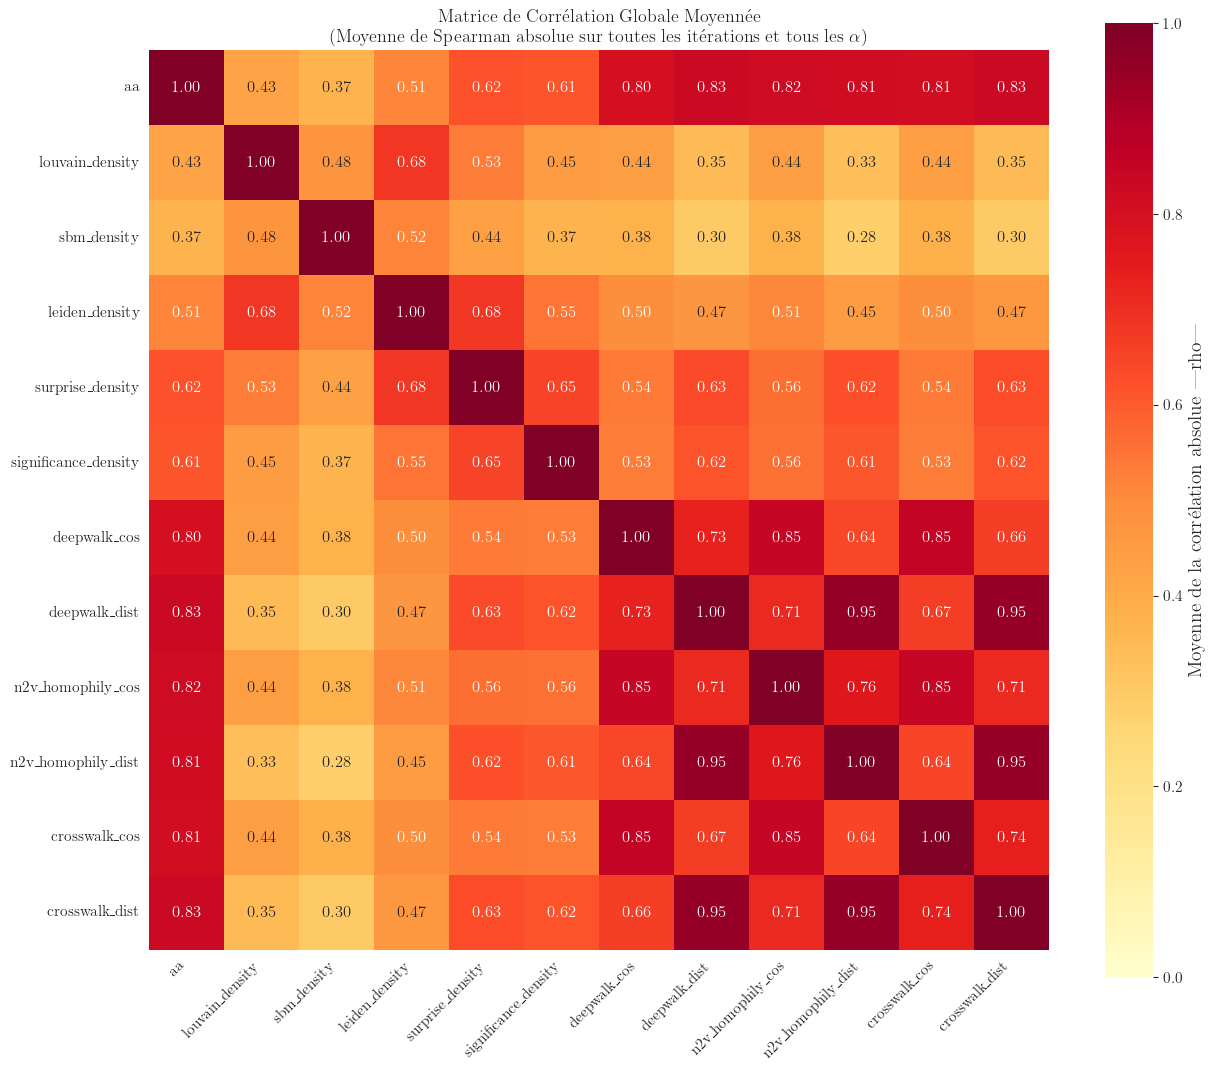

In [132]:
all_matrices = []

# --- 1. Accumulation de toutes les matrices absolues ---
for nbiter in range(1, 11):
    for i in np.arange(1.00, -0.10, -0.10):
        sbm_val, pos_val = f"{i:.2f}", f"{1 - i:.2f}"
        suf = f"{sbm_val.replace('.', '_')}_pos_{pos_val.replace('.', '_')}_{nbiter}"

        try:
            dataset_train = gp.load_dataset(filename=f"dataset_train_artificial_graph_sbmv_4_AllBasicMetrics_{suf}", talk=False)
        except Exception:
            continue

        cols = [c for c in features_commu_inferee + features_embeddings if c in dataset_train.columns]
        
        # Calcul de la matrice absolue pour ce fichier précis
        corr_matrix = abs(dataset_train[cols].corr(method="spearman"))
        
        # On ne garde que si la taille est complète pour éviter les décalages d'index
        if corr_matrix.shape == (len(features_commu_inferee) + len(features_embeddings), len(features_commu_inferee) + len(features_embeddings)):
            all_matrices.append(corr_matrix)

# --- 2. Moyennisation "Bourrin" (Pixel-wise mean) ---
# On transforme la liste de DataFrames en un tenseur 3D numpy pour moyenner sur le premier axe
tensor_matrices = np.array([df.to_numpy() for df in all_matrices])
mean_matrix_np = np.mean(tensor_matrices, axis=0)

# Re-construction du DataFrame avec les bons labels d'origine
mean_corr_df = pd.DataFrame(
    mean_matrix_np, 
    index=features_commu_inferee + features_embeddings, 
    columns=features_commu_inferee + features_embeddings
)

# --- 3. Tracé du Heatmap global ---
plt.figure(figsize=(13, 11))
sns.heatmap(
    mean_corr_df, 
    annot=True, 
    fmt=".2f", 
    cmap="YlOrRd",  # Palette chaude très lisible pour les corrélations
    vmin=0, vmax=1,
    square=True,
    cbar_kws={'label': 'Moyenne de la corrélation absolue'}
)

#plt.title("Matrice de Corrélation Globale Moyennée\n(Moyenne de Spearman absolue sur toutes les itérations et tous les $\\alpha$)", fontsize=13, fontweight="bold")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

plt.savefig("outputs/plots/03_global_aggregated_collinearity_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

## 5.8 - Correlation lineaire (spearman) entre louvain, spatial_louvain et GT_Pos

Iter 1 commencée
Iter 2 commencée
Iter 3 commencée
Iter 4 commencée
Iter 5 commencée
Iter 6 commencée
Iter 7 commencée
Iter 8 commencée
Iter 9 commencée
Iter 10 commencée
Iter 11 commencée
Iter 12 commencée
Iter 13 commencée
Iter 14 commencée
Iter 15 commencée
Iter 16 commencée
Iter 17 commencée
Iter 18 commencée
Iter 19 commencée
Iter 20 commencée
Iter 21 commencée
Iter 22 commencée
Iter 23 commencée
Iter 24 commencée
Iter 25 commencée
Iter 26 commencée
Iter 27 commencée
Iter 28 commencée
Iter 29 commencée
Iter 30 commencée


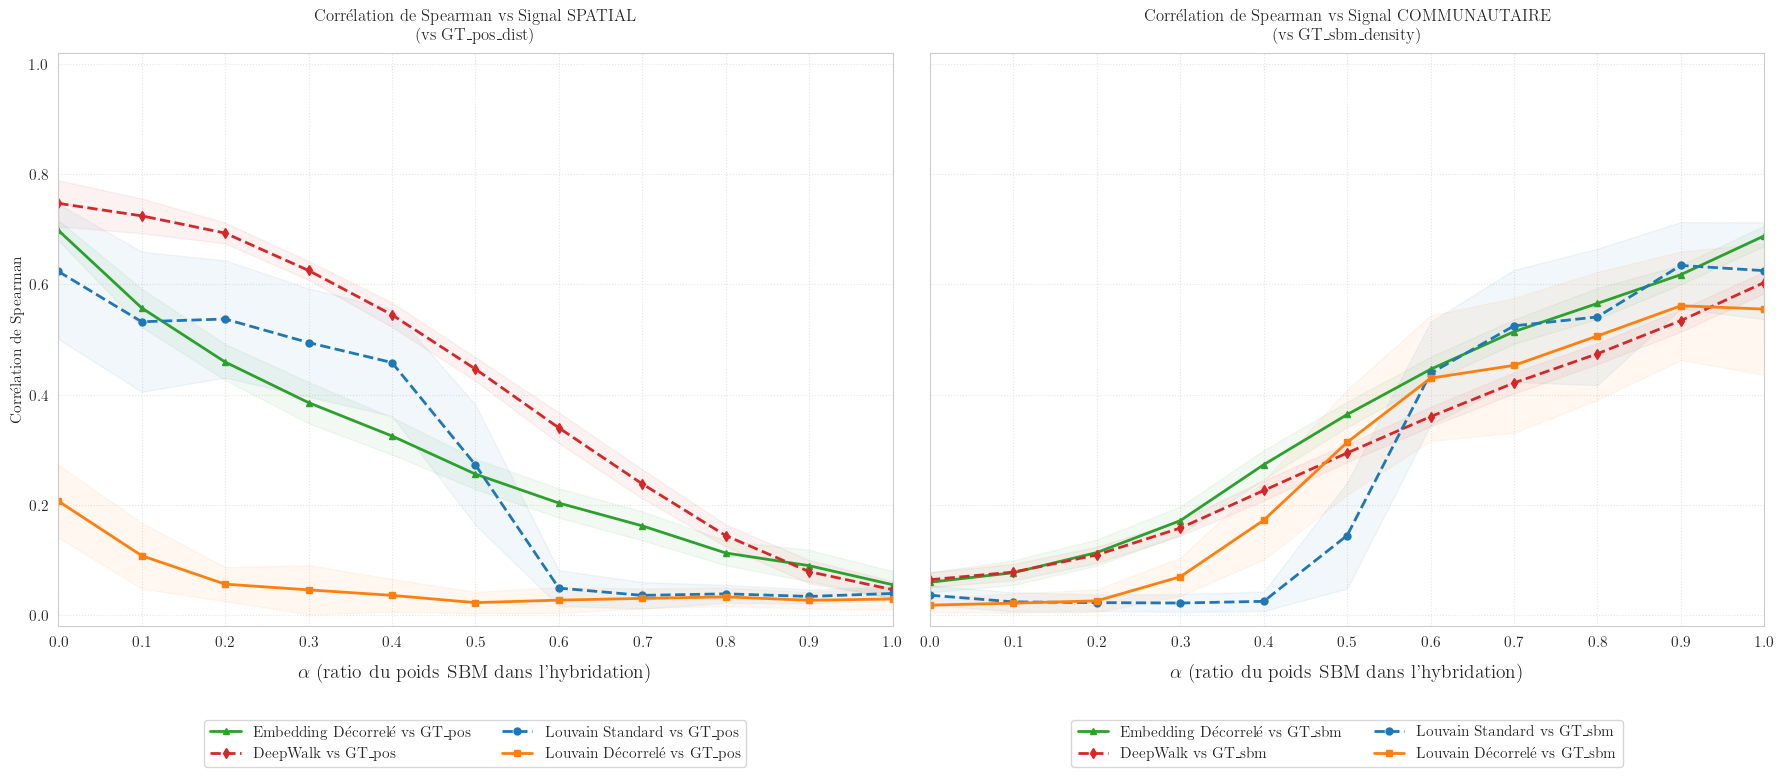

In [188]:
features_commus_unbiaised = ['louvain_density', "spatial_louvain_density"]
#features_commus_unbiaised = ['SiNEcustom_spatial_dist', 'deepwalk_dist', 'louvain_density', "spatial_louvain_density"]
all_features_to_test = features_commus_unbiaised

plt.close("all")
warnings.filterwarnings("ignore")

all_corr_results = []

for nbiter in range(1, 31):
    for i in np.arange(1.00, -0.10, -0.10):
        sbm_val, pos_val = f"{i:.2f}", f"{1 - i:.2f}"
        suf = f"{sbm_val.replace('.', '_')}_pos_{pos_val.replace('.', '_')}_{nbiter}"

        if sbm_val == "1.00":
            print(f"Iter {nbiter} commencée")

        dataset_train = gp.load_dataset(filename=f"dataset_train_artificial_graph_sbmv_4_comuAndEmb_{suf}", talk=False)
        G = load_graphml_safe(f"graph_library/artificial_graph_sbmv_4_{suf}.graphml")
        gt_raw = json.loads(G.graph["GroundTruth_JSON"])

        # Calcul GT SBM à la volée
        n1, n2 = (
            dataset_train["u"].astype(int).values,
            dataset_train["v"].astype(int).values,
        )
        dataset_train["GT_sbm_density"] = np.array(gt_raw["GT_sbm_matrix"])[
            np.array(gt_raw["GT_sbm_id"])[n1], np.array(gt_raw["GT_sbm_id"])[n2]
        ]

        # --- CALCUL DIRECT DE CORRÉLATION (SPEARMAN) ---
        cols_to_corr = all_features_to_test + ["GT_sbm_density", "GT_pos_dist"]
        corr_matrix = dataset_train[cols_to_corr].corr(method="spearman")

        for feat in all_features_to_test:
            if feat not in corr_matrix.columns:
                continue

            # Valeurs absolues pour capter la force de la dépendance
            corr_sbm = abs(corr_matrix.loc[feat, "GT_sbm_density"])
            corr_pos = abs(corr_matrix.loc[feat, "GT_pos_dist"])

            all_corr_results.append(
                {
                    "iter": nbiter,
                    "ratio_sbm": i,
                    "feature": feat,
                    "corr_sbm": corr_sbm,
                    "corr_pos": corr_pos,
                }
            )

# --- 3. AGRÉGATION ---
df_corr = pd.DataFrame(all_corr_results)
stats_corr = (
    df_corr.groupby(["feature", "ratio_sbm"])
    .agg({"corr_sbm": ["mean", "std"], "corr_pos": ["mean", "std"]})
    .reset_index()
)
stats_corr.columns = [
    "_".join(col).strip("_") for col in stats_corr.columns.values
]

i_values = sorted(stats_corr["ratio_sbm"].unique(), reverse=True)

# --- 4. TRACÉ (2 sous-graphiques côte à côte) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8), sharey=True)

# Définition des styles de base par feature
feature_styles = {
    "louvain_density": {"name": "Louvain Standard", "color": "#1f77b4", "marker": "o", "ls": "--"},
    "spatial_louvain_density": {"name": "Louvain Décorrelé", "color": "#ff7f0e", "marker": "s", "ls": "-"},
    "SiNEcustom_spatial_dist": {"name": "Embedding Décorrelé", "color": "#2ca02c", "marker": "^", "ls": "-"},
    "deepwalk_dist": {"name": "DeepWalk", "color": "#d62728", "marker": "d", "ls": "--"}
}

for feat in all_features_to_test:
    df_feat = stats_corr[stats_corr["feature"] == feat].dropna()
    if df_feat.empty:
        continue

    style = feature_styles[feat]
    x = df_feat["ratio_sbm"].astype(float).values

    # Données pour GT_pos (Gauche)
    y_pos = df_feat["corr_pos_mean"].astype(float).values
    err_pos = df_feat["corr_pos_std"].fillna(0).astype(float).values

    # Données pour GT_sbm (Droite)
    y_sbm = df_feat["corr_sbm_mean"].astype(float).values
    err_sbm = df_feat["corr_sbm_std"].fillna(0).astype(float).values

    # ---- GAUCHE : Corrélation avec GT_pos_dist ----
    ax1.plot(
        x,
        y_pos,
        label=f"{style['name']} vs GT_pos",
        color=style["color"],
        linestyle=style["ls"],
        marker=style["marker"],
        markersize=5,
        lw=2,
    )
    ax1.fill_between(
        x,
        np.maximum(0, y_pos - err_pos),
        np.minimum(1, y_pos + err_pos),
        color=style["color"],
        alpha=0.06,
    )

    # ---- DROITE : Corrélation avec GT_sbm_density ----
    ax2.plot(
        x,
        y_sbm,
        label=f"{style['name']} vs GT_sbm",
        color=style["color"],
        linestyle=style["ls"],
        marker=style["marker"],
        markersize=5,
        lw=2,
    )
    ax2.fill_between(
        x,
        np.maximum(0, y_sbm - err_sbm),
        np.minimum(1, y_sbm + err_sbm),
        color=style["color"],
        alpha=0.06,
    )

# --- 5. CONFIGURATION FINALE ---
ax1.set_title(
    "Corrélation de Spearman vs Signal SPATIAL\n(vs GT_pos_dist)",
    fontsize=12,
    fontweight="bold",
    pad=10
)
ax2.set_title(
    "Corrélation de Spearman vs Signal COMMUNAUTAIRE\n(vs GT_sbm_density)",
    fontsize=12,
    fontweight="bold",
    pad=10
)

ax1.set_ylabel("Corrélation de Spearman", fontsize=11)

for ax in [ax1, ax2]:
    ax.set_xlabel(r"$\alpha$ (ratio du poids SBM dans l'hybridation)", labelpad=10)
    ax.set_xticks(i_values)
    ax.set_xticklabels([f"{v:.1f}" for v in i_values])
    ax.set_xlim(min(i_values), max(i_values))  # Inversion de l'axe X si nécessaire
    ax.set_ylim(-0.02, 1.02)
    ax.grid(True, linestyle=":", alpha=0.5)

# Une légende propre sous chaque graphique
ax1.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2, fontsize=11)
ax2.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2, fontsize=11)

plt.tight_layout()
os.makedirs("outputs/plots", exist_ok=True)
plt.savefig("outputs/plots/02_Correl_louvain_VS_spatiallouvain_SBM_and_POS.png", dpi=300, bbox_inches="tight")
#plt.savefig("outputs/plots/02_Correl_All_SBM_and_POS.png", dpi=300, bbox_inches="tight")


plt.show()

## 5.9 - NMI entre features unbiased & GT_pos et sbm

In [8]:
import warnings
from sklearn.metrics import adjusted_mutual_info_score

features_commu_inferee = ["louvain_density", "spatial_louvain_density", "sbm_louvain_density"]
features_embeddings = ['SiNEcustom_spatial_dist', 'SiNEcustom_sbm_dist', 'deepwalk_dist']
all_features_to_test = features_commu_inferee + features_embeddings

plt.close("all")

warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    message="The number of unique classes is greater than 50%",
)

def load_graphml_safe(path, talk=False):
    with open(path, 'r', encoding='utf-8') as f:
        raw_data = f.read()

    clean_data = html.unescape(raw_data)
    G = nx.read_graphml(io.StringIO(clean_data))

    if talk:
        print(f"✅ Graphe chargé : {G.number_of_nodes()} nœuds et {G.number_of_edges()} liens.")
    return G

def load_dataset_otherfolder(filename="dataset", talk=False):
    # Chemin relatif direct vers le dossier cible de ton projet papier
    input_dir = os.path.join("..", "DUPUY-Guilhem-2026-paper", "your_results", "data")
    input_path = os.path.join(input_dir, filename)
        
    if not os.path.exists(input_path):
        print(f"Erreur : Le fichier n'existe pas : {input_path}")
        return None
        
    # Chargement du fichier Parquet
    dataset = pd.read_parquet(input_path)
    
    if talk:
        print(f"Dataset chargé avec succès depuis : {input_path}")
        print(f"Taille : {dataset.shape[0]} lignes, {dataset.shape[1]} colonnes.")
        
    return dataset

def calculate_entropy(labels):
    """Calcule l'entropie H(X) en bits."""
    prob_dist = pd.Series(labels).value_counts(normalize=True)
    return -(prob_dist * np.log2(prob_dist)).sum()

def get_adjusted_mi(feature, target):
    """Calcule l'AMI (Adjusted Mutual Information)."""
    return adjusted_mutual_info_score(feature, target)

all_results = []

# --- 2. BOUCLE PRINCIPALE : DATA PROCESS & CALCULS ---
for nbiter in range(1, 31):
    for i in np.arange(1.00, -0.10, -0.10):
        sbm_val = f"{i:.2f}"
        pos_val = f"{1 - i:.2f}"
        #G_name = f"artificial_graph_sbmv_4_AllFeatures_{sbm_val.replace('.', '_')}_pos_{pos_val.replace('.', '_')}_{nbiter}"
        #G_name_graph = f"artificial_graph_sbmv_4_{sbm_val.replace('.', '_')}_pos_{pos_val.replace('.', '_')}_{nbiter}"

        G_name = f"artificial_graph_simple_somme_AllFeatures_{sbm_val.replace('.', '_')}_pos_{pos_val.replace('.', '_')}_{nbiter}"
        G_name_graph = f"artificial_graph_simple_somme_{sbm_val.replace('.', '_')}_pos_{pos_val.replace('.', '_')}_{nbiter}"

        dataset_train = load_dataset_otherfolder(filename=f"dataset_train_{G_name}", talk=False)
        graphml_dir = os.path.abspath(os.path.join("..", "DUPUY-Guilhem-2026-paper", "graph_library"))
        graphml_path = os.path.join(graphml_dir, f"{G_name_graph}.graphml")

        try:
            if not os.path.exists(graphml_path):
                print(f"Fichier introuvable : {graphml_path}")
                continue
                
            G = load_graphml_safe(graphml_path)
            
            if "GroundTruth_JSON" in G.graph:
                gt_raw = json.loads(G.graph["GroundTruth_JSON"])
                GT = {
                    "GT_sbm_matrix": np.array(gt_raw["GT_sbm_matrix"]),
                    "GT_sbm_id": np.array(gt_raw["GT_sbm_id"]),
                }
            else:
                continue
        except Exception as e:
            print(f"Erreur lors de la lecture de {G_name_graph}.graphml : {e}")
            continue


        if round(i, 2) == 0.50:
            print(f"Calcul en cours pour l'itération {nbiter}, i = 0.50")

        n1 = dataset_train["u"].astype(int).values
        n2 = dataset_train["v"].astype(int).values
        block_n1 = GT["GT_sbm_id"][n1]
        block_n2 = GT["GT_sbm_id"][n2]
        dataset_train["GT_sbm_density"] = GT["GT_sbm_matrix"][block_n1, block_n2]

        dt_processed = dataset_train.copy()

        # Variable continue cible géographique ajoutée pour être sûr qu'elle soit dans la liste
        features_continues = features_embeddings + ["GT_pos_dist"]
        for col in features_continues:
            if col in dt_processed.columns:
                try:
                    dt_processed[col] = pd.qcut(dt_processed[col], 13, labels=False, duplicates="drop")
                except Exception:
                    pass

        features_discretes = features_commu_inferee + ["GT_sbm_density"]
        for col in features_discretes:
            if col in dt_processed.columns:
                dt_processed[col] = dt_processed[col].round(5).astype(str)

        gt_sbm_vector = dt_processed["GT_sbm_density"].astype(str)
        gt_pos_vector = dt_processed["GT_pos_dist"].astype(str)

        for feat in all_features_to_test:
            if feat not in dt_processed.columns:
                continue

            feat_vector = dt_processed[feat].astype(str)
            entropie_feature = calculate_entropy(feat_vector)

            all_results.append(
                {
                    "iter": nbiter,
                    "ratio_sbm": i,
                    "feature": feat,
                    "mi_ratio_sbm": get_adjusted_mi(feat_vector, gt_sbm_vector),
                    "mi_ratio_pos": get_adjusted_mi(feat_vector, gt_pos_vector),
                    "entropie_feature": entropie_feature
                }
            )

df_res = pd.DataFrame(all_results)

stats = df_res.groupby(['feature', 'ratio_sbm']).agg({
    'mi_ratio_pos': ['mean', 'std'],
    'mi_ratio_sbm': ['mean', 'std'],
    'entropie_feature': ['mean', 'std']
}).reset_index()

# Aplatissement explicite et sécurisé
stats.columns = [
    'feature', 'ratio_sbm', 
    'mi_ratio_pos_mean', 'mi_ratio_pos_std', 
    'mi_ratio_sbm_mean', 'mi_ratio_sbm_std', 
    'entropie_mean', 'entropie_std'
]

Calcul en cours pour l'itération 1, i = 0.50
Calcul en cours pour l'itération 2, i = 0.50
Calcul en cours pour l'itération 3, i = 0.50
Calcul en cours pour l'itération 4, i = 0.50
Calcul en cours pour l'itération 5, i = 0.50
Calcul en cours pour l'itération 6, i = 0.50
Calcul en cours pour l'itération 7, i = 0.50
Calcul en cours pour l'itération 8, i = 0.50
Calcul en cours pour l'itération 9, i = 0.50
Calcul en cours pour l'itération 10, i = 0.50
Calcul en cours pour l'itération 11, i = 0.50
Calcul en cours pour l'itération 12, i = 0.50
Calcul en cours pour l'itération 13, i = 0.50
Calcul en cours pour l'itération 14, i = 0.50
Calcul en cours pour l'itération 15, i = 0.50
Calcul en cours pour l'itération 16, i = 0.50
Calcul en cours pour l'itération 17, i = 0.50
Calcul en cours pour l'itération 18, i = 0.50
Calcul en cours pour l'itération 19, i = 0.50
Calcul en cours pour l'itération 20, i = 0.50
Calcul en cours pour l'itération 21, i = 0.50
Calcul en cours pour l'itération 22, i = 0.

Graphique PNG sauvegardé dans : outputs/plots/02_AMI_All_Grid2x2_Simplesomme_READY_FOR_PAPER.png
Graphique PDF (vectoriel pour LaTeX) sauvegardé dans : outputs/plots/02_AMI_All_Grid2x2_Simplesomme_READY_FOR_PAPER.pdf


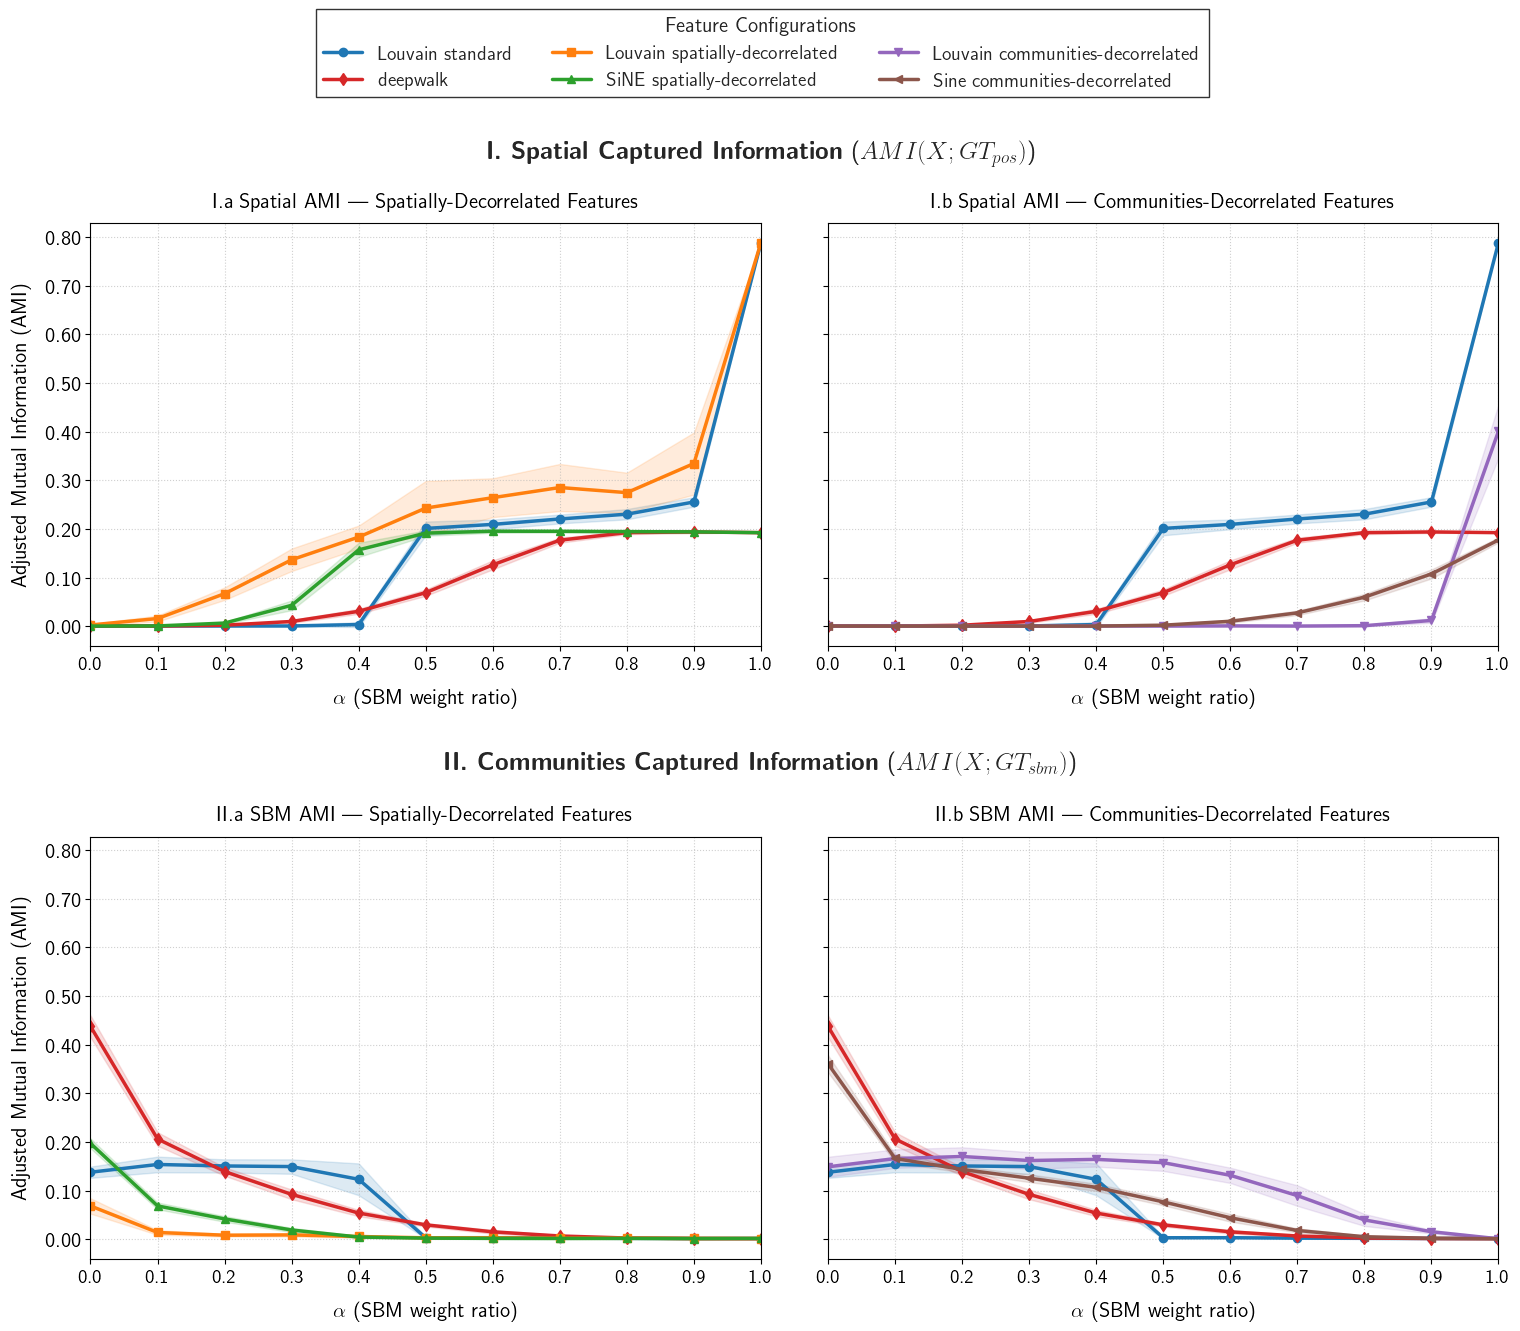

In [9]:
df_res = pd.DataFrame(all_results)

stats = df_res.groupby(['feature', 'ratio_sbm']).agg({
    'mi_ratio_pos': ['mean', 'std'],
    'mi_ratio_sbm': ['mean', 'std'],
    'entropie_feature': ['mean', 'std']
}).reset_index()

# Aplatissement explicite et sécurisé
stats.columns = [
    'feature', 'ratio_sbm', 
    'mi_ratio_pos_mean', 'mi_ratio_pos_std', 
    'mi_ratio_sbm_mean', 'mi_ratio_sbm_std', 
    'entropie_mean', 'entropie_std'
]

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FormatStrFormatter

# --- 3. FEATURE SELECTION (2X2 GRID) ---
all_features_selected = [
    'louvain_density', 'spatial_louvain_density', 'sbm_louvain_density',
    'deepwalk_dist', 'SiNEcustom_spatial_dist', 'SiNEcustom_sbm_dist'
]
stats_copy = stats[stats['feature'].isin(all_features_selected)]

features = stats_copy['feature'].unique()
i_values = sorted(stats_copy['ratio_sbm'].unique(), reverse=True)

# --- GLOBAL LATEX PARAMETERS HARMONIZATION ---
FONT_SIZE_MAIN = 15

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": FONT_SIZE_MAIN,
    "axes.labelsize": FONT_SIZE_MAIN,
    "axes.titlesize": FONT_SIZE_MAIN,
    "xtick.labelsize": FONT_SIZE_MAIN - 1,
    "ytick.labelsize": FONT_SIZE_MAIN,
    "legend.fontsize": FONT_SIZE_MAIN - 1,
    "legend.title_fontsize": FONT_SIZE_MAIN
})

# Rétablissement strict de tes couleurs et marqueurs d'origine
custom_config = {
    "louvain_density": {"label": "Louvain standard", "color": "#1f77b4", "marker": "o"},
    "spatial_louvain_density": {"label": "Louvain spatially-decorrelated", "color": "#ff7f0e", "marker": "s"},
    "SiNEcustom_spatial_dist": {"label": "SiNE spatially-decorrelated", "color": "#2ca02c", "marker": "^"},
    "deepwalk_dist": {"label": "deepwalk", "color": "#d62728", "marker": "d"},
    "sbm_louvain_density": {"label": "Louvain communities-decorrelated", "color": "#9467bd", "marker": "v"},
    "SiNEcustom_sbm_dist": {"label": "Sine communities-decorrelated", "color": "#8c564b", "marker": "<"}
}

# FORÇAGE DE L'ESPACE : Utilisation de gridspec_kw pour verrouiller l'écart vertical (hspace) dès le départ
fig, ((ax1_top, ax2_top), (ax1_bot, ax2_bot)) = plt.subplots(
    2, 2, 
    figsize=(16, 14), 
    sharey=True,
    gridspec_kw={'hspace': 0.45, 'wspace': 0.10} # Verrouille les proportions géométriques
)
sns.set_style("whitegrid")

def draw_curves(ax, target_features, column_mean, column_std):
    ax.grid(True, linestyle=':', alpha=0.6)
    for feat in target_features:
        subset = stats_copy[stats_copy['feature'] == feat]
        if subset.empty or feat not in custom_config:
            continue
            
        config = custom_config[feat] 
        
        ax.plot(
            subset['ratio_sbm'], subset[column_mean], 
            label=config['label'], marker=config['marker'], color=config['color'], linewidth=2.5
        )
        ax.fill_between(
            subset['ratio_sbm'], 
            subset[column_mean] - subset[column_std], 
            subset[column_mean] + subset[column_std], 
            color=config['color'], alpha=0.15
        )
    
    ax.set_xlabel(r"$\alpha$ (SBM weight ratio)", labelpad=10)
    ax.set_xticks(i_values)
    ax.set_xticklabels([f"{v:.1f}" for v in i_values]) 
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    ax.set_xlim(min(i_values), max(i_values))

# --- CONFIGURATION DES LISTES DE FEATURES ---
features_spatial = ["louvain_density", "deepwalk_dist", "spatial_louvain_density", "SiNEcustom_spatial_dist"]
features_sbm = ["louvain_density", "deepwalk_dist", "sbm_louvain_density", "SiNEcustom_sbm_dist"]

# --- ETAPE D'INVERSION GAUCHE / DROITE APPLIQUÉE ---
draw_curves(ax1_top, features_spatial, 'mi_ratio_sbm_mean', 'mi_ratio_sbm_std')
draw_curves(ax2_top, features_sbm, 'mi_ratio_sbm_mean', 'mi_ratio_sbm_std')
draw_curves(ax1_bot, features_spatial, 'mi_ratio_pos_mean', 'mi_ratio_pos_std')
draw_curves(ax2_bot, features_sbm, 'mi_ratio_pos_mean', 'mi_ratio_pos_std')

# --- TITRES ET HARMONISATION EN ANGLAIS ---
ax1_top.set_title("I.a Spatial AMI — Spatially-Decorrelated Features", pad=12)
ax2_top.set_title("I.b Spatial AMI — Communities-Decorrelated Features", pad=12)
ax1_bot.set_title("II.a SBM AMI — Spatially-Decorrelated Features", pad=12)
ax2_bot.set_title("II.b SBM AMI — Communities-Decorrelated Features", pad=12)

ax1_top.set_ylabel("Adjusted Mutual Information (AMI)", labelpad=10)
ax1_bot.set_ylabel("Adjusted Mutual Information (AMI)", labelpad=10)

# CONTRÔLE FIN DE LA FENÊTRE (Remplace tight_layout)
# top=0.84 laisse de la place pour la légende, bottom=0.06 évite de couper le bas
plt.subplots_adjust(top=0.80, bottom=0.06, left=0.08, right=0.96)

# --- GRANDS BANDEAUX HORIZONTAUX DE SECTIONS SÉCURISÉS ---
# Les coordonnées Y sont maintenant stables car tight_layout n'écrase plus le repère
fig.text(0.5, 0.85, r"\textbf{I. Spatial Captured Information} ($AMI(X; GT_{pos})$)", 
         ha='center', va='center', fontsize=18, fontweight='bold')
fig.text(0.5, 0.415, r"\textbf{II. Communities Captured Information} ($AMI(X; GT_{sbm})$)", 
         ha='center', va='center', fontsize=18, fontweight='bold')

# --- COLLECTE GLOBALE DES HANDLES POUR LA LÉGENDE UNIQUE ---
handles_all, labels_all = [], []
for ax in [ax1_top, ax1_bot, ax2_top, ax2_bot]:
    h, l = ax.get_legend_handles_labels()
    for handle, label in zip(h, l):
        if label not in labels_all:
            handles_all.append(handle)
            labels_all.append(label)

# Boîte de légende fermée tout en haut
fig.legend(
    handles_all, labels_all,
    loc='upper center', bbox_to_anchor=(0.5, 0.96), ncol=3, 
    title="Feature Configurations", frameon=True, facecolor='white', edgecolor='black', fancybox=False
)

# --- ENREGISTREMENT OPTIMISÉ POUR LATEX (PNG + PDF VECTORIEL) ---
output_path = "outputs/plots"
os.makedirs(output_path, exist_ok=True)

# Définition des chemins pour les deux formats
save_name_png = os.path.join(output_path, "02_AMI_All_Grid2x2_Simplesomme_READY_FOR_PAPER.png")
save_name_pdf = os.path.join(output_path, "02_AMI_All_Grid2x2_Simplesomme_READY_FOR_PAPER.pdf")

# 1. Sauvegarde PNG (Aperçu)
plt.savefig(save_name_png, dpi=300, bbox_inches='tight')

# 2. Sauvegarde PDF (Vectoriel optimisé pour le papier LaTeX)
# backend='pdf' force l'encapsulation vectorielle propre
plt.savefig(save_name_pdf, bbox_inches='tight', backend='pdf')

print(f"Graphique PNG sauvegardé dans : {save_name_png}")
print(f"Graphique PDF (vectoriel pour LaTeX) sauvegardé dans : {save_name_pdf}")

plt.show()

## 5.10 - Link pred perfs (somme pondérée VS l'autres)

In [4]:
def plot_f1_comparison_side_by_side(df_sbmv4, df_sbmv6, metric="AUC-ROC_eval", name="03_perf_compar"):
    # --- CONFIGURATION LATEX (Tailles augmentées pour article SVProc) ---
    plt.rcParams.update({
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman"],
        "font.size": 16,             
        "axes.labelsize": 18,        
        "axes.titlesize": 18,        
        "xtick.labelsize": 15,       
        "ytick.labelsize": 15,       
        "figure.titlesize": 20,
        "legend.fontsize": 14,       
        "legend.title_fontsize": 16  
    })
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7.5), sharey=True)
    sns.set_style("whitegrid")
    
    # --- 1. MAPPING STRICT ---
    labels_mapping = {
        "GT_pos": "GT Pos",
        "GT_pos + louvain": "GT Pos + standard Louvain",
        "GT_pos + spatial louvain": "GT pos + decorrelated Louvain",
        "GT_pos + Deepwalk": "GT Pos + DeepWalk",
        "GT_pos + Deepwalk on residuals": "GT Pos + Deepwalk on residuals",
        "GT_pos + SiNEcustom_spatial": "GT Pos + decorrelated SiNE"
    }
    
    # --- 2. CONFIGURATION DES COULEURS HARMONIEUSES (LIGNES CONTINUES UNIQUES) ---
    color_mapping = {
        "GT Pos": "#e24a33",                           # Rouge brique pour la baseline
        "GT Pos + standard Louvain": "#6caed6",        # Bleu ciel (ton image)
        "GT Pos + DeepWalk": "#6caed6",                # Bleu ciel (ton image)
        "GT pos + decorrelated Louvain": "#55a868",    # Vert lumineux (ton image)
        "GT Pos + decorrelated SiNE": "#55a868",        # Vert lumineux (ton image)
        "GT Pos + Deepwalk on residuals": "#2b7bba"    # Bleu acier / lumineux intermédiaire
    }

    mean_col = f"{metric}_mean"
    ci_col = f"{metric}_ci95"
    
    def plot_subplot(ax, df, title_subplot):
        ax.grid(True, linestyle="--", alpha=0.6)
        experiments = df['Experiment'].unique()
        
        for exp in experiments:
            subset = df[df["Experiment"] == exp]
            clean_label = labels_mapping.get(exp, exp)
            color = color_mapping.get(clean_label, "#7f7f7f")
            
            latex_label = clean_label.replace('_', '\_')
            
            # Uniquement des lignes continues et des marqueurs ronds comme demandé
            ax.plot(subset["Ratio_SBM"], subset[mean_col], 
                    marker='o', linestyle='-',
                    label=latex_label, color=color, linewidth=2.5, markersize=7)
            
            # Intervalle de confiance
            ax.fill_between(
                subset["Ratio_SBM"], 
                subset[mean_col] - subset[ci_col], 
                subset[mean_col] + subset[ci_col], 
                color=color, 
                alpha=0.15 
            )
        
        ax.set_title(title_subplot, pad=15)
        ax.set_xlabel(r"$\alpha$ (SBM weight ratio)", labelpad=10)
        ax.set_xlim(-0.05, 1.05)
        ax.set_ylim(0.48, 1.02)

    # --- 3. DESSIN DES DEUX SUBPLOTS ---
    plot_subplot(ax1, df_sbmv4, "Weighted Sum Hybridization")
    plot_subplot(ax2, df_sbmv6, "Exponent Hybridization")
    
    ax1.set_ylabel("AUC-ROC evaluation set", labelpad=10)
    
    # --- 4. GESTION DE LA LÉGENDE UNIQUE ET GLOBALE FUSIONNÉE ---
    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    
    # Fusion propre des labels pour éviter les doublons (ex: GT Pos)
    by_label = dict(zip(l1 + l2, h1 + h2))
    
    plt.subplots_adjust(wspace=0.15) 
    
    fig.legend(
        by_label.values(), 
        by_label.keys(), 
        loc='upper center', 
        bbox_to_anchor=(0.5, 0.99), 
        ncol=3, 
        title="Feature Configurations", 
        frameon=True,             
        facecolor='white',        
        edgecolor='black',        
        framealpha=1.0,           
        fancybox=False            
    )
    
    plt.tight_layout(rect=[0, 0, 1, 0.85])
    
    # Sauvegarde
    output_dir = os.path.join("outputs", "plots")
    os.makedirs(output_dir, exist_ok=True)
    
    save_path = os.path.join(output_dir, f"{name}_{metric}_top_legend.png")
    plt.savefig(save_path, bbox_inches='tight', dpi=300)
    
    print(f"Graphique sauvegardé avec succès ici : {save_path}")
    plt.show()

def confidence_interval_95(data):
    n = len(data)
    if n < 2: return 0
    sem = stats.sem(data)
    h = sem * stats.t.ppf((1 + 0.95) / 2., n - 1)
    return h

def process_pipeline(file_path, feat_list, metrics):
    df = pd.read_csv(file_path)
    df = df[df["Experiment"].isin(feat_list)]
    df = df.sort_values(by="Experiment", ascending=True)
    
    df_avg = df.groupby(["Ratio_SBM", "Experiment"])[metrics].agg([
        ('mean', np.mean),
        ('ci95', confidence_interval_95)
    ]).reset_index()
    
    df_avg.columns = [f"{col[0]}_{col[1]}" if col[1] else col[0] for col in df_avg.columns.values]
    return df_avg

Processing sbmv_4...
Processing sbmv_6...


/tmp/ipykernel_220/1320739019.py:126: FutureWarning: The provided callable <function mean at 0x7fefcd595ea0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df_avg = df.groupby(["Ratio_SBM", "Experiment"])[metrics].agg([
/tmp/ipykernel_220/1320739019.py:126: FutureWarning: The provided callable <function mean at 0x7fefcd595ea0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df_avg = df.groupby(["Ratio_SBM", "Experiment"])[metrics].agg([
/tmp/ipykernel_220/1320739019.py:126: FutureWarning: The provided callable <function mean at 0x7fefcd595ea0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df_avg = df.groupby(["R

Graphique sauvegardé avec succès ici : outputs/plots/03_perf_compar_Comu_AUC-ROC_eval_top_legend.png


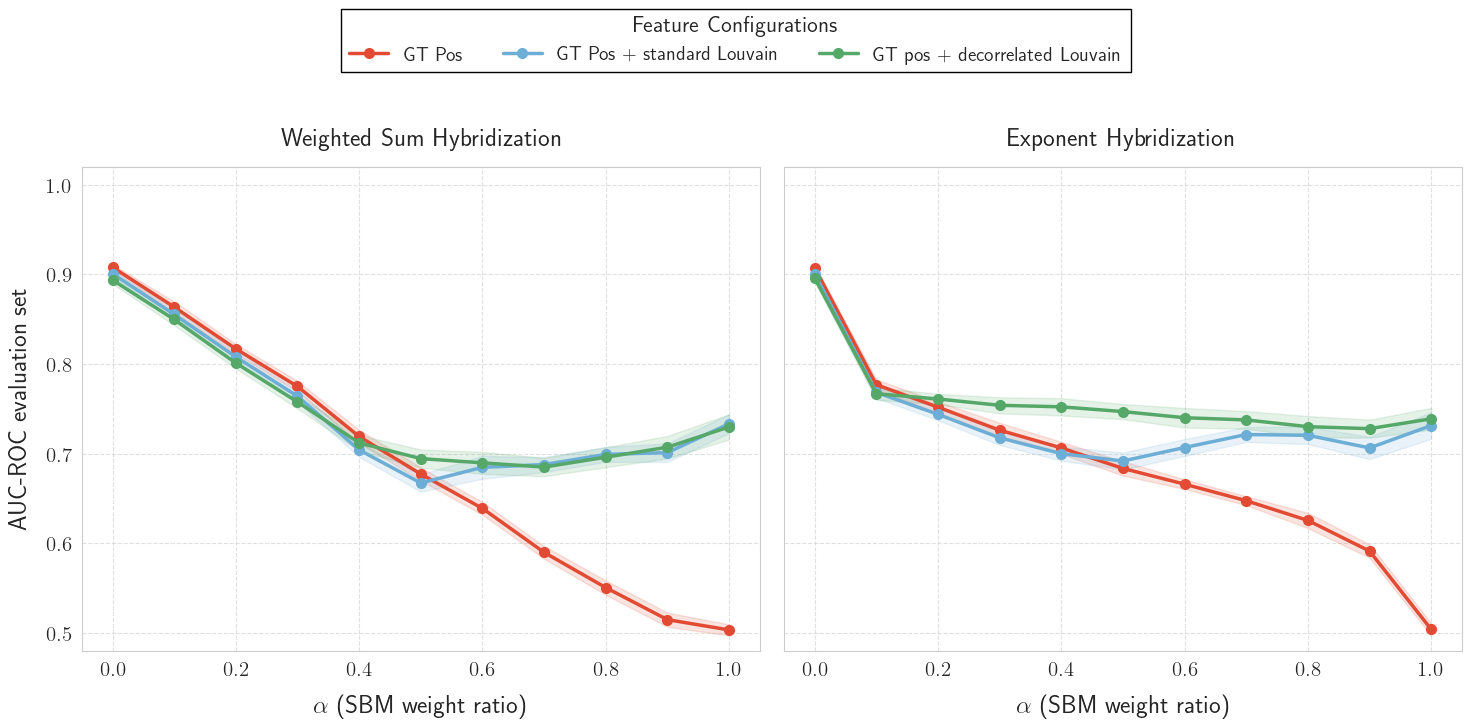

In [6]:
feat_to_plot = [
        "GT_pos", 
        "GT_pos + louvain",
        "GT_pos + spatial louvain",
        #"GT_pos + Deepwalk",
        #"GT_pos + Deepwalk on residuals",
        #"GT_pos + SiNEcustom_spatial",     
]
metrics_list = ["AP_train", "AUC-ROC_train", "AP_eval", "AUC-ROC_eval"]

# Remplacer par tes vrais chemins de fichiers sbmv_4 et sbmv_6
path_sbmv4 = "outputs/results/link_prediction_perfs_artificial_graph_sbmv_4_AllFeatures_30iter_03-07-2026_17-54.csv"
path_sbmv6 = "outputs/results/link_prediction_perfs_artificial_graph_sbmv_6_AllFeatures_30iter_06-07-2026_21-31.csv"

print("Processing sbmv_4...")
df_avg_v4 = process_pipeline(path_sbmv4, feat_to_plot, metrics_list)

print("Processing sbmv_6...")
# Note : s'assurer que le fichier sbmv_6 existe à cet emplacement
df_avg_v6 = process_pipeline(path_sbmv6, feat_to_plot, metrics_list) 

# Génération du graphique final côte à côte
plot_f1_comparison_side_by_side(df_avg_v4, df_avg_v6, metric="AUC-ROC_eval", name="03_perf_compar_Comu")